In [1]:
import os
import pandas as pd
from scipy.stats import pearsonr, spearmanr
from scipy.stats import poisson
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Lasso
from numpy import arange
from numpy import absolute
from numpy import mean
from numpy import std
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import mean_absolute_error
import statsmodels.api as sm
lowess = sm.nonparametric.lowess
from matplotlib.lines import Line2D
# Step 1: Import necessary libraries
from sklearn.decomposition import PCA
import umap
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
#from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from scipy.stats import ttest_ind, mannwhitneyu

In [2]:
import sklearn
print(sklearn.__version__)

1.6.0


In [3]:
df_norm = pd.read_csv("/home/lajoyce/Documents/african_killifish_atlas/final_analysis/AtlasFiles_forLajoyce_240507/CountsNormDESeq2_AllTissue_240506.csv")

In [4]:
df_norm = df_norm.T

In [5]:
df_metadata = pd.read_csv("/home/lajoyce/Documents/african_killifish_atlas/final_analysis/AtlasFiles_forLajoyce_240507/ExperimentDesign_allbatches_combined_v7.csv")

df_metadata.head(3)

,Unnamed: 0,animalID,sex,cohort,age_days,harvest_date,hatch_date,tissue,tissue_grind_date,RNA_extract_date,RNA_batch,RNA_extractor,RNAID,cDNA_batch,plate_well,sampleNames,lib,censored,censor_code,notes
0,A1_1,J9,F,2,155,8/16/22,3/14/22,Gut,NaN,3/8/23,Gut_1,EC,RNA352,1,A1,A1,A1_1,NaN,NaN,NaN
1,A1_2,A01,M,2,78,5/31/22,3/14/22,Bone,4/19/23,4/22/23,Bone_1,EC,RNA572,2,A1,A1,A1_2,NaN,NaN,NaN
2,A10_1,P_1B_10,M,1B,133,1/31/22,9/20/21,Kidney,NaN,3/4/23,Kidney_1,JC,R258,1,A10,A10,A10_1,NaN,NaN,NaN


In [6]:
df_metadata.rename(columns={"Unnamed: 0": "sample"}, inplace=True)

df_metadata.head(3)

,sample,animalID,sex,cohort,age_days,harvest_date,hatch_date,tissue,tissue_grind_date,RNA_extract_date,RNA_batch,RNA_extractor,RNAID,cDNA_batch,plate_well,sampleNames,lib,censored,censor_code,notes
0,A1_1,J9,F,2,155,8/16/22,3/14/22,Gut,NaN,3/8/23,Gut_1,EC,RNA352,1,A1,A1,A1_1,NaN,NaN,NaN
1,A1_2,A01,M,2,78,5/31/22,3/14/22,Bone,4/19/23,4/22/23,Bone_1,EC,RNA572,2,A1,A1,A1_2,NaN,NaN,NaN
2,A10_1,P_1B_10,M,1B,133,1/31/22,9/20/21,Kidney,NaN,3/4/23,Kidney_1,JC,R258,1,A10,A10,A10_1,NaN,NaN,NaN


In [7]:
df_metadata.set_index("sample", inplace=True)

In [8]:
# Merge based on index
combined_df = pd.concat([df_norm, df_metadata[['sex', 'tissue', 'age_days']]], axis=1)

combined_df.head(10)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A1_1,23876.707871,687.004459,2181.018965,576.907591,221.294706,884.077854,1368.504075,1348.686639,619.845370,636.359900,...,243.314079,1718.612117,47.341653,568.099841,3323.824460,1566.678439,358.915791,F,Gut,155
A1_2,36.845369,407.384647,349.683408,374.015256,493.588906,469.257059,963.541161,1619.805848,453.962755,449.791581,...,107.060129,777.923924,19.465478,672.254187,2691.797529,191.873997,253.746410,M,Bone,78
A10_1,4821.965545,907.596706,218.510659,554.051370,191.503723,684.175695,1125.288972,662.897504,586.787050,637.527352,...,112.938093,1122.015404,311.807344,542.593883,2612.307200,408.377598,391.191366,M,Kidney,133
A10_2,4.382338,451.380822,1198.256441,303.633424,289.860362,445.120339,1093.080327,468.284126,709.312721,492.073962,...,174.667475,1304.058604,28.172173,1264.617561,1144.416288,157.764171,238.524401,M,SpinalCord,75
A11_1,7011.583272,766.674115,222.103168,627.278822,272.285474,675.602523,1267.567871,975.767056,739.724358,713.703904,...,109.657631,1059.404232,398.670540,521.338398,1948.746206,360.569160,446.064940,M,Kidney,47
A11_2,8.609836,486.229181,1020.945335,358.441083,187.603803,594.985009,1253.410917,559.639365,897.235581,560.545663,...,111.474724,1103.871654,52.565317,1282.865621,983.787094,216.605357,251.951001,F,SpinalCord,52
A12_1,7322.278018,732.665214,225.267215,592.693352,260.260180,651.743981,1162.787081,875.553156,586.132171,640.808680,...,111.540077,1065.827406,275.569603,626.957297,1945.025662,390.025761,450.534430,M,Kidney,161
A12_2,6.381242,390.531984,1030.570512,342.672672,241.849055,465.830634,1290.287044,752.986504,714.699055,485.612483,...,134.644197,1193.930296,27.439339,1560.851686,1036.951754,135.282321,209.304723,M,SpinalCord,161
A13_1,2.350903,453.724234,134.001458,712.323538,481.935067,1024.993606,886.290343,2868.101375,759.341594,702.919927,...,96.387013,883.939440,14.105417,1288.294716,1539.841312,298.564651,347.933609,M,Muscle,134
A13_2,26.477799,505.640544,194.739939,536.388955,640.591905,766.147919,1105.234567,997.615127,667.923826,527.847730,...,213.530635,1276.059075,9.395348,825.082374,3853.800902,227.196596,538.951323,M,Heart,162


# Gut

In [9]:
gut_df = combined_df.loc[combined_df.iloc[:,-2] == "Gut"]

gut_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A1_1,23876.707871,687.004459,2181.018965,576.907591,221.294706,884.077854,1368.504075,1348.686639,619.845370,636.359900,...,243.314079,1718.612117,47.341653,568.099841,3323.824460,1566.678439,358.915791,F,Gut,155
A2_1,23741.305346,614.790132,4013.251397,576.451327,286.171799,729.806549,1381.566243,1759.477327,503.881445,453.219451,...,214.971160,1263.811341,50.661993,412.142160,4515.763598,2272.943473,276.587097,M,Gut,133
A3_1,25474.794219,394.841817,2380.296399,618.502214,223.660397,730.957162,1441.922333,1626.848248,689.723681,502.298768,...,252.398883,1593.111763,31.237486,541.033250,3708.514285,2226.607970,314.873854,F,Gut,134
A4_1,21094.343422,503.698033,2804.802732,581.903780,319.450595,775.429867,1249.966435,1181.039336,534.185019,514.302202,...,172.317748,1569.417030,86.158874,393.679779,3952.704039,1851.753033,279.684961,F,Gut,75
B1_1,26292.108219,472.266501,1996.967953,731.856697,308.067883,889.800129,1341.737278,1681.081088,476.957890,440.990574,...,148.560654,1469.968579,10.946575,688.070399,3907.927106,1620.093030,320.578254,M,Gut,134


In [10]:
gut_df_male = gut_df.loc[gut_df.iloc[:,-3] == "M"]

gut_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A2_1,23741.305346,614.790132,4013.251397,576.451327,286.171799,729.806549,1381.566243,1759.477327,503.881445,453.219451,...,214.971160,1263.811341,50.661993,412.142160,4515.763598,2272.943473,276.587097,M,Gut,133
B1_1,26292.108219,472.266501,1996.967953,731.856697,308.067883,889.800129,1341.737278,1681.081088,476.957890,440.990574,...,148.560654,1469.968579,10.946575,688.070399,3907.927106,1620.093030,320.578254,M,Gut,134
B2_1,22277.241433,401.416172,988.622938,595.343580,231.899208,809.613023,1475.475661,1647.704897,394.635494,561.440187,...,233.255343,1122.880374,21.698171,565.508594,3923.300631,1360.204125,259.021922,M,Gut,103
B4_1,21628.605092,513.719306,1576.939361,545.667024,249.192200,802.526676,1247.238911,1469.595028,609.562460,591.671738,...,154.626955,1594.830083,44.726805,522.664667,4895.668308,1828.687379,385.928434,M,Gut,47
C2_1,14676.825139,518.280406,1492.063592,346.006919,105.116026,617.556653,1084.738991,1257.012478,586.897812,543.099468,...,134.314922,1721.274927,21.899172,452.582890,3622.123065,1556.301164,243.810783,M,Gut,133


In [11]:
gut_sub_df_male = gut_df_male.iloc[:,:-3]
gut_sub_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A2_1,23741.305346,614.790132,4013.251397,576.451327,286.171799,729.806549,1381.566243,1759.477327,503.881445,453.219451,...,1070.748070,116.385660,839.345993,214.971160,1263.811341,50.661993,412.142160,4515.763598,2272.943473,276.587097
B1_1,26292.108219,472.266501,1996.967953,731.856697,308.067883,889.800129,1341.737278,1681.081088,476.957890,440.990574,...,816.301700,129.795098,1013.340042,148.560654,1469.968579,10.946575,688.070399,3907.927106,1620.093030,320.578254
B2_1,22277.241433,401.416172,988.622938,595.343580,231.899208,809.613023,1475.475661,1647.704897,394.635494,561.440187,...,797.407802,153.243336,972.349310,233.255343,1122.880374,21.698171,565.508594,3923.300631,1360.204125,259.021922
B4_1,21628.605092,513.719306,1576.939361,545.667024,249.192200,802.526676,1247.238911,1469.595028,609.562460,591.671738,...,764.189415,116.289694,1166.730662,154.626955,1594.830083,44.726805,522.664667,4895.668308,1828.687379,385.928434
C2_1,14676.825139,518.280406,1492.063592,346.006919,105.116026,617.556653,1084.738991,1257.012478,586.897812,543.099468,...,819.029036,68.617406,858.447546,134.314922,1721.274927,21.899172,452.582890,3622.123065,1556.301164,243.810783


In [12]:
gut_sub_df_male["age"] = gut_df_male["age_days"].tolist()

gut_sub_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A2_1,23741.305346,614.790132,4013.251397,576.451327,286.171799,729.806549,1381.566243,1759.477327,503.881445,453.219451,...,116.385660,839.345993,214.971160,1263.811341,50.661993,412.142160,4515.763598,2272.943473,276.587097,133
B1_1,26292.108219,472.266501,1996.967953,731.856697,308.067883,889.800129,1341.737278,1681.081088,476.957890,440.990574,...,129.795098,1013.340042,148.560654,1469.968579,10.946575,688.070399,3907.927106,1620.093030,320.578254,134
B2_1,22277.241433,401.416172,988.622938,595.343580,231.899208,809.613023,1475.475661,1647.704897,394.635494,561.440187,...,153.243336,972.349310,233.255343,1122.880374,21.698171,565.508594,3923.300631,1360.204125,259.021922,103
B4_1,21628.605092,513.719306,1576.939361,545.667024,249.192200,802.526676,1247.238911,1469.595028,609.562460,591.671738,...,116.289694,1166.730662,154.626955,1594.830083,44.726805,522.664667,4895.668308,1828.687379,385.928434,47
C2_1,14676.825139,518.280406,1492.063592,346.006919,105.116026,617.556653,1084.738991,1257.012478,586.897812,543.099468,...,68.617406,858.447546,134.314922,1721.274927,21.899172,452.582890,3622.123065,1556.301164,243.810783,133


In [13]:
gut_data_male = gut_sub_df_male.values

In [14]:
X, y = gut_data_male[:,:-1], gut_data_male[:,-1]

Components:  1 | MAE: 40.76 | R²: -0.139 | Pearson: -0.217
Components:  2 | MAE: 41.91 | R²: -0.202 | Pearson: -0.300
Components:  3 | MAE: 43.67 | R²: -0.306 | Pearson: -0.408
Components:  4 | MAE: 34.64 | R²: -0.061 | Pearson: 0.268
Components:  5 | MAE: 33.76 | R²: 0.111 | Pearson: 0.479
Components:  6 | MAE: 35.71 | R²: -0.011 | Pearson: 0.438
Components:  7 | MAE: 26.36 | R²: 0.388 | Pearson: 0.680
Components:  8 | MAE: 23.60 | R²: 0.468 | Pearson: 0.774
Components:  9 | MAE: 22.36 | R²: 0.533 | Pearson: 0.789
Components: 10 | MAE: 17.89 | R²: 0.726 | Pearson: 0.862
Components: 11 | MAE: 19.22 | R²: 0.694 | Pearson: 0.849
Components: 12 | MAE: 20.31 | R²: 0.528 | Pearson: 0.782
Components: 13 | MAE: 22.83 | R²: 0.355 | Pearson: 0.745
Components: 14 | MAE: 25.00 | R²: 0.283 | Pearson: 0.719
Components: 15 | MAE: 27.32 | R²: 0.169 | Pearson: 0.721
Components: 16 | MAE: 26.06 | R²: 0.322 | Pearson: 0.775
Components: 17 | MAE: 22.95 | R²: 0.463 | Pearson: 0.785
Components: 18 | MAE: 2

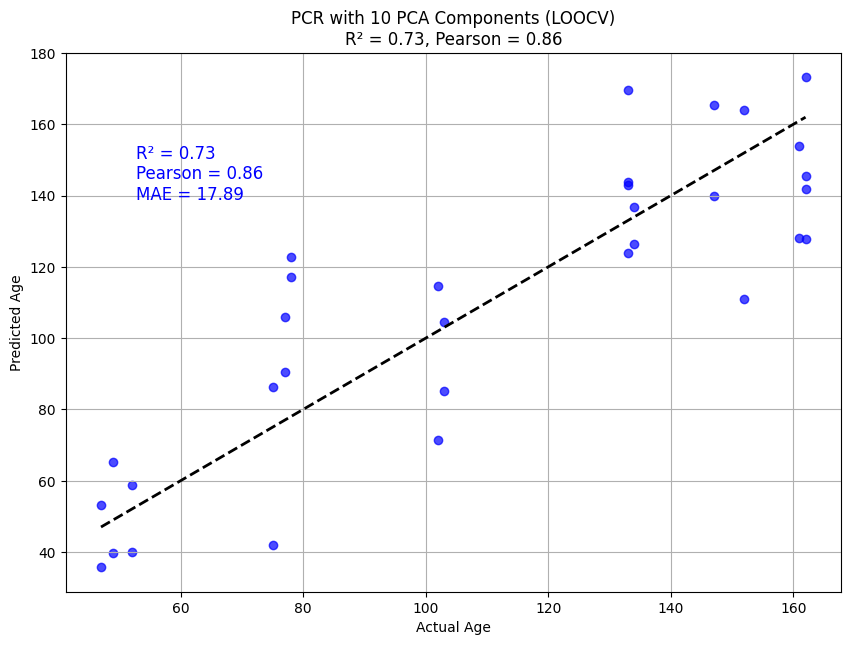


Explained Variance by Each of the First 20 Components:
Component  1: 0.1352 (Cumulative: 0.1352)
Component  2: 0.0966 (Cumulative: 0.2317)
Component  3: 0.0785 (Cumulative: 0.3102)
Component  4: 0.0644 (Cumulative: 0.3747)
Component  5: 0.0458 (Cumulative: 0.4205)
Component  6: 0.0401 (Cumulative: 0.4605)
Component  7: 0.0383 (Cumulative: 0.4988)
Component  8: 0.0367 (Cumulative: 0.5355)
Component  9: 0.0315 (Cumulative: 0.5670)
Component 10: 0.0302 (Cumulative: 0.5972)
Component 11: 0.0272 (Cumulative: 0.6244)
Component 12: 0.0253 (Cumulative: 0.6497)
Component 13: 0.0233 (Cumulative: 0.6730)
Component 14: 0.0226 (Cumulative: 0.6956)
Component 15: 0.0216 (Cumulative: 0.7172)
Component 16: 0.0214 (Cumulative: 0.7386)
Component 17: 0.0202 (Cumulative: 0.7588)
Component 18: 0.0200 (Cumulative: 0.7787)
Component 19: 0.0191 (Cumulative: 0.7979)
Component 20: 0.0188 (Cumulative: 0.8166)


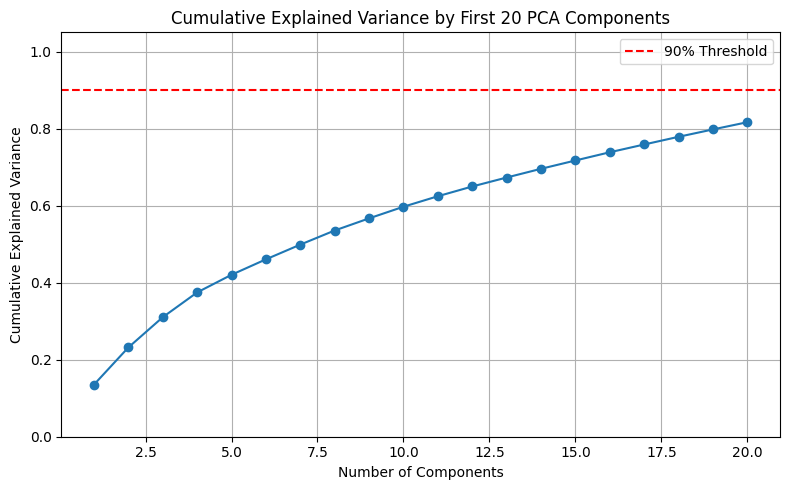

In [15]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Store results
results = []

# Loop through 1 to 20 components
for n_components in range(1, 21):
    pca = PCA(n_components=n_components, random_state=1)
    X_pca = pca.fit_transform(X_scaled)

    regressor = LinearRegression()
    y_pred = cross_val_predict(regressor, X_pca, y, cv=X.shape[0])  # LOOCV

    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    pearson_corr, _ = pearsonr(y, y_pred)

    results.append({
        'n_components': n_components,
        'mae': mae,
        'r2': r2,
        'pearson': pearson_corr,
        'y_pred': y_pred,
        'pca_model': pca
    })

    print(f"Components: {n_components:2d} | MAE: {mae:.2f} | R²: {r2:.3f} | Pearson: {pearson_corr:.3f}")

# Find the best result (lowest MAE)
best_result = min(results, key=lambda x: x['mae'])

# Unpack best model metrics
n_best = best_result['n_components']
y_pred_best = best_result['y_pred']
r2_best = best_result['r2']
pearson_best = best_result['pearson']
mae_best = best_result['mae']

# Plot predictions for the best model
plt.figure(figsize=(10, 7))
plt.scatter(y, y_pred_best, alpha=0.7, color='b')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title(f'PCR with {n_best} PCA Components (LOOCV)\nR² = {r2_best:.2f}, Pearson = {pearson_best:.2f}')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.2 * (y.max() - y.min()), f'MAE = {mae_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.1 * (y.max() - y.min()), f'R² = {r2_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.15 * (y.max() - y.min()), f'Pearson = {pearson_best:.2f}', fontsize=12, color='blue')
plt.grid(True)
plt.show()

# --- NEW: Explained variance using PCA with 20 components ---
pca_full = PCA(n_components=20, random_state=1)
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = explained_var.cumsum()

print("\nExplained Variance by Each of the First 20 Components:")
for i, (ev, cum_ev) in enumerate(zip(explained_var, cumulative_var), start=1):
    print(f"Component {i:2d}: {ev:.4f} (Cumulative: {cum_ev:.4f})")

# Optional: Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, 21), cumulative_var, marker='o', linestyle='-')
plt.title('Cumulative Explained Variance by First 20 PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.ylim(0, 1.05)
plt.grid(True)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Threshold')
plt.legend()
plt.tight_layout()
plt.show()

#### Female

In [16]:
gut_df_female = gut_df.loc[gut_df.iloc[:,-3] == "F"]

gut_df_female.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A1_1,23876.707871,687.004459,2181.018965,576.907591,221.294706,884.077854,1368.504075,1348.686639,619.845370,636.359900,...,243.314079,1718.612117,47.341653,568.099841,3323.824460,1566.678439,358.915791,F,Gut,155
A3_1,25474.794219,394.841817,2380.296399,618.502214,223.660397,730.957162,1441.922333,1626.848248,689.723681,502.298768,...,252.398883,1593.111763,31.237486,541.033250,3708.514285,2226.607970,314.873854,F,Gut,134
A4_1,21094.343422,503.698033,2804.802732,581.903780,319.450595,775.429867,1249.966435,1181.039336,534.185019,514.302202,...,172.317748,1569.417030,86.158874,393.679779,3952.704039,1851.753033,279.684961,F,Gut,75
B3_1,22964.583416,519.967810,4104.173403,560.983083,284.460761,871.905310,1450.088346,1251.627350,931.443609,633.752115,...,197.137923,1903.902491,115.107378,633.752115,3274.606439,1966.086936,330.768327,F,Gut,52
C1_1,26337.165612,643.910106,4019.779650,526.929653,286.757395,961.724258,1432.751747,1300.242915,731.904253,672.896413,...,190.481446,2030.076717,49.690812,661.508935,3735.092706,2305.446634,364.399288,F,Gut,52


In [17]:
gut_sub_df_female = gut_df_female.iloc[:,:-3]

gut_sub_df_female.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A1_1,23876.707871,687.004459,2181.018965,576.907591,221.294706,884.077854,1368.504075,1348.686639,619.845370,636.359900,...,913.804009,178.356927,1117.483215,243.314079,1718.612117,47.341653,568.099841,3323.824460,1566.678439,358.915791
A3_1,25474.794219,394.841817,2380.296399,618.502214,223.660397,730.957162,1441.922333,1626.848248,689.723681,502.298768,...,804.677628,153.688429,1270.740912,252.398883,1593.111763,31.237486,541.033250,3708.514285,2226.607970,314.873854
A4_1,21094.343422,503.698033,2804.802732,581.903780,319.450595,775.429867,1249.966435,1181.039336,534.185019,514.302202,...,770.127782,163.039100,1112.112236,172.317748,1569.417030,86.158874,393.679779,3952.704039,1851.753033,279.684961
B3_1,22964.583416,519.967810,4104.173403,560.983083,284.460761,871.905310,1450.088346,1251.627350,931.443609,633.752115,...,591.413769,140.245771,1239.719690,197.137923,1903.902491,115.107378,633.752115,3274.606439,1966.086936,330.768327
C1_1,26337.165612,643.910106,4019.779650,526.929653,286.757395,961.724258,1432.751747,1300.242915,731.904253,672.896413,...,800.229119,156.319013,1371.673458,190.481446,2030.076717,49.690812,661.508935,3735.092706,2305.446634,364.399288


In [18]:
gut_sub_df_female["age"] = gut_df_female["age_days"].tolist()

gut_sub_df_female.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A1_1,23876.707871,687.004459,2181.018965,576.907591,221.294706,884.077854,1368.504075,1348.686639,619.845370,636.359900,...,178.356927,1117.483215,243.314079,1718.612117,47.341653,568.099841,3323.824460,1566.678439,358.915791,155
A3_1,25474.794219,394.841817,2380.296399,618.502214,223.660397,730.957162,1441.922333,1626.848248,689.723681,502.298768,...,153.688429,1270.740912,252.398883,1593.111763,31.237486,541.033250,3708.514285,2226.607970,314.873854,134
A4_1,21094.343422,503.698033,2804.802732,581.903780,319.450595,775.429867,1249.966435,1181.039336,534.185019,514.302202,...,163.039100,1112.112236,172.317748,1569.417030,86.158874,393.679779,3952.704039,1851.753033,279.684961,75
B3_1,22964.583416,519.967810,4104.173403,560.983083,284.460761,871.905310,1450.088346,1251.627350,931.443609,633.752115,...,140.245771,1239.719690,197.137923,1903.902491,115.107378,633.752115,3274.606439,1966.086936,330.768327,52
C1_1,26337.165612,643.910106,4019.779650,526.929653,286.757395,961.724258,1432.751747,1300.242915,731.904253,672.896413,...,156.319013,1371.673458,190.481446,2030.076717,49.690812,661.508935,3735.092706,2305.446634,364.399288,52


In [19]:
gut_data_female = gut_sub_df_female.values

In [20]:
X, y = gut_data_female[:,:-1], gut_data_female[:,-1]

Components:  1 | MAE: 35.91 | R²: -0.115 | Pearson: -0.052
Components:  2 | MAE: 31.07 | R²: 0.030 | Pearson: 0.308
Components:  3 | MAE: 29.61 | R²: -0.062 | Pearson: 0.369


Components:  4 | MAE: 29.37 | R²: -0.069 | Pearson: 0.391
Components:  5 | MAE: 31.50 | R²: -0.283 | Pearson: 0.346
Components:  6 | MAE: 33.05 | R²: -0.390 | Pearson: 0.298
Components:  7 | MAE: 35.54 | R²: -0.558 | Pearson: 0.240
Components:  8 | MAE: 41.00 | R²: -1.172 | Pearson: 0.131
Components:  9 | MAE: 32.87 | R²: -0.071 | Pearson: 0.511
Components: 10 | MAE: 22.76 | R²: 0.349 | Pearson: 0.713
Components: 11 | MAE: 23.33 | R²: 0.283 | Pearson: 0.701
Components: 12 | MAE: 32.37 | R²: -0.709 | Pearson: 0.563
Components: 13 | MAE: 38.43 | R²: -1.522 | Pearson: 0.485
Components: 14 | MAE: 47.50 | R²: -4.291 | Pearson: 0.373
Components: 15 | MAE: 41.37 | R²: -3.041 | Pearson: 0.378
Components: 16 | MAE: 42.82 | R²: -2.916 | Pearson: 0.357
Components: 17 | MAE: 51.18 | R²: -3.334 | Pearson: 0.348
Components: 18 | MAE: 74.26 | R²: -7.824 | Pearson: 0.331
Components: 19 | MAE: 159.25 | R²: -45.593 | Pearson: 0.012
Components: 20 | MAE: 151.84 | R²: -41.864 | Pearson: -0.093


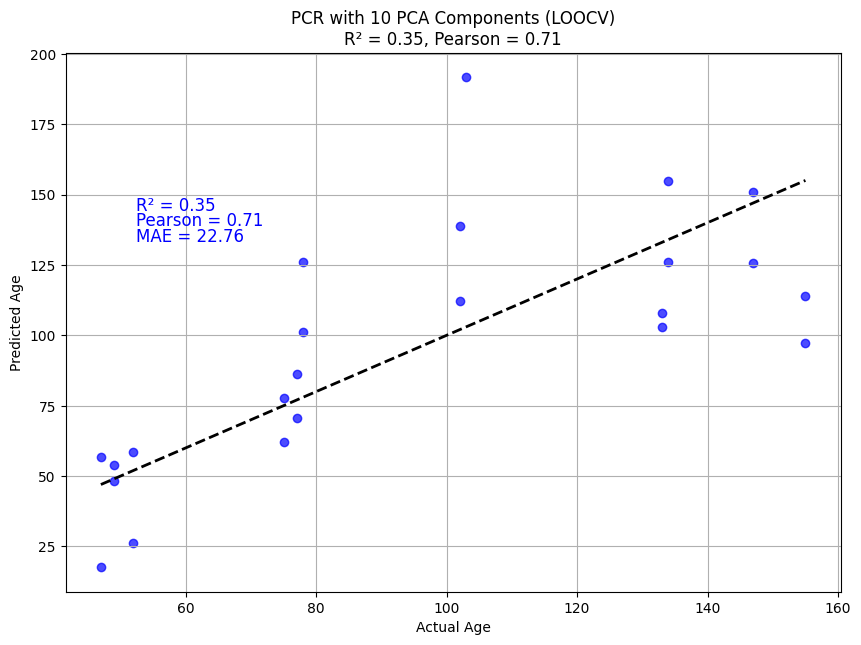


Explained Variance by Each of the First 20 Components:
Component  1: 0.1262 (Cumulative: 0.1262)
Component  2: 0.0978 (Cumulative: 0.2240)
Component  3: 0.0767 (Cumulative: 0.3008)
Component  4: 0.0642 (Cumulative: 0.3650)
Component  5: 0.0550 (Cumulative: 0.4199)
Component  6: 0.0519 (Cumulative: 0.4718)
Component  7: 0.0468 (Cumulative: 0.5186)
Component  8: 0.0430 (Cumulative: 0.5616)
Component  9: 0.0425 (Cumulative: 0.6041)
Component 10: 0.0383 (Cumulative: 0.6424)
Component 11: 0.0354 (Cumulative: 0.6778)
Component 12: 0.0348 (Cumulative: 0.7126)
Component 13: 0.0327 (Cumulative: 0.7452)
Component 14: 0.0315 (Cumulative: 0.7767)
Component 15: 0.0308 (Cumulative: 0.8075)
Component 16: 0.0300 (Cumulative: 0.8375)
Component 17: 0.0290 (Cumulative: 0.8666)
Component 18: 0.0278 (Cumulative: 0.8944)
Component 19: 0.0277 (Cumulative: 0.9221)
Component 20: 0.0265 (Cumulative: 0.9486)


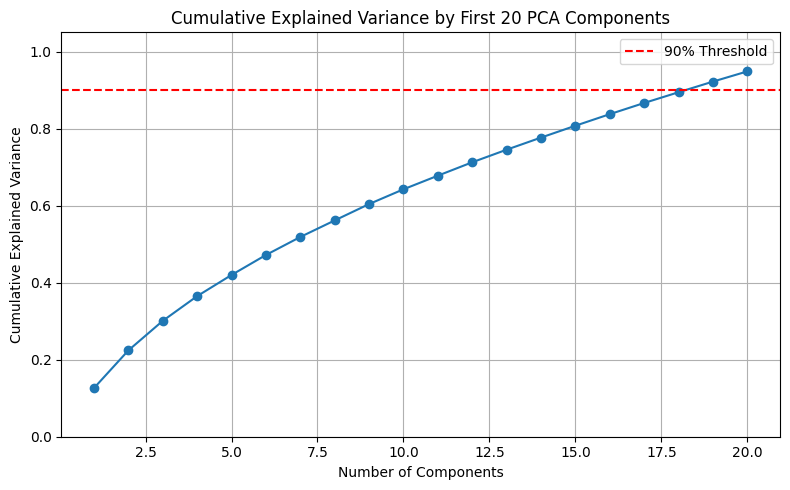

In [21]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Store results
results = []

# Loop through 1 to 20 components
for n_components in range(1, 21):
    pca = PCA(n_components=n_components, random_state=1)
    X_pca = pca.fit_transform(X_scaled)

    regressor = LinearRegression()
    y_pred = cross_val_predict(regressor, X_pca, y, cv=X.shape[0])  # LOOCV

    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    pearson_corr, _ = pearsonr(y, y_pred)

    results.append({
        'n_components': n_components,
        'mae': mae,
        'r2': r2,
        'pearson': pearson_corr,
        'y_pred': y_pred,
        'pca_model': pca
    })

    print(f"Components: {n_components:2d} | MAE: {mae:.2f} | R²: {r2:.3f} | Pearson: {pearson_corr:.3f}")

# Find the best result (lowest MAE)
best_result = min(results, key=lambda x: x['mae'])

# Unpack best model metrics
n_best = best_result['n_components']
y_pred_best = best_result['y_pred']
r2_best = best_result['r2']
pearson_best = best_result['pearson']
mae_best = best_result['mae']

# Plot predictions for the best model
plt.figure(figsize=(10, 7))
plt.scatter(y, y_pred_best, alpha=0.7, color='b')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title(f'PCR with {n_best} PCA Components (LOOCV)\nR² = {r2_best:.2f}, Pearson = {pearson_best:.2f}')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.2 * (y.max() - y.min()), f'MAE = {mae_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.1 * (y.max() - y.min()), f'R² = {r2_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.15 * (y.max() - y.min()), f'Pearson = {pearson_best:.2f}', fontsize=12, color='blue')
plt.grid(True)
plt.show()

# --- NEW: Explained variance using PCA with 20 components ---
pca_full = PCA(n_components=20, random_state=1)
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = explained_var.cumsum()

print("\nExplained Variance by Each of the First 20 Components:")
for i, (ev, cum_ev) in enumerate(zip(explained_var, cumulative_var), start=1):
    print(f"Component {i:2d}: {ev:.4f} (Cumulative: {cum_ev:.4f})")

# Optional: Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, 21), cumulative_var, marker='o', linestyle='-')
plt.title('Cumulative Explained Variance by First 20 PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.ylim(0, 1.05)
plt.grid(True)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Threshold')
plt.legend()
plt.tight_layout()
plt.show()

# Kidney

In [22]:
kidney_df = combined_df.loc[combined_df.iloc[:,-2] == "Kidney"]

kidney_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A10_1,4821.965545,907.596706,218.510659,554.051370,191.503723,684.175695,1125.288972,662.897504,586.787050,637.527352,...,112.938093,1122.015404,311.807344,542.593883,2612.307200,408.377598,391.191366,M,Kidney,133
A11_1,7011.583272,766.674115,222.103168,627.278822,272.285474,675.602523,1267.567871,975.767056,739.724358,713.703904,...,109.657631,1059.404232,398.670540,521.338398,1948.746206,360.569160,446.064940,M,Kidney,47
A12_1,7322.278018,732.665214,225.267215,592.693352,260.260180,651.743981,1162.787081,875.553156,586.132171,640.808680,...,111.540077,1065.827406,275.569603,626.957297,1945.025662,390.025761,450.534430,M,Kidney,161
A9_1,2831.666919,957.341072,263.063277,559.756802,399.078948,647.195448,1079.157306,842.998228,635.238026,610.575844,...,192.813424,1274.960085,330.323774,555.272769,3161.990693,289.220137,463.350090,F,Kidney,78
B10_1,6450.431017,785.062255,152.377915,537.184817,256.303867,585.636781,1329.971298,726.779458,588.445590,641.110768,...,100.414940,1010.469218,199.425475,639.706364,2482.987598,562.464102,502.776901,M,Kidney,147


In [23]:
kidney_df_male = kidney_df.loc[kidney_df.iloc[:,-3] == "M"]

kidney_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A10_1,4821.965545,907.596706,218.510659,554.051370,191.503723,684.175695,1125.288972,662.897504,586.787050,637.527352,...,112.938093,1122.015404,311.807344,542.593883,2612.307200,408.377598,391.191366,M,Kidney,133
A11_1,7011.583272,766.674115,222.103168,627.278822,272.285474,675.602523,1267.567871,975.767056,739.724358,713.703904,...,109.657631,1059.404232,398.670540,521.338398,1948.746206,360.569160,446.064940,M,Kidney,47
A12_1,7322.278018,732.665214,225.267215,592.693352,260.260180,651.743981,1162.787081,875.553156,586.132171,640.808680,...,111.540077,1065.827406,275.569603,626.957297,1945.025662,390.025761,450.534430,M,Kidney,161
B10_1,6450.431017,785.062255,152.377915,537.184817,256.303867,585.636781,1329.971298,726.779458,588.445590,641.110768,...,100.414940,1010.469218,199.425475,639.706364,2482.987598,562.464102,502.776901,M,Kidney,147
C10_1,2191.881729,1131.253113,245.924590,532.206035,206.828886,693.633459,1050.539402,646.970844,760.474501,645.709692,...,158.905120,1319.164723,321.593694,514.549911,3126.395170,524.639125,464.103841,M,Kidney,133


In [24]:
kidney_sub_df_male = kidney_df_male.iloc[:,:-3]
kidney_sub_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A10_1,4821.965545,907.596706,218.510659,554.051370,191.503723,684.175695,1125.288972,662.897504,586.787050,637.527352,...,520.497299,128.487541,1351.165159,112.938093,1122.015404,311.807344,542.593883,2612.307200,408.377598,391.191366
A11_1,7011.583272,766.674115,222.103168,627.278822,272.285474,675.602523,1267.567871,975.767056,739.724358,713.703904,...,420.973787,192.365505,1129.101879,109.657631,1059.404232,398.670540,521.338398,1948.746206,360.569160,446.064940
A12_1,7322.278018,732.665214,225.267215,592.693352,260.260180,651.743981,1162.787081,875.553156,586.132171,640.808680,...,580.300010,119.559299,1335.564848,111.540077,1065.827406,275.569603,626.957297,1945.025662,390.025761,450.534430
B10_1,6450.431017,785.062255,152.377915,537.184817,256.303867,585.636781,1329.971298,726.779458,588.445590,641.110768,...,599.680828,100.414940,1393.871714,100.414940,1010.469218,199.425475,639.706364,2482.987598,562.464102,502.776901
C10_1,2191.881729,1131.253113,245.924590,532.206035,206.828886,693.633459,1050.539402,646.970844,760.474501,645.709692,...,663.365817,161.427423,1315.381268,158.905120,1319.164723,321.593694,514.549911,3126.395170,524.639125,464.103841


In [25]:
kidney_sub_df_male["age"] = kidney_df_male["age_days"].tolist()

kidney_sub_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A10_1,4821.965545,907.596706,218.510659,554.051370,191.503723,684.175695,1125.288972,662.897504,586.787050,637.527352,...,128.487541,1351.165159,112.938093,1122.015404,311.807344,542.593883,2612.307200,408.377598,391.191366,133
A11_1,7011.583272,766.674115,222.103168,627.278822,272.285474,675.602523,1267.567871,975.767056,739.724358,713.703904,...,192.365505,1129.101879,109.657631,1059.404232,398.670540,521.338398,1948.746206,360.569160,446.064940,47
A12_1,7322.278018,732.665214,225.267215,592.693352,260.260180,651.743981,1162.787081,875.553156,586.132171,640.808680,...,119.559299,1335.564848,111.540077,1065.827406,275.569603,626.957297,1945.025662,390.025761,450.534430,161
B10_1,6450.431017,785.062255,152.377915,537.184817,256.303867,585.636781,1329.971298,726.779458,588.445590,641.110768,...,100.414940,1393.871714,100.414940,1010.469218,199.425475,639.706364,2482.987598,562.464102,502.776901,147
C10_1,2191.881729,1131.253113,245.924590,532.206035,206.828886,693.633459,1050.539402,646.970844,760.474501,645.709692,...,161.427423,1315.381268,158.905120,1319.164723,321.593694,514.549911,3126.395170,524.639125,464.103841,133


In [26]:
kidney_data_male = kidney_sub_df_male.values

In [27]:
X, y = kidney_data_male[:,:-1], kidney_data_male[:,-1]

Components:  1 | MAE: 40.29 | R²: -0.114 | Pearson: -0.272


Components:  2 | MAE: 26.73 | R²: 0.401 | Pearson: 0.640
Components:  3 | MAE: 16.49 | R²: 0.718 | Pearson: 0.848
Components:  4 | MAE: 17.23 | R²: 0.698 | Pearson: 0.838
Components:  5 | MAE: 18.28 | R²: 0.662 | Pearson: 0.820
Components:  6 | MAE: 19.19 | R²: 0.626 | Pearson: 0.801
Components:  7 | MAE: 19.50 | R²: 0.639 | Pearson: 0.809
Components:  8 | MAE: 17.35 | R²: 0.715 | Pearson: 0.851
Components:  9 | MAE: 18.82 | R²: 0.672 | Pearson: 0.829
Components: 10 | MAE: 16.54 | R²: 0.726 | Pearson: 0.860
Components: 11 | MAE: 16.48 | R²: 0.737 | Pearson: 0.866
Components: 12 | MAE: 18.36 | R²: 0.604 | Pearson: 0.810
Components: 13 | MAE: 17.27 | R²: 0.717 | Pearson: 0.860
Components: 14 | MAE: 18.74 | R²: 0.651 | Pearson: 0.846
Components: 15 | MAE: 19.84 | R²: 0.585 | Pearson: 0.839
Components: 16 | MAE: 21.86 | R²: 0.540 | Pearson: 0.816
Components: 17 | MAE: 22.99 | R²: 0.382 | Pearson: 0.790
Components: 18 | MAE: 26.13 | R²: 0.325 | Pearson: 0.772
Components: 19 | MAE: 27.34 | R

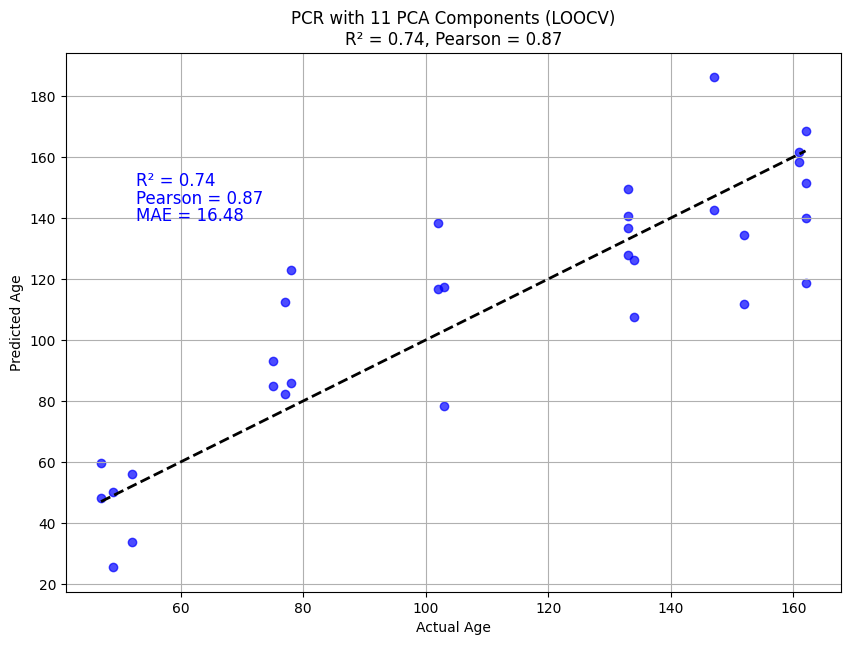


Explained Variance by Each of the First 20 Components:
Component  1: 0.2457 (Cumulative: 0.2457)
Component  2: 0.0812 (Cumulative: 0.3268)
Component  3: 0.0761 (Cumulative: 0.4030)
Component  4: 0.0498 (Cumulative: 0.4528)
Component  5: 0.0464 (Cumulative: 0.4991)
Component  6: 0.0420 (Cumulative: 0.5411)
Component  7: 0.0366 (Cumulative: 0.5777)
Component  8: 0.0330 (Cumulative: 0.6107)
Component  9: 0.0281 (Cumulative: 0.6388)
Component 10: 0.0227 (Cumulative: 0.6615)
Component 11: 0.0221 (Cumulative: 0.6836)
Component 12: 0.0204 (Cumulative: 0.7040)
Component 13: 0.0197 (Cumulative: 0.7237)
Component 14: 0.0191 (Cumulative: 0.7428)
Component 15: 0.0189 (Cumulative: 0.7617)
Component 16: 0.0177 (Cumulative: 0.7793)
Component 17: 0.0174 (Cumulative: 0.7967)
Component 18: 0.0168 (Cumulative: 0.8136)
Component 19: 0.0163 (Cumulative: 0.8298)
Component 20: 0.0161 (Cumulative: 0.8460)


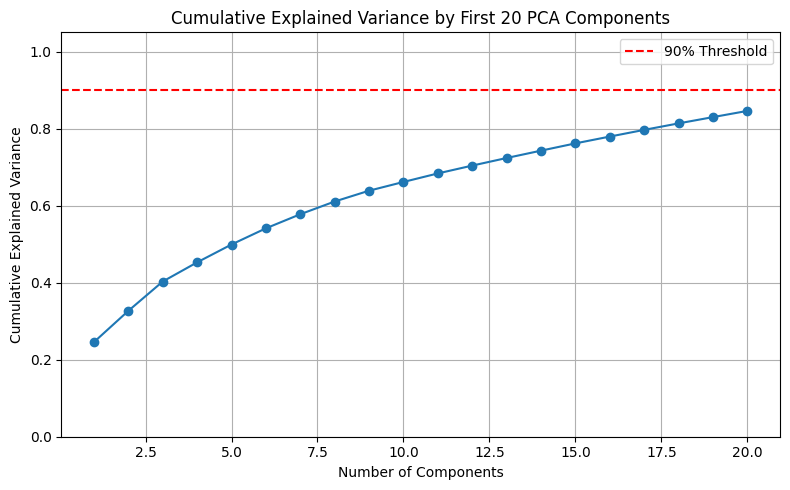

In [28]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Store results
results = []

# Loop through 1 to 20 components
for n_components in range(1, 21):
    pca = PCA(n_components=n_components, random_state=1)
    X_pca = pca.fit_transform(X_scaled)

    regressor = LinearRegression()
    y_pred = cross_val_predict(regressor, X_pca, y, cv=X.shape[0])  # LOOCV

    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    pearson_corr, _ = pearsonr(y, y_pred)

    results.append({
        'n_components': n_components,
        'mae': mae,
        'r2': r2,
        'pearson': pearson_corr,
        'y_pred': y_pred,
        'pca_model': pca
    })

    print(f"Components: {n_components:2d} | MAE: {mae:.2f} | R²: {r2:.3f} | Pearson: {pearson_corr:.3f}")

# Find the best result (lowest MAE)
best_result = min(results, key=lambda x: x['mae'])

# Unpack best model metrics
n_best = best_result['n_components']
y_pred_best = best_result['y_pred']
r2_best = best_result['r2']
pearson_best = best_result['pearson']
mae_best = best_result['mae']

# Plot predictions for the best model
plt.figure(figsize=(10, 7))
plt.scatter(y, y_pred_best, alpha=0.7, color='b')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title(f'PCR with {n_best} PCA Components (LOOCV)\nR² = {r2_best:.2f}, Pearson = {pearson_best:.2f}')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.2 * (y.max() - y.min()), f'MAE = {mae_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.1 * (y.max() - y.min()), f'R² = {r2_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.15 * (y.max() - y.min()), f'Pearson = {pearson_best:.2f}', fontsize=12, color='blue')
plt.grid(True)
plt.show()

# --- NEW: Explained variance using PCA with 20 components ---
pca_full = PCA(n_components=20, random_state=1)
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = explained_var.cumsum()

print("\nExplained Variance by Each of the First 20 Components:")
for i, (ev, cum_ev) in enumerate(zip(explained_var, cumulative_var), start=1):
    print(f"Component {i:2d}: {ev:.4f} (Cumulative: {cum_ev:.4f})")

# Optional: Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, 21), cumulative_var, marker='o', linestyle='-')
plt.title('Cumulative Explained Variance by First 20 PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.ylim(0, 1.05)
plt.grid(True)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Threshold')
plt.legend()
plt.tight_layout()
plt.show()

#### Female

In [29]:
kidney_df_female = kidney_df.loc[kidney_df.iloc[:,-3] == "F"]

kidney_df_female.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A9_1,2831.666919,957.341072,263.063277,559.756802,399.078948,647.195448,1079.157306,842.998228,635.238026,610.575844,...,192.813424,1274.960085,330.323774,555.272769,3161.990693,289.220137,463.350090,F,Kidney,78
B11_1,4008.974389,1184.107667,249.565293,654.002665,358.418240,650.462732,954.896990,562.849384,624.798216,689.401998,...,162.836929,1531.906108,292.044492,551.344601,3534.623336,403.552389,492.935703,F,Kidney,147
B12_1,6201.808902,822.555707,243.324560,574.483351,321.663199,851.042485,986.354679,1042.141285,760.834355,710.982494,...,144.807787,1153.714498,188.724902,489.023018,1469.442951,261.128796,376.262856,F,Kidney,49
B9_1,4603.395213,711.466940,201.193520,595.561978,353.546584,571.506231,951.295448,789.465877,637.112813,629.823193,...,129.026279,1109.480208,112.260152,561.300762,3228.572826,403.844964,650.234130,F,Kidney,134
E10_1,3009.785292,659.286302,136.331738,548.123500,312.514292,565.601928,1059.891871,825.680936,600.558784,553.017460,...,146.119658,1038.917757,94.383511,543.229541,3874.617907,415.287448,378.233181,F,Kidney,103


In [30]:
kidney_sub_df_female = kidney_df_female.iloc[:,:-3]

kidney_sub_df_female.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A9_1,2831.666919,957.341072,263.063277,559.756802,399.078948,647.195448,1079.157306,842.998228,635.238026,610.575844,...,550.788736,183.098019,1128.481670,192.813424,1274.960085,330.323774,555.272769,3161.990693,289.220137,463.350090
B11_1,4008.974389,1184.107667,249.565293,654.002665,358.418240,650.462732,954.896990,562.849384,624.798216,689.401998,...,632.763066,192.926361,1256.676299,162.836929,1531.906108,292.044492,551.344601,3534.623336,403.552389,492.935703
B12_1,6201.808902,822.555707,243.324560,574.483351,321.663199,851.042485,986.354679,1042.141285,760.834355,710.982494,...,441.545055,185.164055,1126.414669,144.807787,1153.714498,188.724902,489.023018,1469.442951,261.128796,376.262856
B9_1,4603.395213,711.466940,201.193520,595.561978,353.546584,571.506231,951.295448,789.465877,637.112813,629.823193,...,723.859295,126.110431,1219.553474,129.026279,1109.480208,112.260152,561.300762,3228.572826,403.844964,650.234130
E10_1,3009.785292,659.286302,136.331738,548.123500,312.514292,565.601928,1059.891871,825.680936,600.558784,553.017460,...,741.784482,106.967979,1510.136174,146.119658,1038.917757,94.383511,543.229541,3874.617907,415.287448,378.233181


In [31]:
kidney_sub_df_female["age"] = kidney_df_female["age_days"].tolist()

kidney_sub_df_female.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A9_1,2831.666919,957.341072,263.063277,559.756802,399.078948,647.195448,1079.157306,842.998228,635.238026,610.575844,...,183.098019,1128.481670,192.813424,1274.960085,330.323774,555.272769,3161.990693,289.220137,463.350090,78
B11_1,4008.974389,1184.107667,249.565293,654.002665,358.418240,650.462732,954.896990,562.849384,624.798216,689.401998,...,192.926361,1256.676299,162.836929,1531.906108,292.044492,551.344601,3534.623336,403.552389,492.935703,147
B12_1,6201.808902,822.555707,243.324560,574.483351,321.663199,851.042485,986.354679,1042.141285,760.834355,710.982494,...,185.164055,1126.414669,144.807787,1153.714498,188.724902,489.023018,1469.442951,261.128796,376.262856,49
B9_1,4603.395213,711.466940,201.193520,595.561978,353.546584,571.506231,951.295448,789.465877,637.112813,629.823193,...,126.110431,1219.553474,129.026279,1109.480208,112.260152,561.300762,3228.572826,403.844964,650.234130,134
E10_1,3009.785292,659.286302,136.331738,548.123500,312.514292,565.601928,1059.891871,825.680936,600.558784,553.017460,...,106.967979,1510.136174,146.119658,1038.917757,94.383511,543.229541,3874.617907,415.287448,378.233181,103


In [32]:
kidney_data_female = kidney_sub_df_female.values

In [33]:
X, y = kidney_data_female[:,:-1], kidney_data_female[:,-1]

Components:  1 | MAE: 28.52 | R²: 0.197 | Pearson: 0.458
Components:  2 | MAE: 30.77 | R²: 0.078 | Pearson: 0.429


Components:  3 | MAE: 34.63 | R²: -0.382 | Pearson: 0.309
Components:  4 | MAE: 37.39 | R²: -0.565 | Pearson: 0.270
Components:  5 | MAE: 40.88 | R²: -0.841 | Pearson: 0.225
Components:  6 | MAE: 44.31 | R²: -1.132 | Pearson: 0.197
Components:  7 | MAE: 21.97 | R²: 0.247 | Pearson: 0.668
Components:  8 | MAE: 24.68 | R²: 0.186 | Pearson: 0.667
Components:  9 | MAE: 27.36 | R²: 0.096 | Pearson: 0.636
Components: 10 | MAE: 30.89 | R²: -0.115 | Pearson: 0.563
Components: 11 | MAE: 34.63 | R²: -0.368 | Pearson: 0.495
Components: 12 | MAE: 27.61 | R²: 0.016 | Pearson: 0.601
Components: 13 | MAE: 34.93 | R²: -0.214 | Pearson: 0.643
Components: 14 | MAE: 22.37 | R²: 0.491 | Pearson: 0.802
Components: 15 | MAE: 33.13 | R²: -0.353 | Pearson: 0.522
Components: 16 | MAE: 35.56 | R²: -0.493 | Pearson: 0.468
Components: 17 | MAE: 56.08 | R²: -3.384 | Pearson: 0.468
Components: 18 | MAE: 74.46 | R²: -7.240 | Pearson: 0.399
Components: 19 | MAE: 91.92 | R²: -8.996 | Pearson: 0.359
Components: 20 | MA

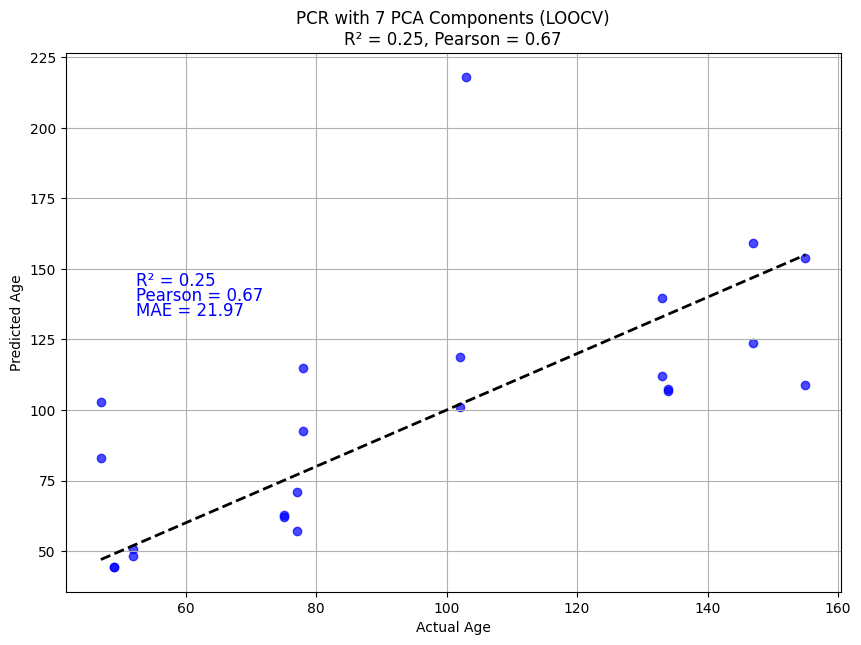


Explained Variance by Each of the First 20 Components:
Component  1: 0.1716 (Cumulative: 0.1716)
Component  2: 0.1305 (Cumulative: 0.3021)
Component  3: 0.0829 (Cumulative: 0.3850)
Component  4: 0.0665 (Cumulative: 0.4514)
Component  5: 0.0552 (Cumulative: 0.5066)
Component  6: 0.0489 (Cumulative: 0.5555)
Component  7: 0.0421 (Cumulative: 0.5977)
Component  8: 0.0410 (Cumulative: 0.6387)
Component  9: 0.0359 (Cumulative: 0.6746)
Component 10: 0.0323 (Cumulative: 0.7069)
Component 11: 0.0305 (Cumulative: 0.7374)
Component 12: 0.0294 (Cumulative: 0.7667)
Component 13: 0.0275 (Cumulative: 0.7943)
Component 14: 0.0258 (Cumulative: 0.8201)
Component 15: 0.0249 (Cumulative: 0.8450)
Component 16: 0.0242 (Cumulative: 0.8692)
Component 17: 0.0238 (Cumulative: 0.8930)
Component 18: 0.0231 (Cumulative: 0.9162)
Component 19: 0.0221 (Cumulative: 0.9383)
Component 20: 0.0217 (Cumulative: 0.9600)


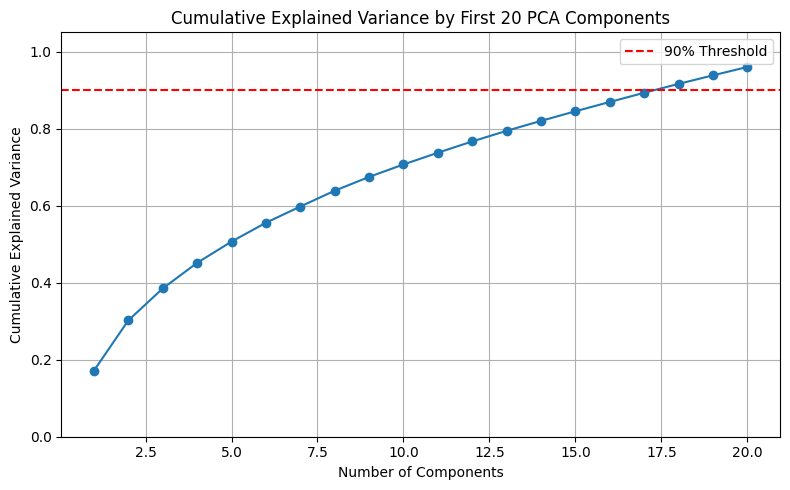

In [34]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Store results
results = []

# Loop through 1 to 20 components
for n_components in range(1, 21):
    pca = PCA(n_components=n_components, random_state=1)
    X_pca = pca.fit_transform(X_scaled)

    regressor = LinearRegression()
    y_pred = cross_val_predict(regressor, X_pca, y, cv=X.shape[0])  # LOOCV

    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    pearson_corr, _ = pearsonr(y, y_pred)

    results.append({
        'n_components': n_components,
        'mae': mae,
        'r2': r2,
        'pearson': pearson_corr,
        'y_pred': y_pred,
        'pca_model': pca
    })

    print(f"Components: {n_components:2d} | MAE: {mae:.2f} | R²: {r2:.3f} | Pearson: {pearson_corr:.3f}")

# Find the best result (lowest MAE)
best_result = min(results, key=lambda x: x['mae'])

# Unpack best model metrics
n_best = best_result['n_components']
y_pred_best = best_result['y_pred']
r2_best = best_result['r2']
pearson_best = best_result['pearson']
mae_best = best_result['mae']

# Plot predictions for the best model
plt.figure(figsize=(10, 7))
plt.scatter(y, y_pred_best, alpha=0.7, color='b')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title(f'PCR with {n_best} PCA Components (LOOCV)\nR² = {r2_best:.2f}, Pearson = {pearson_best:.2f}')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.2 * (y.max() - y.min()), f'MAE = {mae_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.1 * (y.max() - y.min()), f'R² = {r2_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.15 * (y.max() - y.min()), f'Pearson = {pearson_best:.2f}', fontsize=12, color='blue')
plt.grid(True)
plt.show()

# --- NEW: Explained variance using PCA with 20 components ---
pca_full = PCA(n_components=20, random_state=1)
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = explained_var.cumsum()

print("\nExplained Variance by Each of the First 20 Components:")
for i, (ev, cum_ev) in enumerate(zip(explained_var, cumulative_var), start=1):
    print(f"Component {i:2d}: {ev:.4f} (Cumulative: {cum_ev:.4f})")

# Optional: Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, 21), cumulative_var, marker='o', linestyle='-')
plt.title('Cumulative Explained Variance by First 20 PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.ylim(0, 1.05)
plt.grid(True)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Threshold')
plt.legend()
plt.tight_layout()
plt.show()

# Muscle

In [35]:
muscle_df = combined_df.loc[combined_df.iloc[:,-2] == "Muscle"]

muscle_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A13_1,2.350903,453.724234,134.001458,712.323538,481.935067,1024.993606,886.290343,2868.101375,759.341594,702.919927,...,96.387013,883.939440,14.105417,1288.294716,1539.841312,298.564651,347.933609,M,Muscle,134
A14_1,1.880148,327.145692,174.853732,627.969318,370.389089,844.186298,789.662016,2120.806558,693.774486,667.452418,...,58.284577,889.309842,13.161034,1154.410662,1583.084328,454.995733,344.067021,M,Muscle,147
A15_1,3.992771,419.240920,139.746973,778.590280,395.284296,934.308337,527.045728,2367.713007,842.474611,491.110792,...,155.718056,914.344483,11.978312,1094.019163,1481.317918,235.573469,331.399966,M,Muscle,52
A16_1,1.631269,482.855494,84.825965,908.616589,363.772889,944.504497,885.778829,2233.206661,1295.227238,750.383538,...,138.657828,614.988248,8.156343,960.817183,1249.551718,107.663725,438.811243,F,Muscle,103
B13_1,1.771236,504.802247,99.189213,825.395955,480.004944,1013.146966,998.977078,2463.789213,981.264719,793.513708,...,123.986517,683.697078,8.856180,1225.695280,1712.785168,258.600449,356.018427,F,Muscle,155


In [36]:
muscle_df_male = muscle_df.loc[muscle_df.iloc[:,-3] == "M"]

muscle_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A13_1,2.350903,453.724234,134.001458,712.323538,481.935067,1024.993606,886.290343,2868.101375,759.341594,702.919927,...,96.387013,883.939440,14.105417,1288.294716,1539.841312,298.564651,347.933609,M,Muscle,134
A14_1,1.880148,327.145692,174.853732,627.969318,370.389089,844.186298,789.662016,2120.806558,693.774486,667.452418,...,58.284577,889.309842,13.161034,1154.410662,1583.084328,454.995733,344.067021,M,Muscle,147
A15_1,3.992771,419.240920,139.746973,778.590280,395.284296,934.308337,527.045728,2367.713007,842.474611,491.110792,...,155.718056,914.344483,11.978312,1094.019163,1481.317918,235.573469,331.399966,M,Muscle,52
B15_1,9.285661,508.058322,78.264859,967.035292,348.875558,1122.238487,1540.093242,1349.073926,3329.572815,1822.642649,...,423.160848,902.035663,19.897846,687.138932,1776.214343,244.080238,241.427192,M,Muscle,102
B16_1,2.358013,544.700927,77.814418,811.156359,261.739406,1436.029716,929.056992,1794.447642,1973.656605,1058.747689,...,134.406722,728.625915,21.222114,839.452511,1494.980033,162.702874,282.961520,M,Muscle,133


In [37]:
muscle_sub_df_male = muscle_df_male.iloc[:,:-3]
muscle_sub_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A13_1,2.350903,453.724234,134.001458,712.323538,481.935067,1024.993606,886.290343,2868.101375,759.341594,702.919927,...,700.569024,51.719861,1036.748120,96.387013,883.939440,14.105417,1288.294716,1539.841312,298.564651,347.933609
A14_1,1.880148,327.145692,174.853732,627.969318,370.389089,844.186298,789.662016,2120.806558,693.774486,667.452418,...,755.819358,43.243396,960.755453,58.284577,889.309842,13.161034,1154.410662,1583.084328,454.995733,344.067021
A15_1,3.992771,419.240920,139.746973,778.590280,395.284296,934.308337,527.045728,2367.713007,842.474611,491.110792,...,642.836078,31.942165,914.344483,155.718056,914.344483,11.978312,1094.019163,1481.317918,235.573469,331.399966
B15_1,9.285661,508.058322,78.264859,967.035292,348.875558,1122.238487,1540.093242,1349.073926,3329.572815,1822.642649,...,202.958024,102.142274,883.464341,423.160848,902.035663,19.897846,687.138932,1776.214343,244.080238,241.427192
B16_1,2.358013,544.700927,77.814418,811.156359,261.739406,1436.029716,929.056992,1794.447642,1973.656605,1058.747689,...,323.047736,87.246469,483.392597,134.406722,728.625915,21.222114,839.452511,1494.980033,162.702874,282.961520


In [38]:
muscle_sub_df_male["age"] = muscle_df_male["age_days"].tolist()

muscle_sub_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A13_1,2.350903,453.724234,134.001458,712.323538,481.935067,1024.993606,886.290343,2868.101375,759.341594,702.919927,...,51.719861,1036.748120,96.387013,883.939440,14.105417,1288.294716,1539.841312,298.564651,347.933609,134
A14_1,1.880148,327.145692,174.853732,627.969318,370.389089,844.186298,789.662016,2120.806558,693.774486,667.452418,...,43.243396,960.755453,58.284577,889.309842,13.161034,1154.410662,1583.084328,454.995733,344.067021,147
A15_1,3.992771,419.240920,139.746973,778.590280,395.284296,934.308337,527.045728,2367.713007,842.474611,491.110792,...,31.942165,914.344483,155.718056,914.344483,11.978312,1094.019163,1481.317918,235.573469,331.399966,52
B15_1,9.285661,508.058322,78.264859,967.035292,348.875558,1122.238487,1540.093242,1349.073926,3329.572815,1822.642649,...,102.142274,883.464341,423.160848,902.035663,19.897846,687.138932,1776.214343,244.080238,241.427192,102
B16_1,2.358013,544.700927,77.814418,811.156359,261.739406,1436.029716,929.056992,1794.447642,1973.656605,1058.747689,...,87.246469,483.392597,134.406722,728.625915,21.222114,839.452511,1494.980033,162.702874,282.961520,133


In [39]:
muscle_data_male = muscle_sub_df_male.values

In [40]:
X, y = muscle_data_male[:,:-1], muscle_data_male[:,-1]

Components:  1 | MAE: 36.14 | R²: -0.029 | Pearson: 0.233
Components:  2 | MAE: 19.74 | R²: 0.675 | Pearson: 0.825
Components:  3 | MAE: 19.00 | R²: 0.702 | Pearson: 0.840
Components:  4 | MAE: 17.14 | R²: 0.763 | Pearson: 0.875
Components:  5 | MAE: 17.54 | R²: 0.746 | Pearson: 0.865
Components:  6 | MAE: 16.62 | R²: 0.756 | Pearson: 0.872
Components:  7 | MAE: 17.17 | R²: 0.743 | Pearson: 0.865
Components:  8 | MAE: 15.36 | R²: 0.782 | Pearson: 0.887
Components:  9 | MAE: 15.69 | R²: 0.775 | Pearson: 0.884
Components: 10 | MAE: 16.49 | R²: 0.762 | Pearson: 0.879
Components: 11 | MAE: 16.29 | R²: 0.669 | Pearson: 0.841
Components: 12 | MAE: 18.44 | R²: 0.692 | Pearson: 0.851
Components: 13 | MAE: 16.93 | R²: 0.709 | Pearson: 0.860
Components: 14 | MAE: 18.81 | R²: 0.662 | Pearson: 0.848
Components: 15 | MAE: 21.69 | R²: 0.474 | Pearson: 0.781
Components: 16 | MAE: 22.11 | R²: 0.495 | Pearson: 0.815
Components: 17 | MAE: 27.77 | R²: 0.185 | Pearson: 0.713
Components: 18 | MAE: 28.32 | 

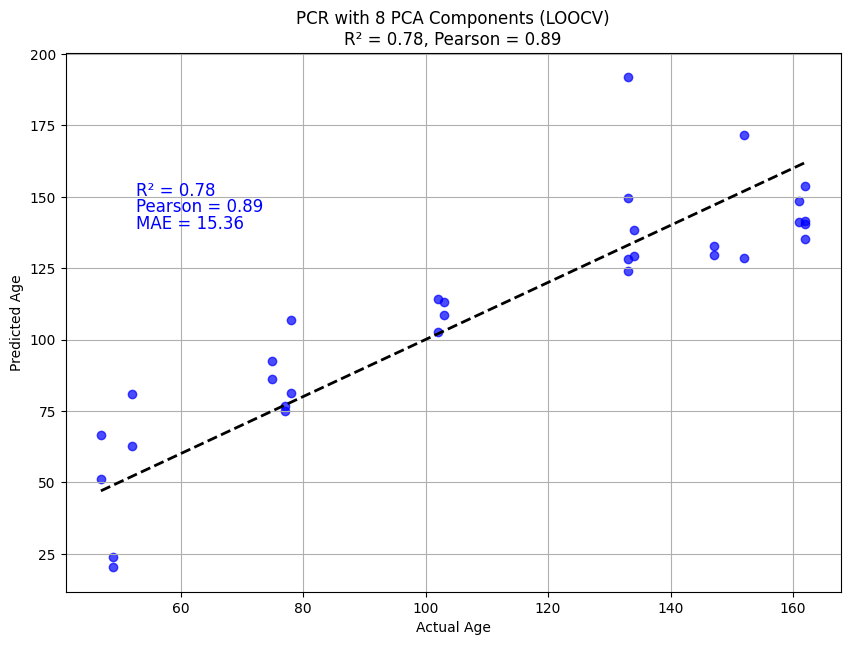


Explained Variance by Each of the First 20 Components:
Component  1: 0.1851 (Cumulative: 0.1851)
Component  2: 0.1087 (Cumulative: 0.2938)
Component  3: 0.0857 (Cumulative: 0.3795)
Component  4: 0.0554 (Cumulative: 0.4349)
Component  5: 0.0459 (Cumulative: 0.4808)
Component  6: 0.0371 (Cumulative: 0.5179)
Component  7: 0.0312 (Cumulative: 0.5492)
Component  8: 0.0280 (Cumulative: 0.5771)
Component  9: 0.0258 (Cumulative: 0.6030)
Component 10: 0.0246 (Cumulative: 0.6275)
Component 11: 0.0231 (Cumulative: 0.6506)
Component 12: 0.0220 (Cumulative: 0.6727)
Component 13: 0.0210 (Cumulative: 0.6936)
Component 14: 0.0204 (Cumulative: 0.7140)
Component 15: 0.0198 (Cumulative: 0.7338)
Component 16: 0.0194 (Cumulative: 0.7531)
Component 17: 0.0188 (Cumulative: 0.7720)
Component 18: 0.0185 (Cumulative: 0.7904)
Component 19: 0.0180 (Cumulative: 0.8084)
Component 20: 0.0177 (Cumulative: 0.8261)


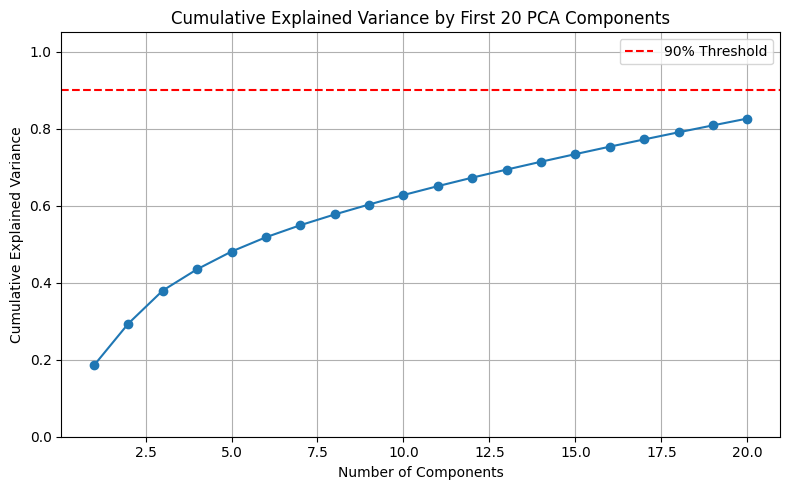

In [41]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Store results
results = []

# Loop through 1 to 20 components
for n_components in range(1, 21):
    pca = PCA(n_components=n_components, random_state=1)
    X_pca = pca.fit_transform(X_scaled)

    regressor = LinearRegression()
    y_pred = cross_val_predict(regressor, X_pca, y, cv=X.shape[0])  # LOOCV

    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    pearson_corr, _ = pearsonr(y, y_pred)

    results.append({
        'n_components': n_components,
        'mae': mae,
        'r2': r2,
        'pearson': pearson_corr,
        'y_pred': y_pred,
        'pca_model': pca
    })

    print(f"Components: {n_components:2d} | MAE: {mae:.2f} | R²: {r2:.3f} | Pearson: {pearson_corr:.3f}")

# Find the best result (lowest MAE)
best_result = min(results, key=lambda x: x['mae'])

# Unpack best model metrics
n_best = best_result['n_components']
y_pred_best = best_result['y_pred']
r2_best = best_result['r2']
pearson_best = best_result['pearson']
mae_best = best_result['mae']

# Plot predictions for the best model
plt.figure(figsize=(10, 7))
plt.scatter(y, y_pred_best, alpha=0.7, color='b')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title(f'PCR with {n_best} PCA Components (LOOCV)\nR² = {r2_best:.2f}, Pearson = {pearson_best:.2f}')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.2 * (y.max() - y.min()), f'MAE = {mae_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.1 * (y.max() - y.min()), f'R² = {r2_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.15 * (y.max() - y.min()), f'Pearson = {pearson_best:.2f}', fontsize=12, color='blue')
plt.grid(True)
plt.show()

# --- NEW: Explained variance using PCA with 20 components ---
pca_full = PCA(n_components=20, random_state=1)
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = explained_var.cumsum()

print("\nExplained Variance by Each of the First 20 Components:")
for i, (ev, cum_ev) in enumerate(zip(explained_var, cumulative_var), start=1):
    print(f"Component {i:2d}: {ev:.4f} (Cumulative: {cum_ev:.4f})")

# Optional: Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, 21), cumulative_var, marker='o', linestyle='-')
plt.title('Cumulative Explained Variance by First 20 PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.ylim(0, 1.05)
plt.grid(True)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Threshold')
plt.legend()
plt.tight_layout()
plt.show()

#### Female

In [42]:
muscle_df_female = muscle_df.loc[muscle_df.iloc[:,-3] == "F"]

muscle_df_female.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A16_1,1.631269,482.855494,84.825965,908.616589,363.772889,944.504497,885.778829,2233.206661,1295.227238,750.383538,...,138.657828,614.988248,8.156343,960.817183,1249.551718,107.663725,438.811243,F,Muscle,103
B13_1,1.771236,504.802247,99.189213,825.395955,480.004944,1013.146966,998.977078,2463.789213,981.264719,793.513708,...,123.986517,683.697078,8.856180,1225.695280,1712.785168,258.600449,356.018427,F,Muscle,155
B14_1,11.425531,536.999954,260.502106,539.285061,429.599964,1042.008422,767.795680,1631.565819,918.612688,431.885070,...,89.119141,966.599918,68.553186,902.616945,1544.731784,404.463795,379.327627,F,Muscle,77
C15_1,2.699865,448.177510,110.694445,693.865182,315.884149,1158.241879,674.966130,1803.509499,1241.937679,683.065724,...,126.893632,664.166672,29.698510,1347.232395,1892.605028,350.982388,348.282523,F,Muscle,134
D13_1,97.927266,349.422289,166.921476,750.033831,454.026414,750.033831,843.509857,2152.174227,934.760264,600.917313,...,129.085941,721.100775,28.933056,794.546225,1531.226337,344.971050,338.294191,F,Muscle,102


In [43]:
muscle_sub_df_female = muscle_df_female.iloc[:,:-3]

muscle_sub_df_female.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A16_1,1.631269,482.855494,84.825965,908.616589,363.772889,944.504497,885.778829,2233.206661,1295.227238,750.383538,...,468.174077,40.781714,610.094442,138.657828,614.988248,8.156343,960.817183,1249.551718,107.663725,438.811243
B13_1,1.771236,504.802247,99.189213,825.395955,480.004944,1013.146966,998.977078,2463.789213,981.264719,793.513708,...,706.723146,83.248090,825.395955,123.986517,683.697078,8.856180,1225.695280,1712.785168,258.600449,356.018427
B14_1,11.425531,536.999954,260.502106,539.285061,429.599964,1042.008422,767.795680,1631.565819,918.612688,431.885070,...,530.144636,29.706380,792.931848,89.119141,966.599918,68.553186,902.616945,1544.731784,404.463795,379.327627
C15_1,2.699865,448.177510,110.694445,693.865182,315.884149,1158.241879,674.966130,1803.509499,1241.937679,683.065724,...,531.873310,35.098239,845.057595,126.893632,664.166672,29.698510,1347.232395,1892.605028,350.982388,348.282523
D13_1,97.927266,349.422289,166.921476,750.033831,454.026414,750.033831,843.509857,2152.174227,934.760264,600.917313,...,474.056991,57.866112,723.326395,129.085941,721.100775,28.933056,794.546225,1531.226337,344.971050,338.294191


In [44]:
muscle_sub_df_female["age"] = muscle_df_female["age_days"].tolist()

muscle_sub_df_female.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A16_1,1.631269,482.855494,84.825965,908.616589,363.772889,944.504497,885.778829,2233.206661,1295.227238,750.383538,...,40.781714,610.094442,138.657828,614.988248,8.156343,960.817183,1249.551718,107.663725,438.811243,103
B13_1,1.771236,504.802247,99.189213,825.395955,480.004944,1013.146966,998.977078,2463.789213,981.264719,793.513708,...,83.248090,825.395955,123.986517,683.697078,8.856180,1225.695280,1712.785168,258.600449,356.018427,155
B14_1,11.425531,536.999954,260.502106,539.285061,429.599964,1042.008422,767.795680,1631.565819,918.612688,431.885070,...,29.706380,792.931848,89.119141,966.599918,68.553186,902.616945,1544.731784,404.463795,379.327627,77
C15_1,2.699865,448.177510,110.694445,693.865182,315.884149,1158.241879,674.966130,1803.509499,1241.937679,683.065724,...,35.098239,845.057595,126.893632,664.166672,29.698510,1347.232395,1892.605028,350.982388,348.282523,134
D13_1,97.927266,349.422289,166.921476,750.033831,454.026414,750.033831,843.509857,2152.174227,934.760264,600.917313,...,57.866112,723.326395,129.085941,721.100775,28.933056,794.546225,1531.226337,344.971050,338.294191,102


In [45]:
muscle_data_female = muscle_sub_df_female.values

In [46]:
X, y = muscle_data_female[:,:-1], muscle_data_female[:,-1]

Components:  1 | MAE: 21.39 | R²: 0.459 | Pearson: 0.683
Components:  2 | MAE: 21.22 | R²: 0.452 | Pearson: 0.680
Components:  3 | MAE: 22.48 | R²: 0.453 | Pearson: 0.689
Components:  4 | MAE: 19.67 | R²: 0.587 | Pearson: 0.774
Components:  5 | MAE: 20.32 | R²: 0.534 | Pearson: 0.744
Components:  6 | MAE: 23.30 | R²: 0.332 | Pearson: 0.666
Components:  7 | MAE: 20.82 | R²: 0.555 | Pearson: 0.803
Components:  8 | MAE: 25.81 | R²: 0.199 | Pearson: 0.720
Components:  9 | MAE: 26.96 | R²: 0.186 | Pearson: 0.715
Components: 10 | MAE: 28.71 | R²: -0.136 | Pearson: 0.670
Components: 11 | MAE: 32.36 | R²: -0.459 | Pearson: 0.637
Components: 12 | MAE: 40.12 | R²: -1.710 | Pearson: 0.528
Components: 13 | MAE: 32.26 | R²: -0.382 | Pearson: 0.684
Components: 14 | MAE: 34.91 | R²: -0.640 | Pearson: 0.631
Components: 15 | MAE: 36.60 | R²: -0.800 | Pearson: 0.598
Components: 16 | MAE: 39.50 | R²: -1.140 | Pearson: 0.549
Components: 17 | MAE: 29.73 | R²: -0.549 | Pearson: 0.583
Components: 18 | MAE: 3

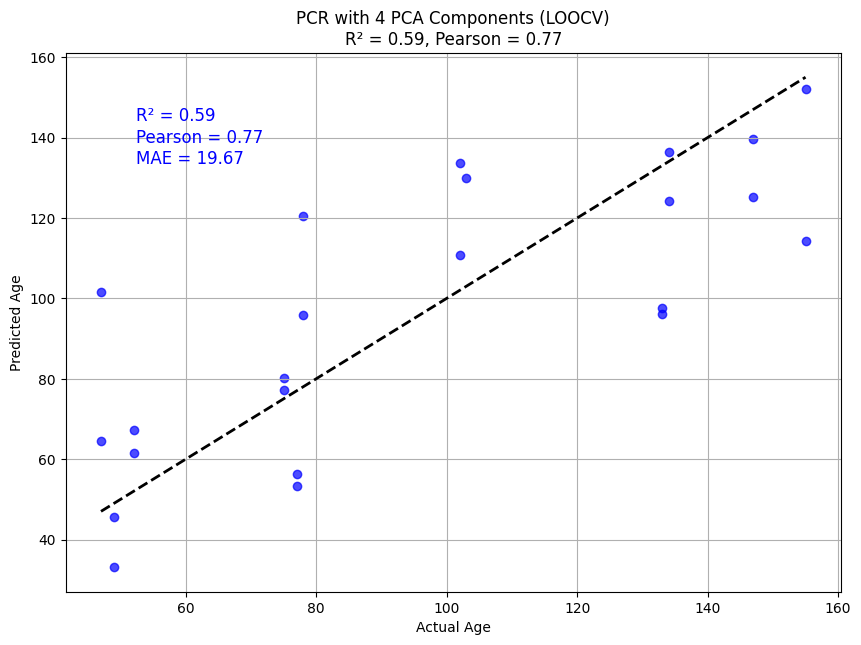


Explained Variance by Each of the First 20 Components:
Component  1: 0.1617 (Cumulative: 0.1617)
Component  2: 0.1116 (Cumulative: 0.2733)
Component  3: 0.0750 (Cumulative: 0.3483)
Component  4: 0.0615 (Cumulative: 0.4097)
Component  5: 0.0486 (Cumulative: 0.4583)
Component  6: 0.0453 (Cumulative: 0.5036)
Component  7: 0.0429 (Cumulative: 0.5465)
Component  8: 0.0424 (Cumulative: 0.5888)
Component  9: 0.0365 (Cumulative: 0.6253)
Component 10: 0.0334 (Cumulative: 0.6588)
Component 11: 0.0329 (Cumulative: 0.6917)
Component 12: 0.0315 (Cumulative: 0.7232)
Component 13: 0.0307 (Cumulative: 0.7539)
Component 14: 0.0296 (Cumulative: 0.7835)
Component 15: 0.0294 (Cumulative: 0.8129)
Component 16: 0.0288 (Cumulative: 0.8417)
Component 17: 0.0278 (Cumulative: 0.8695)
Component 18: 0.0274 (Cumulative: 0.8968)
Component 19: 0.0264 (Cumulative: 0.9233)
Component 20: 0.0264 (Cumulative: 0.9496)


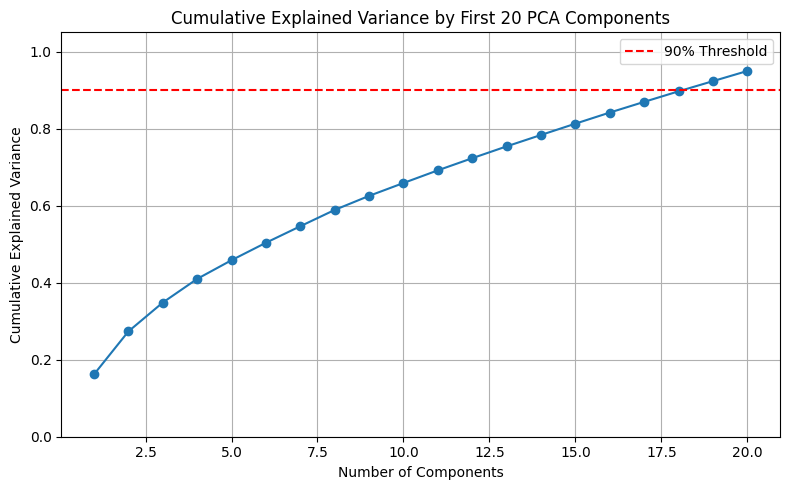

In [47]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Store results
results = []

# Loop through 1 to 20 components
for n_components in range(1, 21):
    pca = PCA(n_components=n_components, random_state=1)
    X_pca = pca.fit_transform(X_scaled)

    regressor = LinearRegression()
    y_pred = cross_val_predict(regressor, X_pca, y, cv=X.shape[0])  # LOOCV

    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    pearson_corr, _ = pearsonr(y, y_pred)

    results.append({
        'n_components': n_components,
        'mae': mae,
        'r2': r2,
        'pearson': pearson_corr,
        'y_pred': y_pred,
        'pca_model': pca
    })

    print(f"Components: {n_components:2d} | MAE: {mae:.2f} | R²: {r2:.3f} | Pearson: {pearson_corr:.3f}")

# Find the best result (lowest MAE)
best_result = min(results, key=lambda x: x['mae'])

# Unpack best model metrics
n_best = best_result['n_components']
y_pred_best = best_result['y_pred']
r2_best = best_result['r2']
pearson_best = best_result['pearson']
mae_best = best_result['mae']

# Plot predictions for the best model
plt.figure(figsize=(10, 7))
plt.scatter(y, y_pred_best, alpha=0.7, color='b')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title(f'PCR with {n_best} PCA Components (LOOCV)\nR² = {r2_best:.2f}, Pearson = {pearson_best:.2f}')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.2 * (y.max() - y.min()), f'MAE = {mae_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.1 * (y.max() - y.min()), f'R² = {r2_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.15 * (y.max() - y.min()), f'Pearson = {pearson_best:.2f}', fontsize=12, color='blue')
plt.grid(True)
plt.show()

# --- NEW: Explained variance using PCA with 20 components ---
pca_full = PCA(n_components=20, random_state=1)
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = explained_var.cumsum()

print("\nExplained Variance by Each of the First 20 Components:")
for i, (ev, cum_ev) in enumerate(zip(explained_var, cumulative_var), start=1):
    print(f"Component {i:2d}: {ev:.4f} (Cumulative: {cum_ev:.4f})")

# Optional: Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, 21), cumulative_var, marker='o', linestyle='-')
plt.title('Cumulative Explained Variance by First 20 PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.ylim(0, 1.05)
plt.grid(True)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Threshold')
plt.legend()
plt.tight_layout()
plt.show()

# Spleen

In [48]:
spleen_df = combined_df.loc[combined_df.iloc[:,-2] == "Spleen"]

spleen_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A17_2,500.972933,610.959908,255.453620,361.183035,1160.894784,772.037607,1334.035571,796.873376,806.807683,725.204443,...,172.431194,1597.294718,83.022427,485.361878,1625.678454,108.567789,412.273759,F,Spleen,78
A18_2,127.857810,563.956610,89.154905,447.847896,407.071622,689.741050,2365.715045,958.588013,563.956610,796.865161,...,174.854194,1036.684945,17.278082,632.377817,4201.338522,395.322526,494.153157,M,Spleen,152
A19_2,13.175394,714.765109,185.553462,409.535155,658.769686,637.908646,1812.714586,883.849329,396.359761,586.305020,...,223.981693,1208.842374,45.015929,540.191142,3514.536274,254.724279,603.872212,F,Spleen,155
A20_2,263.871273,759.985412,123.802618,364.178503,591.903026,819.627549,1278.691271,659.678182,647.930488,984.095261,...,136.453980,1659.135811,187.963098,445.508690,2697.451196,178.022742,395.806909,M,Spleen,47
B17_2,116.199639,712.597787,111.299654,216.299328,492.798469,678.997891,1679.294784,643.298002,613.198096,769.997609,...,265.999174,1023.396821,80.499750,521.498380,10473.367471,505.398430,413.698715,M,Spleen,102


In [49]:
spleen_df_male = spleen_df.loc[spleen_df.iloc[:,-3] == "M"]

spleen_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A18_2,127.857810,563.956610,89.154905,447.847896,407.071622,689.741050,2365.715045,958.588013,563.956610,796.865161,...,174.854194,1036.684945,17.278082,632.377817,4201.338522,395.322526,494.153157,M,Spleen,152
A20_2,263.871273,759.985412,123.802618,364.178503,591.903026,819.627549,1278.691271,659.678182,647.930488,984.095261,...,136.453980,1659.135811,187.963098,445.508690,2697.451196,178.022742,395.806909,M,Spleen,47
B17_2,116.199639,712.597787,111.299654,216.299328,492.798469,678.997891,1679.294784,643.298002,613.198096,769.997609,...,265.999174,1023.396821,80.499750,521.498380,10473.367471,505.398430,413.698715,M,Spleen,102
B19_2,61.384651,568.164909,193.195103,390.672856,743.277712,683.796461,1412.798672,992.623116,659.528110,827.503163,...,165.595803,1333.807571,66.619001,568.164909,2992.144847,212.704953,549.130909,M,Spleen,78
B20_2,0.787620,631.671479,191.391732,389.872047,827.001312,581.263779,1487.814742,858.506124,671.052493,867.957568,...,207.144138,1233.413386,32.292432,562.360892,3421.422572,289.844269,515.891295,M,Spleen,161


In [50]:
spleen_sub_df_male = spleen_df_male.iloc[:,:-3]
spleen_sub_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A18_2,127.857810,563.956610,89.154905,447.847896,407.071622,689.741050,2365.715045,958.588013,563.956610,796.865161,...,955.132396,143.062522,1398.833553,174.854194,1036.684945,17.278082,632.377817,4201.338522,395.322526,494.153157
A20_2,263.871273,759.985412,123.802618,364.178503,591.903026,819.627549,1278.691271,659.678182,647.930488,984.095261,...,611.783739,99.403562,1347.370095,136.453980,1659.135811,187.963098,445.508690,2697.451196,178.022742,395.806909
B17_2,116.199639,712.597787,111.299654,216.299328,492.798469,678.997891,1679.294784,643.298002,613.198096,769.997609,...,1406.295632,88.899724,1574.995108,265.999174,1023.396821,80.499750,521.498380,10473.367471,505.398430,413.698715
B19_2,61.384651,568.164909,193.195103,390.672856,743.277712,683.796461,1412.798672,992.623116,659.528110,827.503163,...,761.360012,116.583252,1200.093719,165.595803,1333.807571,66.619001,568.164909,2992.144847,212.704953,549.130909
B20_2,0.787620,631.671479,191.391732,389.872047,827.001312,581.263779,1487.814742,858.506124,671.052493,867.957568,...,887.648075,68.522966,1338.954506,207.144138,1233.413386,32.292432,562.360892,3421.422572,289.844269,515.891295


In [51]:
spleen_sub_df_male["age"] = spleen_df_male["age_days"].tolist()

spleen_sub_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A18_2,127.857810,563.956610,89.154905,447.847896,407.071622,689.741050,2365.715045,958.588013,563.956610,796.865161,...,143.062522,1398.833553,174.854194,1036.684945,17.278082,632.377817,4201.338522,395.322526,494.153157,152
A20_2,263.871273,759.985412,123.802618,364.178503,591.903026,819.627549,1278.691271,659.678182,647.930488,984.095261,...,99.403562,1347.370095,136.453980,1659.135811,187.963098,445.508690,2697.451196,178.022742,395.806909,47
B17_2,116.199639,712.597787,111.299654,216.299328,492.798469,678.997891,1679.294784,643.298002,613.198096,769.997609,...,88.899724,1574.995108,265.999174,1023.396821,80.499750,521.498380,10473.367471,505.398430,413.698715,102
B19_2,61.384651,568.164909,193.195103,390.672856,743.277712,683.796461,1412.798672,992.623116,659.528110,827.503163,...,116.583252,1200.093719,165.595803,1333.807571,66.619001,568.164909,2992.144847,212.704953,549.130909,78
B20_2,0.787620,631.671479,191.391732,389.872047,827.001312,581.263779,1487.814742,858.506124,671.052493,867.957568,...,68.522966,1338.954506,207.144138,1233.413386,32.292432,562.360892,3421.422572,289.844269,515.891295,161


In [52]:
spleen_data_male = spleen_sub_df_male.values

In [53]:
X, y = spleen_data_male[:,:-1], spleen_data_male[:,-1]

Components:  1 | MAE: 39.60 | R²: -0.135 | Pearson: -0.595
Components:  2 | MAE: 37.15 | R²: -0.188 | Pearson: 0.261
Components:  3 | MAE: 39.07 | R²: -0.471 | Pearson: 0.291
Components:  4 | MAE: 32.93 | R²: -0.095 | Pearson: 0.455
Components:  5 | MAE: 28.32 | R²: 0.026 | Pearson: 0.520
Components:  6 | MAE: 29.14 | R²: 0.023 | Pearson: 0.526
Components:  7 | MAE: 23.32 | R²: 0.379 | Pearson: 0.691
Components:  8 | MAE: 24.48 | R²: 0.221 | Pearson: 0.635
Components:  9 | MAE: 23.77 | R²: 0.264 | Pearson: 0.652
Components: 10 | MAE: 26.37 | R²: 0.127 | Pearson: 0.598
Components: 11 | MAE: 27.46 | R²: 0.042 | Pearson: 0.589
Components: 12 | MAE: 29.27 | R²: -0.073 | Pearson: 0.580
Components: 13 | MAE: 30.31 | R²: -0.129 | Pearson: 0.577
Components: 14 | MAE: 32.50 | R²: -0.216 | Pearson: 0.558
Components: 15 | MAE: 32.31 | R²: -0.182 | Pearson: 0.569
Components: 16 | MAE: 31.95 | R²: -0.092 | Pearson: 0.611
Components: 17 | MAE: 35.70 | R²: -1.372 | Pearson: 0.410
Components: 18 | MAE

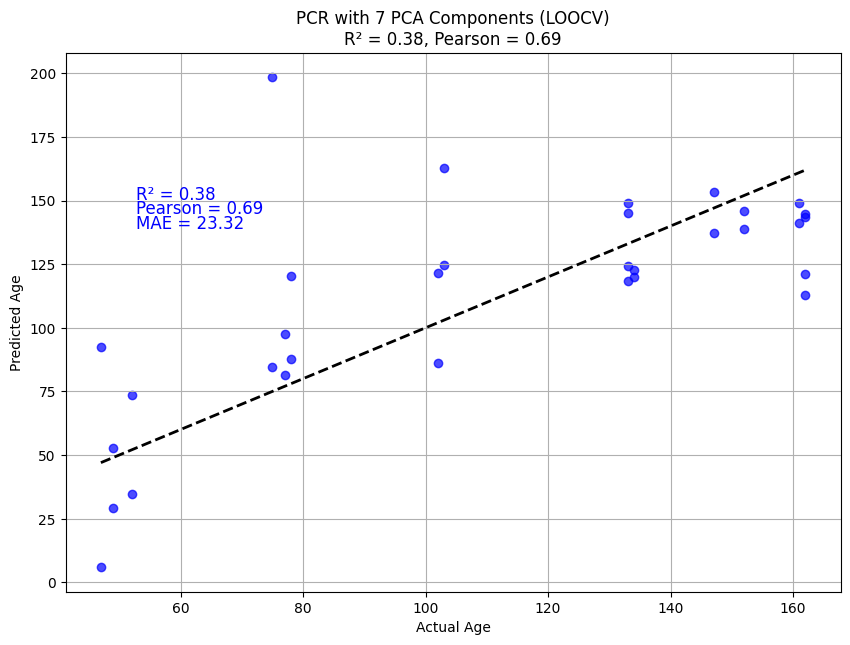


Explained Variance by Each of the First 20 Components:
Component  1: 0.2422 (Cumulative: 0.2422)
Component  2: 0.0887 (Cumulative: 0.3309)
Component  3: 0.0791 (Cumulative: 0.4100)
Component  4: 0.0708 (Cumulative: 0.4808)
Component  5: 0.0480 (Cumulative: 0.5288)
Component  6: 0.0398 (Cumulative: 0.5686)
Component  7: 0.0377 (Cumulative: 0.6063)
Component  8: 0.0299 (Cumulative: 0.6362)
Component  9: 0.0270 (Cumulative: 0.6632)
Component 10: 0.0245 (Cumulative: 0.6877)
Component 11: 0.0233 (Cumulative: 0.7110)
Component 12: 0.0205 (Cumulative: 0.7315)
Component 13: 0.0198 (Cumulative: 0.7513)
Component 14: 0.0189 (Cumulative: 0.7701)
Component 15: 0.0185 (Cumulative: 0.7886)
Component 16: 0.0175 (Cumulative: 0.8060)
Component 17: 0.0166 (Cumulative: 0.8226)
Component 18: 0.0159 (Cumulative: 0.8385)
Component 19: 0.0158 (Cumulative: 0.8543)
Component 20: 0.0146 (Cumulative: 0.8688)


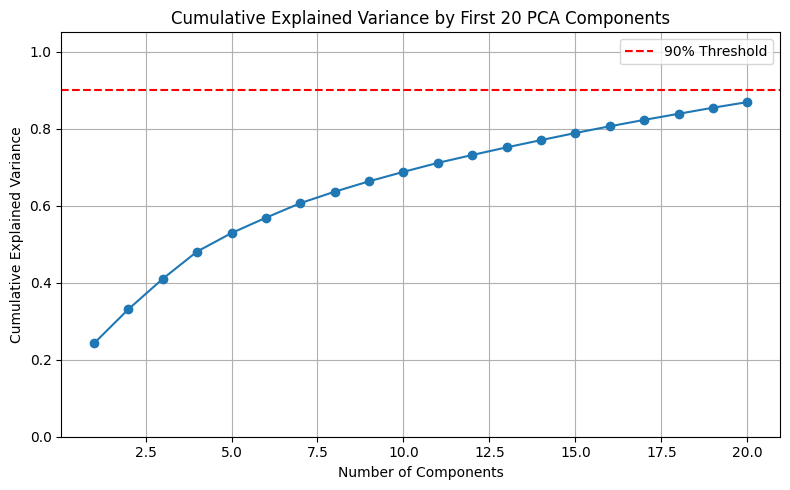

In [54]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Store results
results = []

# Loop through 1 to 20 components
for n_components in range(1, 21):
    pca = PCA(n_components=n_components, random_state=1)
    X_pca = pca.fit_transform(X_scaled)

    regressor = LinearRegression()
    y_pred = cross_val_predict(regressor, X_pca, y, cv=X.shape[0])  # LOOCV

    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    pearson_corr, _ = pearsonr(y, y_pred)

    results.append({
        'n_components': n_components,
        'mae': mae,
        'r2': r2,
        'pearson': pearson_corr,
        'y_pred': y_pred,
        'pca_model': pca
    })

    print(f"Components: {n_components:2d} | MAE: {mae:.2f} | R²: {r2:.3f} | Pearson: {pearson_corr:.3f}")

# Find the best result (lowest MAE)
best_result = min(results, key=lambda x: x['mae'])

# Unpack best model metrics
n_best = best_result['n_components']
y_pred_best = best_result['y_pred']
r2_best = best_result['r2']
pearson_best = best_result['pearson']
mae_best = best_result['mae']

# Plot predictions for the best model
plt.figure(figsize=(10, 7))
plt.scatter(y, y_pred_best, alpha=0.7, color='b')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title(f'PCR with {n_best} PCA Components (LOOCV)\nR² = {r2_best:.2f}, Pearson = {pearson_best:.2f}')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.2 * (y.max() - y.min()), f'MAE = {mae_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.1 * (y.max() - y.min()), f'R² = {r2_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.15 * (y.max() - y.min()), f'Pearson = {pearson_best:.2f}', fontsize=12, color='blue')
plt.grid(True)
plt.show()

# --- NEW: Explained variance using PCA with 20 components ---
pca_full = PCA(n_components=20, random_state=1)
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = explained_var.cumsum()

print("\nExplained Variance by Each of the First 20 Components:")
for i, (ev, cum_ev) in enumerate(zip(explained_var, cumulative_var), start=1):
    print(f"Component {i:2d}: {ev:.4f} (Cumulative: {cum_ev:.4f})")

# Optional: Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, 21), cumulative_var, marker='o', linestyle='-')
plt.title('Cumulative Explained Variance by First 20 PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.ylim(0, 1.05)
plt.grid(True)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Threshold')
plt.legend()
plt.tight_layout()
plt.show()

#### Female

In [55]:
spleen_df_female = spleen_df.loc[spleen_df.iloc[:,-3] == "F"]

spleen_df_female.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A17_2,500.972933,610.959908,255.453620,361.183035,1160.894784,772.037607,1334.035571,796.873376,806.807683,725.204443,...,172.431194,1597.294718,83.022427,485.361878,1625.678454,108.567789,412.273759,F,Spleen,78
A19_2,13.175394,714.765109,185.553462,409.535155,658.769686,637.908646,1812.714586,883.849329,396.359761,586.305020,...,223.981693,1208.842374,45.015929,540.191142,3514.536274,254.724279,603.872212,F,Spleen,155
B18_2,30.277472,820.712755,248.661792,376.213696,1014.617417,733.745548,1430.771609,709.910091,776.262850,963.725496,...,188.106848,1454.607066,75.371580,700.891270,3133.396266,237.066165,581.713986,F,Spleen,75
C18_2,4.621708,538.098877,171.663445,386.902996,921.700653,592.238886,1420.184888,1066.954337,457.549106,682.692317,...,198.073206,1071.576045,34.332689,839.830394,2272.559919,197.412962,644.398164,F,Spleen,75
C19_2,19.181350,903.542557,150.926941,559.792568,522.944184,732.424721,1566.308690,561.811657,773.816056,1001.468399,...,186.765780,1288.683882,111.049923,606.736399,3812.545774,393.722455,490.133979,F,Spleen,155


In [56]:
spleen_sub_df_female = spleen_df_female.iloc[:,:-3]

spleen_sub_df_female.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A17_2,500.972933,610.959908,255.453620,361.183035,1160.894784,772.037607,1334.035571,796.873376,806.807683,725.204443,...,503.101713,137.661117,1245.336398,172.431194,1597.294718,83.022427,485.361878,1625.678454,108.567789,412.273759
A19_2,13.175394,714.765109,185.553462,409.535155,658.769686,637.908646,1812.714586,883.849329,396.359761,586.305020,...,1167.120293,96.619554,1352.673755,223.981693,1208.842374,45.015929,540.191142,3514.536274,254.724279,603.872212
B18_2,30.277472,820.712755,248.661792,376.213696,1014.617417,733.745548,1430.771609,709.910091,776.262850,963.725496,...,803.963516,100.495439,1523.536630,188.106848,1454.607066,75.371580,700.891270,3133.396266,237.066165,581.713986
C18_2,4.621708,538.098877,171.663445,386.902996,921.700653,592.238886,1420.184888,1066.954337,457.549106,682.692317,...,1180.516309,69.325622,1193.721189,198.073206,1071.576045,34.332689,839.830394,2272.559919,197.412962,644.398164
C19_2,19.181350,903.542557,150.926941,559.792568,522.944184,732.424721,1566.308690,561.811657,773.816056,1001.468399,...,727.881770,101.459248,1445.668092,186.765780,1288.683882,111.049923,606.736399,3812.545774,393.722455,490.133979


In [57]:
spleen_sub_df_female["age"] = spleen_df_female["age_days"].tolist()

spleen_sub_df_female.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A17_2,500.972933,610.959908,255.453620,361.183035,1160.894784,772.037607,1334.035571,796.873376,806.807683,725.204443,...,137.661117,1245.336398,172.431194,1597.294718,83.022427,485.361878,1625.678454,108.567789,412.273759,78
A19_2,13.175394,714.765109,185.553462,409.535155,658.769686,637.908646,1812.714586,883.849329,396.359761,586.305020,...,96.619554,1352.673755,223.981693,1208.842374,45.015929,540.191142,3514.536274,254.724279,603.872212,155
B18_2,30.277472,820.712755,248.661792,376.213696,1014.617417,733.745548,1430.771609,709.910091,776.262850,963.725496,...,100.495439,1523.536630,188.106848,1454.607066,75.371580,700.891270,3133.396266,237.066165,581.713986,75
C18_2,4.621708,538.098877,171.663445,386.902996,921.700653,592.238886,1420.184888,1066.954337,457.549106,682.692317,...,69.325622,1193.721189,198.073206,1071.576045,34.332689,839.830394,2272.559919,197.412962,644.398164,75
C19_2,19.181350,903.542557,150.926941,559.792568,522.944184,732.424721,1566.308690,561.811657,773.816056,1001.468399,...,101.459248,1445.668092,186.765780,1288.683882,111.049923,606.736399,3812.545774,393.722455,490.133979,155


In [58]:
spleen_data_female = spleen_sub_df_female.values

In [59]:
X, y = spleen_data_female[:,:-1], spleen_data_female[:,-1]

Components:  1 | MAE: 33.47 | R²: -0.039 | Pearson: 0.116
Components:  2 | MAE: 36.66 | R²: -0.334 | Pearson: -0.089
Components:  3 | MAE: 33.23 | R²: -0.102 | Pearson: 0.280
Components:  4 | MAE: 31.80 | R²: -0.014 | Pearson: 0.386
Components:  5 | MAE: 34.19 | R²: -0.042 | Pearson: 0.377
Components:  6 | MAE: 22.76 | R²: 0.395 | Pearson: 0.650
Components:  7 | MAE: 25.23 | R²: 0.278 | Pearson: 0.584
Components:  8 | MAE: 24.51 | R²: 0.344 | Pearson: 0.641
Components:  9 | MAE: 22.55 | R²: 0.465 | Pearson: 0.728
Components: 10 | MAE: 29.62 | R²: -0.012 | Pearson: 0.631
Components: 11 | MAE: 34.18 | R²: -0.562 | Pearson: 0.558
Components: 12 | MAE: 29.36 | R²: -0.107 | Pearson: 0.713
Components: 13 | MAE: 37.47 | R²: -0.982 | Pearson: 0.652
Components: 14 | MAE: 48.50 | R²: -2.118 | Pearson: 0.549
Components: 15 | MAE: 51.61 | R²: -2.203 | Pearson: 0.531
Components: 16 | MAE: 62.38 | R²: -3.728 | Pearson: 0.547
Components: 17 | MAE: 68.07 | R²: -6.591 | Pearson: 0.426
Components: 18 | 

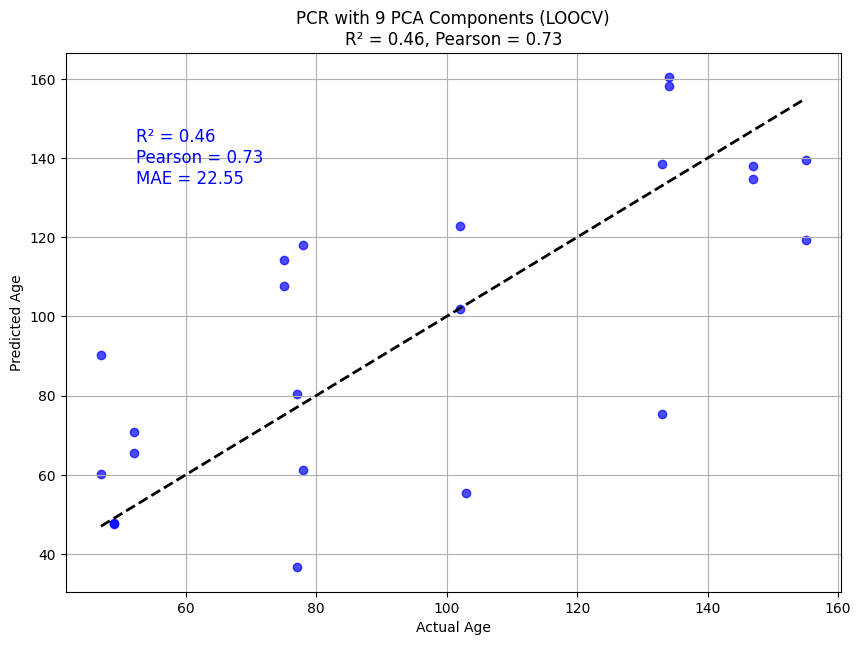


Explained Variance by Each of the First 20 Components:
Component  1: 0.1622 (Cumulative: 0.1622)
Component  2: 0.1356 (Cumulative: 0.2978)
Component  3: 0.1172 (Cumulative: 0.4149)
Component  4: 0.0797 (Cumulative: 0.4946)
Component  5: 0.0582 (Cumulative: 0.5528)
Component  6: 0.0480 (Cumulative: 0.6009)
Component  7: 0.0409 (Cumulative: 0.6417)
Component  8: 0.0338 (Cumulative: 0.6755)
Component  9: 0.0316 (Cumulative: 0.7070)
Component 10: 0.0305 (Cumulative: 0.7376)
Component 11: 0.0279 (Cumulative: 0.7655)
Component 12: 0.0277 (Cumulative: 0.7932)
Component 13: 0.0248 (Cumulative: 0.8180)
Component 14: 0.0235 (Cumulative: 0.8415)
Component 15: 0.0231 (Cumulative: 0.8647)
Component 16: 0.0222 (Cumulative: 0.8869)
Component 17: 0.0215 (Cumulative: 0.9084)
Component 18: 0.0206 (Cumulative: 0.9290)
Component 19: 0.0193 (Cumulative: 0.9483)
Component 20: 0.0181 (Cumulative: 0.9664)


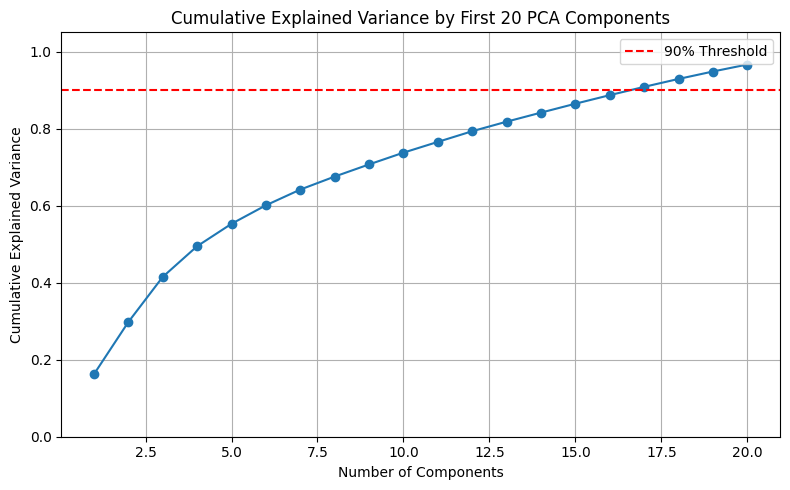

In [60]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Store results
results = []

# Loop through 1 to 20 components
for n_components in range(1, 21):
    pca = PCA(n_components=n_components, random_state=1)
    X_pca = pca.fit_transform(X_scaled)

    regressor = LinearRegression()
    y_pred = cross_val_predict(regressor, X_pca, y, cv=X.shape[0])  # LOOCV

    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    pearson_corr, _ = pearsonr(y, y_pred)

    results.append({
        'n_components': n_components,
        'mae': mae,
        'r2': r2,
        'pearson': pearson_corr,
        'y_pred': y_pred,
        'pca_model': pca
    })

    print(f"Components: {n_components:2d} | MAE: {mae:.2f} | R²: {r2:.3f} | Pearson: {pearson_corr:.3f}")

# Find the best result (lowest MAE)
best_result = min(results, key=lambda x: x['mae'])

# Unpack best model metrics
n_best = best_result['n_components']
y_pred_best = best_result['y_pred']
r2_best = best_result['r2']
pearson_best = best_result['pearson']
mae_best = best_result['mae']

# Plot predictions for the best model
plt.figure(figsize=(10, 7))
plt.scatter(y, y_pred_best, alpha=0.7, color='b')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title(f'PCR with {n_best} PCA Components (LOOCV)\nR² = {r2_best:.2f}, Pearson = {pearson_best:.2f}')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.2 * (y.max() - y.min()), f'MAE = {mae_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.1 * (y.max() - y.min()), f'R² = {r2_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.15 * (y.max() - y.min()), f'Pearson = {pearson_best:.2f}', fontsize=12, color='blue')
plt.grid(True)
plt.show()

# --- NEW: Explained variance using PCA with 20 components ---
pca_full = PCA(n_components=20, random_state=1)
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = explained_var.cumsum()

print("\nExplained Variance by Each of the First 20 Components:")
for i, (ev, cum_ev) in enumerate(zip(explained_var, cumulative_var), start=1):
    print(f"Component {i:2d}: {ev:.4f} (Cumulative: {cum_ev:.4f})")

# Optional: Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, 21), cumulative_var, marker='o', linestyle='-')
plt.title('Cumulative Explained Variance by First 20 PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.ylim(0, 1.05)
plt.grid(True)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Threshold')
plt.legend()
plt.tight_layout()
plt.show()

# Spinal Cord

In [61]:
spinal_df = combined_df.loc[combined_df.iloc[:,-2] == "SpinalCord"]

spinal_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A10_2,4.382338,451.380822,1198.256441,303.633424,289.860362,445.120339,1093.080327,468.284126,709.312721,492.073962,...,174.667475,1304.058604,28.172173,1264.617561,1144.416288,157.764171,238.524401,M,SpinalCord,75
A11_2,8.609836,486.229181,1020.945335,358.441083,187.603803,594.985009,1253.410917,559.639365,897.235581,560.545663,...,111.474724,1103.871654,52.565317,1282.865621,983.787094,216.605357,251.951001,F,SpinalCord,52
A12_2,6.381242,390.531984,1030.570512,342.672672,241.849055,465.830634,1290.287044,752.986504,714.699055,485.612483,...,134.644197,1193.930296,27.439339,1560.851686,1036.951754,135.282321,209.304723,M,SpinalCord,161
A9_2,9.612729,374.060560,1091.253769,354.835101,266.648757,382.837400,1291.449309,572.166377,649.904102,442.603501,...,180.552136,1248.818943,31.345857,1222.906368,1031.069723,128.309041,268.320536,M,SpinalCord,162
B10_2,12.443541,383.261073,1129.873553,309.429394,199.096661,482.809404,1082.588096,816.296311,808.830187,433.864808,...,176.698287,1089.224651,42.308041,1119.089150,905.060240,150.152065,199.926231,M,SpinalCord,103


In [62]:
spinal_df_male = spinal_df.loc[spinal_df.iloc[:,-3] == "M"]

spinal_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A10_2,4.382338,451.380822,1198.256441,303.633424,289.860362,445.120339,1093.080327,468.284126,709.312721,492.073962,...,174.667475,1304.058604,28.172173,1264.617561,1144.416288,157.764171,238.524401,M,SpinalCord,75
A12_2,6.381242,390.531984,1030.570512,342.672672,241.849055,465.830634,1290.287044,752.986504,714.699055,485.612483,...,134.644197,1193.930296,27.439339,1560.851686,1036.951754,135.282321,209.304723,M,SpinalCord,161
A9_2,9.612729,374.060560,1091.253769,354.835101,266.648757,382.837400,1291.449309,572.166377,649.904102,442.603501,...,180.552136,1248.818943,31.345857,1222.906368,1031.069723,128.309041,268.320536,M,SpinalCord,162
B10_2,12.443541,383.261073,1129.873553,309.429394,199.096661,482.809404,1082.588096,816.296311,808.830187,433.864808,...,176.698287,1089.224651,42.308041,1119.089150,905.060240,150.152065,199.926231,M,SpinalCord,103
B11_2,15.469734,515.451538,1179.412523,272.886108,267.317004,493.175121,1227.059304,534.015219,900.338521,549.484953,...,102.100245,1209.733201,59.403779,1386.088169,1094.019591,127.470608,202.344121,M,SpinalCord,52


In [63]:
spinal_sub_df_male = spinal_df_male.iloc[:,:-3]
spinal_sub_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A10_2,4.382338,451.380822,1198.256441,303.633424,289.860362,445.120339,1093.080327,468.284126,709.312721,492.073962,...,1201.386683,131.470142,800.089724,174.667475,1304.058604,28.172173,1264.617561,1144.416288,157.764171,238.524401
A12_2,6.381242,390.531984,1030.570512,342.672672,241.849055,465.830634,1290.287044,752.986504,714.699055,485.612483,...,1118.631646,170.379150,608.132321,134.644197,1193.930296,27.439339,1560.851686,1036.951754,135.282321,209.304723
A9_2,9.612729,374.060560,1091.253769,354.835101,266.648757,382.837400,1291.449309,572.166377,649.904102,442.603501,...,916.134914,104.068245,540.820520,180.552136,1248.818943,31.345857,1222.906368,1031.069723,128.309041,268.320536
B10_2,12.443541,383.261073,1129.873553,309.429394,199.096661,482.809404,1082.588096,816.296311,808.830187,433.864808,...,1066.826277,227.302022,645.405010,176.698287,1089.224651,42.308041,1119.089150,905.060240,150.152065,199.926231
B11_2,15.469734,515.451538,1179.412523,272.886108,267.317004,493.175121,1227.059304,534.015219,900.338521,549.484953,...,1348.960808,157.791287,843.409900,102.100245,1209.733201,59.403779,1386.088169,1094.019591,127.470608,202.344121


In [64]:
spinal_sub_df_male["age"] = spinal_df_male["age_days"].tolist()

spinal_sub_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A10_2,4.382338,451.380822,1198.256441,303.633424,289.860362,445.120339,1093.080327,468.284126,709.312721,492.073962,...,131.470142,800.089724,174.667475,1304.058604,28.172173,1264.617561,1144.416288,157.764171,238.524401,75
A12_2,6.381242,390.531984,1030.570512,342.672672,241.849055,465.830634,1290.287044,752.986504,714.699055,485.612483,...,170.379150,608.132321,134.644197,1193.930296,27.439339,1560.851686,1036.951754,135.282321,209.304723,161
A9_2,9.612729,374.060560,1091.253769,354.835101,266.648757,382.837400,1291.449309,572.166377,649.904102,442.603501,...,104.068245,540.820520,180.552136,1248.818943,31.345857,1222.906368,1031.069723,128.309041,268.320536,162
B10_2,12.443541,383.261073,1129.873553,309.429394,199.096661,482.809404,1082.588096,816.296311,808.830187,433.864808,...,227.302022,645.405010,176.698287,1089.224651,42.308041,1119.089150,905.060240,150.152065,199.926231,103
B11_2,15.469734,515.451538,1179.412523,272.886108,267.317004,493.175121,1227.059304,534.015219,900.338521,549.484953,...,157.791287,843.409900,102.100245,1209.733201,59.403779,1386.088169,1094.019591,127.470608,202.344121,52


In [65]:
spinal_data_male = spinal_sub_df_male.values

In [66]:
X, y = spinal_data_male[:,:-1], spinal_data_male[:,-1]

Components:  1 | MAE: 37.27 | R²: -0.050 | Pearson: -0.021


Components:  2 | MAE: 32.87 | R²: 0.100 | Pearson: 0.377
Components:  3 | MAE: 24.15 | R²: 0.408 | Pearson: 0.650
Components:  4 | MAE: 22.44 | R²: 0.540 | Pearson: 0.752
Components:  5 | MAE: 21.17 | R²: 0.620 | Pearson: 0.793
Components:  6 | MAE: 22.55 | R²: 0.567 | Pearson: 0.769
Components:  7 | MAE: 21.46 | R²: 0.594 | Pearson: 0.782
Components:  8 | MAE: 22.58 | R²: 0.552 | Pearson: 0.759
Components:  9 | MAE: 23.60 | R²: 0.474 | Pearson: 0.717
Components: 10 | MAE: 27.60 | R²: 0.020 | Pearson: 0.652
Components: 11 | MAE: 24.45 | R²: 0.385 | Pearson: 0.711
Components: 12 | MAE: 25.56 | R²: 0.168 | Pearson: 0.705
Components: 13 | MAE: 32.44 | R²: -0.239 | Pearson: 0.575
Components: 14 | MAE: 33.57 | R²: -0.454 | Pearson: 0.548
Components: 15 | MAE: 20.66 | R²: 0.493 | Pearson: 0.823
Components: 16 | MAE: 17.86 | R²: 0.652 | Pearson: 0.860
Components: 17 | MAE: 23.27 | R²: 0.084 | Pearson: 0.748
Components: 18 | MAE: 27.74 | R²: -0.112 | Pearson: 0.759
Components: 19 | MAE: 31.03 

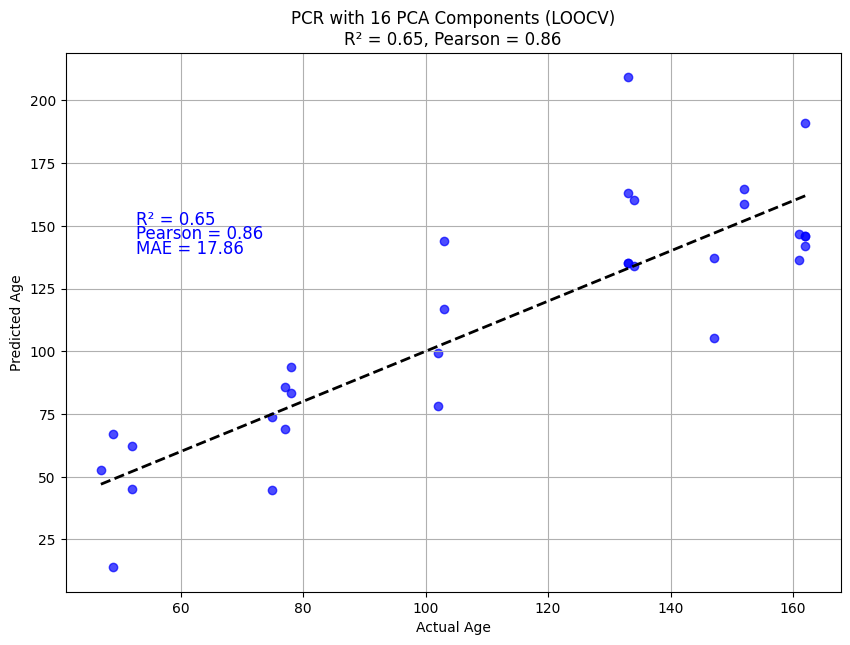


Explained Variance by Each of the First 20 Components:
Component  1: 0.1902 (Cumulative: 0.1902)
Component  2: 0.1481 (Cumulative: 0.3383)
Component  3: 0.0763 (Cumulative: 0.4146)
Component  4: 0.0543 (Cumulative: 0.4688)
Component  5: 0.0419 (Cumulative: 0.5108)
Component  6: 0.0385 (Cumulative: 0.5492)
Component  7: 0.0344 (Cumulative: 0.5836)
Component  8: 0.0288 (Cumulative: 0.6125)
Component  9: 0.0273 (Cumulative: 0.6397)
Component 10: 0.0249 (Cumulative: 0.6646)
Component 11: 0.0224 (Cumulative: 0.6870)
Component 12: 0.0222 (Cumulative: 0.7092)
Component 13: 0.0210 (Cumulative: 0.7301)
Component 14: 0.0201 (Cumulative: 0.7502)
Component 15: 0.0188 (Cumulative: 0.7690)
Component 16: 0.0183 (Cumulative: 0.7873)
Component 17: 0.0179 (Cumulative: 0.8052)
Component 18: 0.0174 (Cumulative: 0.8227)
Component 19: 0.0170 (Cumulative: 0.8396)
Component 20: 0.0165 (Cumulative: 0.8561)


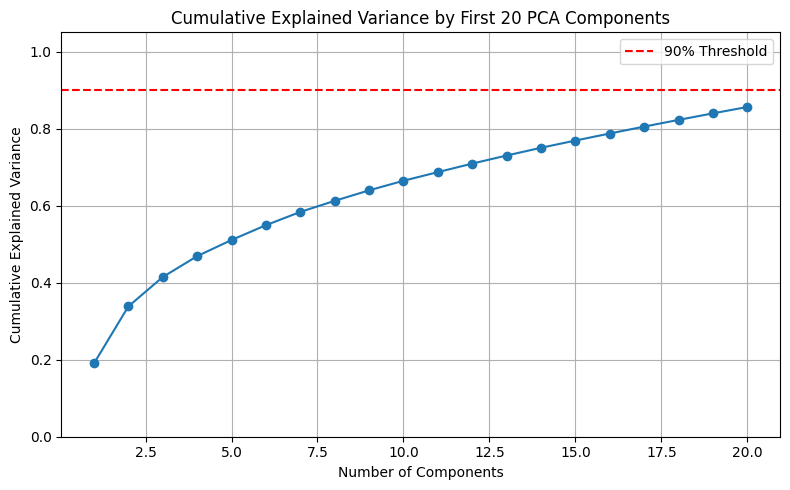

In [67]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Store results
results = []

# Loop through 1 to 20 components
for n_components in range(1, 21):
    pca = PCA(n_components=n_components, random_state=1)
    X_pca = pca.fit_transform(X_scaled)

    regressor = LinearRegression()
    y_pred = cross_val_predict(regressor, X_pca, y, cv=X.shape[0])  # LOOCV

    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    pearson_corr, _ = pearsonr(y, y_pred)

    results.append({
        'n_components': n_components,
        'mae': mae,
        'r2': r2,
        'pearson': pearson_corr,
        'y_pred': y_pred,
        'pca_model': pca
    })

    print(f"Components: {n_components:2d} | MAE: {mae:.2f} | R²: {r2:.3f} | Pearson: {pearson_corr:.3f}")

# Find the best result (lowest MAE)
best_result = min(results, key=lambda x: x['mae'])

# Unpack best model metrics
n_best = best_result['n_components']
y_pred_best = best_result['y_pred']
r2_best = best_result['r2']
pearson_best = best_result['pearson']
mae_best = best_result['mae']

# Plot predictions for the best model
plt.figure(figsize=(10, 7))
plt.scatter(y, y_pred_best, alpha=0.7, color='b')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title(f'PCR with {n_best} PCA Components (LOOCV)\nR² = {r2_best:.2f}, Pearson = {pearson_best:.2f}')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.2 * (y.max() - y.min()), f'MAE = {mae_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.1 * (y.max() - y.min()), f'R² = {r2_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.15 * (y.max() - y.min()), f'Pearson = {pearson_best:.2f}', fontsize=12, color='blue')
plt.grid(True)
plt.show()

# --- NEW: Explained variance using PCA with 20 components ---
pca_full = PCA(n_components=20, random_state=1)
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = explained_var.cumsum()

print("\nExplained Variance by Each of the First 20 Components:")
for i, (ev, cum_ev) in enumerate(zip(explained_var, cumulative_var), start=1):
    print(f"Component {i:2d}: {ev:.4f} (Cumulative: {cum_ev:.4f})")

# Optional: Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, 21), cumulative_var, marker='o', linestyle='-')
plt.title('Cumulative Explained Variance by First 20 PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.ylim(0, 1.05)
plt.grid(True)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Threshold')
plt.legend()
plt.tight_layout()
plt.show()

#### Female

In [68]:
spinal_df_female = spinal_df.loc[spinal_df.iloc[:,-3] == "F"]

spinal_df_female.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A11_2,8.609836,486.229181,1020.945335,358.441083,187.603803,594.985009,1253.410917,559.639365,897.235581,560.545663,...,111.474724,1103.871654,52.565317,1282.865621,983.787094,216.605357,251.951001,F,SpinalCord,52
B9_2,8.454052,532.605295,1076.265888,349.217391,254.271881,541.059347,1214.131972,913.687960,784.926240,453.917577,...,145.019512,1064.560278,35.767144,1388.415512,1244.696623,152.823253,260.774998,F,SpinalCord,155
C11_2,14.798287,459.525768,1077.938412,244.561171,246.118886,485.228057,1359.884730,775.741805,767.953233,475.881770,...,165.896591,1099.746414,31.154289,1306.143581,954.878969,116.828585,183.031450,F,SpinalCord,78
C9_2,11.350211,386.273295,1097.309068,279.727770,209.795828,559.089405,1229.117965,495.015635,742.889589,471.582943,...,139.863885,1168.705554,33.684496,1383.627283,1273.054264,153.410911,252.267583,F,SpinalCord,78
D10_2,51.208117,460.873057,958.853445,225.612575,244.166241,464.583790,1148.100835,992.250043,849.757890,413.375672,...,112.064141,1041.231721,21.522252,1283.913668,1266.844296,218.933256,280.531426,F,SpinalCord,147


In [69]:
spinal_sub_df_female = spinal_df_female.iloc[:,:-3]

spinal_sub_df_female.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A11_2,8.609836,486.229181,1020.945335,358.441083,187.603803,594.985009,1253.410917,559.639365,897.235581,560.545663,...,1109.762595,169.024683,675.192432,111.474724,1103.871654,52.565317,1282.865621,983.787094,216.605357,251.951001
B9_2,8.454052,532.605295,1076.265888,349.217391,254.271881,541.059347,1214.131972,913.687960,784.926240,453.917577,...,999.529106,206.799125,582.679297,145.019512,1064.560278,35.767144,1388.415512,1244.696623,152.823253,260.774998
C11_2,14.798287,459.525768,1077.938412,244.561171,246.118886,485.228057,1359.884730,775.741805,767.953233,475.881770,...,991.485259,295.965749,796.770950,165.896591,1099.746414,31.154289,1306.143581,954.878969,116.828585,183.031450
C9_2,11.350211,386.273295,1097.309068,279.727770,209.795828,559.089405,1229.117965,495.015635,742.889589,471.582943,...,1239.369768,155.607726,781.699986,139.863885,1168.705554,33.684496,1383.627283,1273.054264,153.410911,252.267583
D10_2,51.208117,460.873057,958.853445,225.612575,244.166241,464.583790,1148.100835,992.250043,849.757890,413.375672,...,872.764436,198.895297,575.905784,112.064141,1041.231721,21.522252,1283.913668,1266.844296,218.933256,280.531426


In [70]:
spinal_sub_df_female["age"] = spinal_df_female["age_days"].tolist()

spinal_sub_df_female.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A11_2,8.609836,486.229181,1020.945335,358.441083,187.603803,594.985009,1253.410917,559.639365,897.235581,560.545663,...,169.024683,675.192432,111.474724,1103.871654,52.565317,1282.865621,983.787094,216.605357,251.951001,52
B9_2,8.454052,532.605295,1076.265888,349.217391,254.271881,541.059347,1214.131972,913.687960,784.926240,453.917577,...,206.799125,582.679297,145.019512,1064.560278,35.767144,1388.415512,1244.696623,152.823253,260.774998,155
C11_2,14.798287,459.525768,1077.938412,244.561171,246.118886,485.228057,1359.884730,775.741805,767.953233,475.881770,...,295.965749,796.770950,165.896591,1099.746414,31.154289,1306.143581,954.878969,116.828585,183.031450,78
C9_2,11.350211,386.273295,1097.309068,279.727770,209.795828,559.089405,1229.117965,495.015635,742.889589,471.582943,...,155.607726,781.699986,139.863885,1168.705554,33.684496,1383.627283,1273.054264,153.410911,252.267583,78
D10_2,51.208117,460.873057,958.853445,225.612575,244.166241,464.583790,1148.100835,992.250043,849.757890,413.375672,...,198.895297,575.905784,112.064141,1041.231721,21.522252,1283.913668,1266.844296,218.933256,280.531426,147


In [71]:
spinal_data_female = spinal_sub_df_female.values

In [72]:
X, y = spinal_data_female[:,:-1], spinal_data_female[:,-1]

Components:  1 | MAE: 35.03 | R²: -0.055 | Pearson: 0.064
Components:  2 | MAE: 34.18 | R²: -0.078 | Pearson: 0.112
Components:  3 | MAE: 19.19 | R²: 0.640 | Pearson: 0.807
Components:  4 | MAE: 20.67 | R²: 0.545 | Pearson: 0.767
Components:  5 | MAE: 20.91 | R²: 0.638 | Pearson: 0.812
Components:  6 | MAE: 22.22 | R²: 0.556 | Pearson: 0.770
Components:  7 | MAE: 30.58 | R²: -0.961 | Pearson: 0.546
Components:  8 | MAE: 28.69 | R²: -0.356 | Pearson: 0.618
Components:  9 | MAE: 34.72 | R²: -1.248 | Pearson: 0.531
Components: 10 | MAE: 35.90 | R²: -1.169 | Pearson: 0.533
Components: 11 | MAE: 44.47 | R²: -1.688 | Pearson: 0.487
Components: 12 | MAE: 20.82 | R²: 0.433 | Pearson: 0.781
Components: 13 | MAE: 22.96 | R²: 0.255 | Pearson: 0.728
Components: 14 | MAE: 29.53 | R²: -0.041 | Pearson: 0.715
Components: 15 | MAE: 28.32 | R²: -0.043 | Pearson: 0.650
Components: 16 | MAE: 37.29 | R²: -0.778 | Pearson: 0.556
Components: 17 | MAE: 52.81 | R²: -2.326 | Pearson: 0.511
Components: 18 | MAE

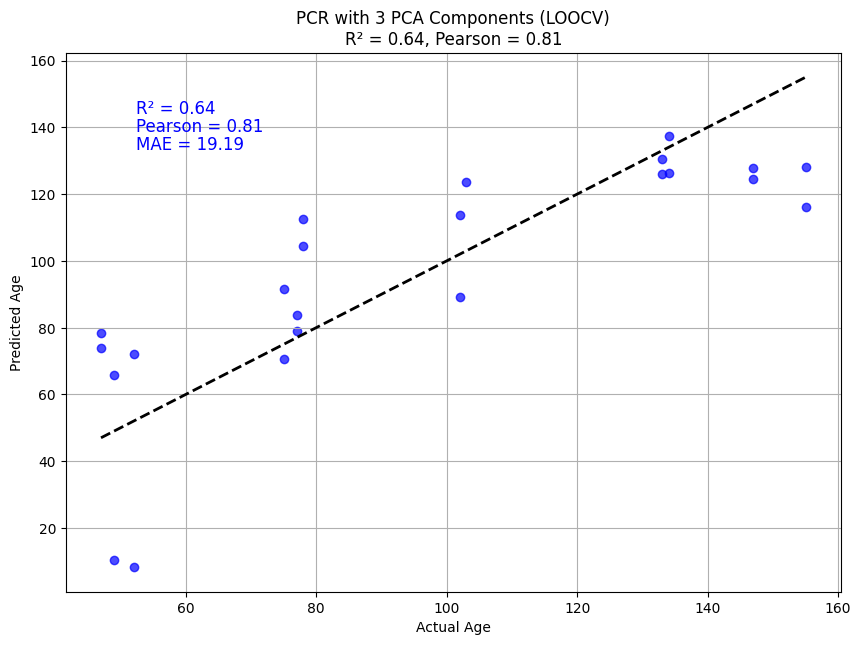


Explained Variance by Each of the First 20 Components:
Component  1: 0.2026 (Cumulative: 0.2026)
Component  2: 0.1976 (Cumulative: 0.4001)
Component  3: 0.0811 (Cumulative: 0.4813)
Component  4: 0.0511 (Cumulative: 0.5323)
Component  5: 0.0435 (Cumulative: 0.5758)
Component  6: 0.0387 (Cumulative: 0.6145)
Component  7: 0.0348 (Cumulative: 0.6492)
Component  8: 0.0316 (Cumulative: 0.6808)
Component  9: 0.0303 (Cumulative: 0.7111)
Component 10: 0.0294 (Cumulative: 0.7405)
Component 11: 0.0265 (Cumulative: 0.7671)
Component 12: 0.0259 (Cumulative: 0.7930)
Component 13: 0.0249 (Cumulative: 0.8179)
Component 14: 0.0241 (Cumulative: 0.8421)
Component 15: 0.0237 (Cumulative: 0.8658)
Component 16: 0.0225 (Cumulative: 0.8882)
Component 17: 0.0213 (Cumulative: 0.9096)
Component 18: 0.0193 (Cumulative: 0.9289)
Component 19: 0.0190 (Cumulative: 0.9479)
Component 20: 0.0181 (Cumulative: 0.9660)


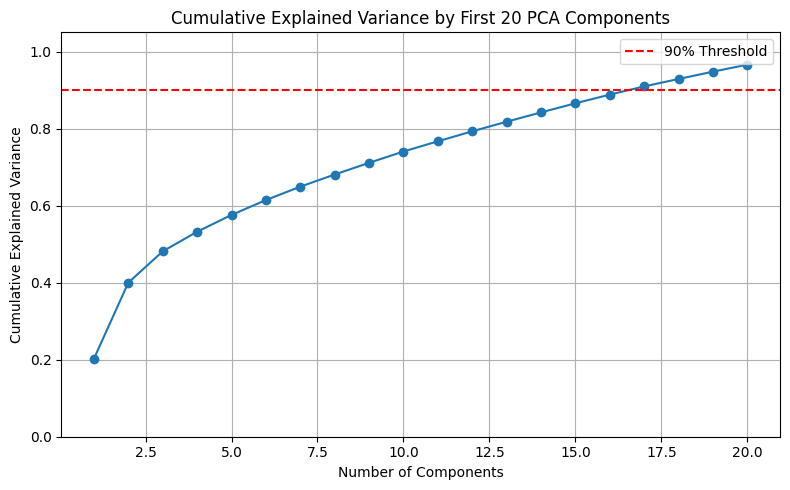

In [73]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Store results
results = []

# Loop through 1 to 20 components
for n_components in range(1, 21):
    pca = PCA(n_components=n_components, random_state=1)
    X_pca = pca.fit_transform(X_scaled)

    regressor = LinearRegression()
    y_pred = cross_val_predict(regressor, X_pca, y, cv=X.shape[0])  # LOOCV

    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    pearson_corr, _ = pearsonr(y, y_pred)

    results.append({
        'n_components': n_components,
        'mae': mae,
        'r2': r2,
        'pearson': pearson_corr,
        'y_pred': y_pred,
        'pca_model': pca
    })

    print(f"Components: {n_components:2d} | MAE: {mae:.2f} | R²: {r2:.3f} | Pearson: {pearson_corr:.3f}")

# Find the best result (lowest MAE)
best_result = min(results, key=lambda x: x['mae'])

# Unpack best model metrics
n_best = best_result['n_components']
y_pred_best = best_result['y_pred']
r2_best = best_result['r2']
pearson_best = best_result['pearson']
mae_best = best_result['mae']

# Plot predictions for the best model
plt.figure(figsize=(10, 7))
plt.scatter(y, y_pred_best, alpha=0.7, color='b')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title(f'PCR with {n_best} PCA Components (LOOCV)\nR² = {r2_best:.2f}, Pearson = {pearson_best:.2f}')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.2 * (y.max() - y.min()), f'MAE = {mae_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.1 * (y.max() - y.min()), f'R² = {r2_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.15 * (y.max() - y.min()), f'Pearson = {pearson_best:.2f}', fontsize=12, color='blue')
plt.grid(True)
plt.show()

# --- NEW: Explained variance using PCA with 20 components ---
pca_full = PCA(n_components=20, random_state=1)
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = explained_var.cumsum()

print("\nExplained Variance by Each of the First 20 Components:")
for i, (ev, cum_ev) in enumerate(zip(explained_var, cumulative_var), start=1):
    print(f"Component {i:2d}: {ev:.4f} (Cumulative: {cum_ev:.4f})")

# Optional: Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, 21), cumulative_var, marker='o', linestyle='-')
plt.title('Cumulative Explained Variance by First 20 PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.ylim(0, 1.05)
plt.grid(True)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Threshold')
plt.legend()
plt.tight_layout()
plt.show()

# Heart

In [74]:
heart_df = combined_df.loc[combined_df.iloc[:,-2] == "Heart"]

heart_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A13_2,26.477799,505.640544,194.739939,536.388955,640.591905,766.147919,1105.234567,997.615127,667.923826,527.847730,...,213.530635,1276.059075,9.395348,825.082374,3853.800902,227.196596,538.951323,M,Heart,162
A14_2,2.932010,680.226251,240.424796,600.084653,488.668284,815.098698,1014.475358,1355.565820,690.976954,632.336760,...,98.710993,1270.537539,28.342760,699.772983,5555.181053,215.014045,434.914773,M,Heart,103
A15_2,0.837248,596.957947,225.219758,452.114013,365.040203,632.122370,1239.127294,843.108909,613.702910,489.790181,...,151.541919,1415.786659,79.538576,1085.910879,6306.153230,280.478138,380.947918,M,Heart,103
B13_2,20.962146,585.707020,218.252932,487.061627,445.137335,694.216952,912.469884,1789.180813,537.617391,647.360391,...,191.125449,1464.884084,53.021899,822.455963,4199.827601,228.117471,453.768807,M,Heart,134
B14_2,79.955588,662.489160,237.851078,465.623720,548.938787,626.878688,1090.486721,934.606918,580.517885,624.191105,...,176.708569,1688.473894,112.878478,876.151993,4780.537904,313.775292,423.966187,M,Heart,47


In [75]:
heart_df_male = heart_df.loc[heart_df.iloc[:,-3] == "M"]

heart_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A13_2,26.477799,505.640544,194.739939,536.388955,640.591905,766.147919,1105.234567,997.615127,667.923826,527.847730,...,213.530635,1276.059075,9.395348,825.082374,3853.800902,227.196596,538.951323,M,Heart,162
A14_2,2.932010,680.226251,240.424796,600.084653,488.668284,815.098698,1014.475358,1355.565820,690.976954,632.336760,...,98.710993,1270.537539,28.342760,699.772983,5555.181053,215.014045,434.914773,M,Heart,103
A15_2,0.837248,596.957947,225.219758,452.114013,365.040203,632.122370,1239.127294,843.108909,613.702910,489.790181,...,151.541919,1415.786659,79.538576,1085.910879,6306.153230,280.478138,380.947918,M,Heart,103
B13_2,20.962146,585.707020,218.252932,487.061627,445.137335,694.216952,912.469884,1789.180813,537.617391,647.360391,...,191.125449,1464.884084,53.021899,822.455963,4199.827601,228.117471,453.768807,M,Heart,134
B14_2,79.955588,662.489160,237.851078,465.623720,548.938787,626.878688,1090.486721,934.606918,580.517885,624.191105,...,176.708569,1688.473894,112.878478,876.151993,4780.537904,313.775292,423.966187,M,Heart,47


In [76]:
heart_sub_df_male = heart_df_male.iloc[:,:-3]
heart_sub_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A13_2,26.477799,505.640544,194.739939,536.388955,640.591905,766.147919,1105.234567,997.615127,667.923826,527.847730,...,837.894212,68.329803,1483.610852,213.530635,1276.059075,9.395348,825.082374,3853.800902,227.196596,538.951323
A14_2,2.932010,680.226251,240.424796,600.084653,488.668284,815.098698,1014.475358,1355.565820,690.976954,632.336760,...,948.993808,102.620340,1423.979380,98.710993,1270.537539,28.342760,699.772983,5555.181053,215.014045,434.914773
A15_2,0.837248,596.957947,225.219758,452.114013,365.040203,632.122370,1239.127294,843.108909,613.702910,489.790181,...,764.407581,66.979854,1732.266467,151.541919,1415.786659,79.538576,1085.910879,6306.153230,280.478138,380.947918
B13_2,20.962146,585.707020,218.252932,487.061627,445.137335,694.216952,912.469884,1789.180813,537.617391,647.360391,...,766.967930,67.818708,1583.258555,191.125449,1464.884084,53.021899,822.455963,4199.827601,228.117471,453.768807
B14_2,79.955588,662.489160,237.851078,465.623720,548.938787,626.878688,1090.486721,934.606918,580.517885,624.191105,...,651.066933,81.971275,2270.335570,176.708569,1688.473894,112.878478,876.151993,4780.537904,313.775292,423.966187


In [77]:
heart_sub_df_male["age"] = heart_df_male["age_days"].tolist()

heart_sub_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A13_2,26.477799,505.640544,194.739939,536.388955,640.591905,766.147919,1105.234567,997.615127,667.923826,527.847730,...,68.329803,1483.610852,213.530635,1276.059075,9.395348,825.082374,3853.800902,227.196596,538.951323,162
A14_2,2.932010,680.226251,240.424796,600.084653,488.668284,815.098698,1014.475358,1355.565820,690.976954,632.336760,...,102.620340,1423.979380,98.710993,1270.537539,28.342760,699.772983,5555.181053,215.014045,434.914773,103
A15_2,0.837248,596.957947,225.219758,452.114013,365.040203,632.122370,1239.127294,843.108909,613.702910,489.790181,...,66.979854,1732.266467,151.541919,1415.786659,79.538576,1085.910879,6306.153230,280.478138,380.947918,103
B13_2,20.962146,585.707020,218.252932,487.061627,445.137335,694.216952,912.469884,1789.180813,537.617391,647.360391,...,67.818708,1583.258555,191.125449,1464.884084,53.021899,822.455963,4199.827601,228.117471,453.768807,134
B14_2,79.955588,662.489160,237.851078,465.623720,548.938787,626.878688,1090.486721,934.606918,580.517885,624.191105,...,81.971275,2270.335570,176.708569,1688.473894,112.878478,876.151993,4780.537904,313.775292,423.966187,47


In [78]:
heart_data_male = heart_sub_df_male.values

In [79]:
X, y = heart_data_male[:,:-1], heart_data_male[:,-1]

Components:  1 | MAE: 39.15 | R²: -0.093 | Pearson: -0.306
Components:  2 | MAE: 40.43 | R²: -0.161 | Pearson: -0.490
Components:  3 | MAE: 22.45 | R²: 0.548 | Pearson: 0.744
Components:  4 | MAE: 22.87 | R²: 0.520 | Pearson: 0.727
Components:  5 | MAE: 24.94 | R²: 0.421 | Pearson: 0.676
Components:  6 | MAE: 26.70 | R²: 0.262 | Pearson: 0.602
Components:  7 | MAE: 23.68 | R²: 0.406 | Pearson: 0.674
Components:  8 | MAE: 27.27 | R²: 0.149 | Pearson: 0.592
Components:  9 | MAE: 37.78 | R²: -2.227 | Pearson: 0.281
Components: 10 | MAE: 16.21 | R²: 0.703 | Pearson: 0.853
Components: 11 | MAE: 14.79 | R²: 0.789 | Pearson: 0.897
Components: 12 | MAE: 17.16 | R²: 0.690 | Pearson: 0.868
Components: 13 | MAE: 17.38 | R²: 0.600 | Pearson: 0.842
Components: 14 | MAE: 21.51 | R²: 0.350 | Pearson: 0.775
Components: 15 | MAE: 11.40 | R²: 0.890 | Pearson: 0.946
Components: 16 | MAE: 11.84 | R²: 0.860 | Pearson: 0.933
Components: 17 | MAE: 12.65 | R²: 0.701 | Pearson: 0.864
Components: 18 | MAE: 14.1

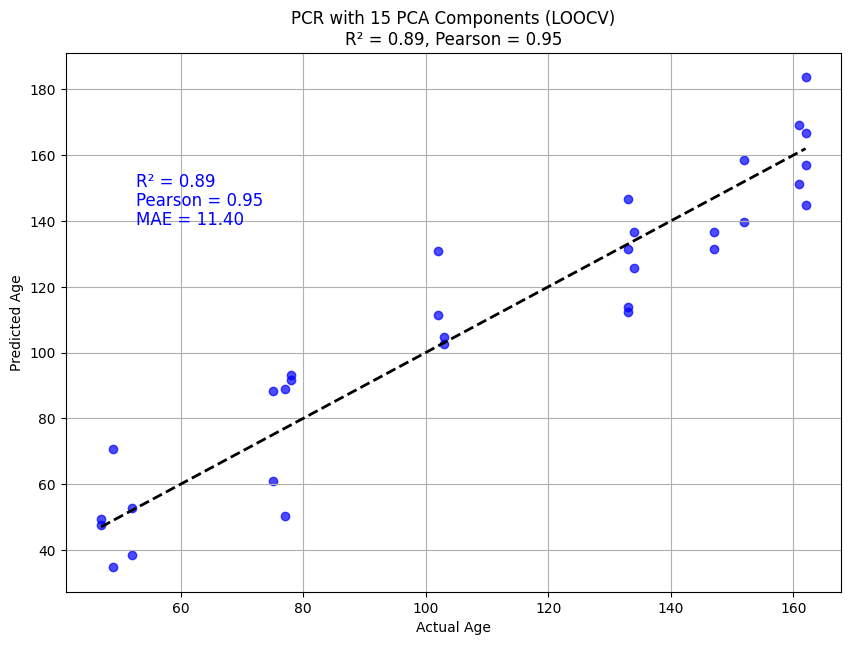


Explained Variance by Each of the First 20 Components:
Component  1: 0.1552 (Cumulative: 0.1552)
Component  2: 0.1022 (Cumulative: 0.2574)
Component  3: 0.0872 (Cumulative: 0.3446)
Component  4: 0.0581 (Cumulative: 0.4027)
Component  5: 0.0443 (Cumulative: 0.4470)
Component  6: 0.0426 (Cumulative: 0.4896)
Component  7: 0.0388 (Cumulative: 0.5284)
Component  8: 0.0363 (Cumulative: 0.5647)
Component  9: 0.0339 (Cumulative: 0.5986)
Component 10: 0.0284 (Cumulative: 0.6270)
Component 11: 0.0267 (Cumulative: 0.6537)
Component 12: 0.0239 (Cumulative: 0.6776)
Component 13: 0.0234 (Cumulative: 0.7010)
Component 14: 0.0215 (Cumulative: 0.7225)
Component 15: 0.0206 (Cumulative: 0.7431)
Component 16: 0.0205 (Cumulative: 0.7636)
Component 17: 0.0199 (Cumulative: 0.7834)
Component 18: 0.0196 (Cumulative: 0.8030)
Component 19: 0.0179 (Cumulative: 0.8209)
Component 20: 0.0170 (Cumulative: 0.8379)


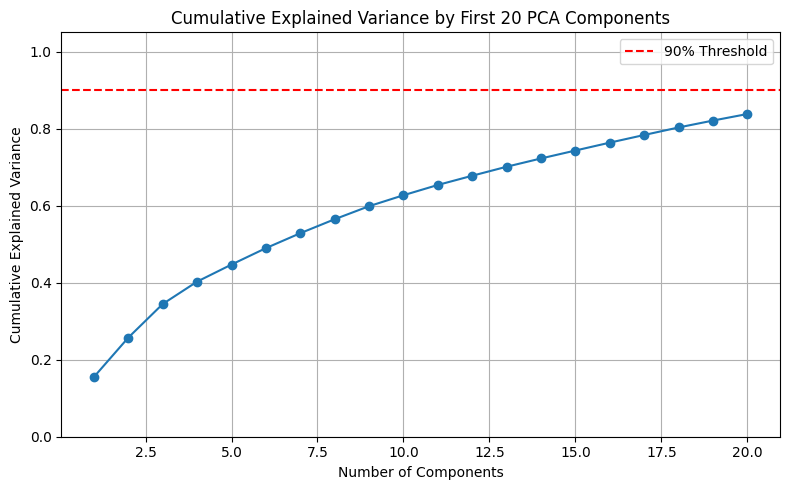

In [80]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Store results
results = []

# Loop through 1 to 20 components
for n_components in range(1, 21):
    pca = PCA(n_components=n_components, random_state=1)
    X_pca = pca.fit_transform(X_scaled)

    regressor = LinearRegression()
    y_pred = cross_val_predict(regressor, X_pca, y, cv=X.shape[0])  # LOOCV

    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    pearson_corr, _ = pearsonr(y, y_pred)

    results.append({
        'n_components': n_components,
        'mae': mae,
        'r2': r2,
        'pearson': pearson_corr,
        'y_pred': y_pred,
        'pca_model': pca
    })

    print(f"Components: {n_components:2d} | MAE: {mae:.2f} | R²: {r2:.3f} | Pearson: {pearson_corr:.3f}")

# Find the best result (lowest MAE)
best_result = min(results, key=lambda x: x['mae'])

# Unpack best model metrics
n_best = best_result['n_components']
y_pred_best = best_result['y_pred']
r2_best = best_result['r2']
pearson_best = best_result['pearson']
mae_best = best_result['mae']

# Plot predictions for the best model
plt.figure(figsize=(10, 7))
plt.scatter(y, y_pred_best, alpha=0.7, color='b')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title(f'PCR with {n_best} PCA Components (LOOCV)\nR² = {r2_best:.2f}, Pearson = {pearson_best:.2f}')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.2 * (y.max() - y.min()), f'MAE = {mae_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.1 * (y.max() - y.min()), f'R² = {r2_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.15 * (y.max() - y.min()), f'Pearson = {pearson_best:.2f}', fontsize=12, color='blue')
plt.grid(True)
plt.show()

# --- NEW: Explained variance using PCA with 20 components ---
pca_full = PCA(n_components=20, random_state=1)
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = explained_var.cumsum()

print("\nExplained Variance by Each of the First 20 Components:")
for i, (ev, cum_ev) in enumerate(zip(explained_var, cumulative_var), start=1):
    print(f"Component {i:2d}: {ev:.4f} (Cumulative: {cum_ev:.4f})")

# Optional: Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, 21), cumulative_var, marker='o', linestyle='-')
plt.title('Cumulative Explained Variance by First 20 PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.ylim(0, 1.05)
plt.grid(True)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Threshold')
plt.legend()
plt.tight_layout()
plt.show()

#### Female

In [81]:
heart_df_female = heart_df.loc[heart_df.iloc[:,-3] == "F"]

heart_df_female.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
B15_2,1.775166,827.819273,272.783906,544.976091,801.783499,675.154961,985.217363,905.926596,734.327175,689.356293,...,155.622923,1545.578229,110.652040,766.871893,4251.523574,361.542227,383.435947,F,Heart,75
B16_2,0.755241,513.563623,179.747268,517.339826,587.577203,718.233831,1095.098901,1731.766745,589.842925,611.744903,...,124.614703,1042.232058,9.818128,783.939765,6263.965714,229.593149,460.696779,F,Heart,103
C15_2,0.701235,823.951607,310.647287,445.985721,725.077414,732.089768,1006.974049,774.163893,520.316674,619.190867,...,178.113794,1884.920782,164.790321,746.114476,5004.717120,399.002948,388.484417,F,Heart,75
D14_2,23.259273,634.753062,177.820893,513.954902,545.467466,843.336219,969.386473,1786.462222,642.256053,520.707594,...,101.290382,1246.246851,3.751496,776.559597,5473.432134,387.904649,558.222551,F,Heart,133
D16_2,2.694510,489.502624,433.816087,468.844715,573.930599,760.749949,1014.033875,1009.543026,689.794523,526.327592,...,135.623663,1711.013758,52.093857,787.695048,10794.206478,377.231380,522.734912,F,Heart,47


In [82]:
heart_sub_df_female = heart_df_female.iloc[:,:-3]

heart_sub_df_female.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
B15_2,1.775166,827.819273,272.783906,544.976091,801.783499,675.154961,985.217363,905.926596,734.327175,689.356293,...,485.212155,89.350043,1805.344248,155.622923,1545.578229,110.652040,766.871893,4251.523574,361.542227,383.435947
B16_2,0.755241,513.563623,179.747268,517.339826,587.577203,718.233831,1095.098901,1731.766745,589.842925,611.744903,...,784.695006,129.146146,1262.762319,124.614703,1042.232058,9.818128,783.939765,6263.965714,229.593149,460.696779
C15_2,0.701235,823.951607,310.647287,445.985721,725.077414,732.089768,1006.974049,774.163893,520.316674,619.190867,...,685.106995,63.111187,2020.960451,178.113794,1884.920782,164.790321,746.114476,5004.717120,399.002948,388.484417
D14_2,23.259273,634.753062,177.820893,513.954902,545.467466,843.336219,969.386473,1786.462222,642.256053,520.707594,...,566.475841,120.047860,1852.488545,101.290382,1246.246851,3.751496,776.559597,5473.432134,387.904649,558.222551
D16_2,2.694510,489.502624,433.816087,468.844715,573.930599,760.749949,1014.033875,1009.543026,689.794523,526.327592,...,840.687075,48.501177,2074.772588,135.623663,1711.013758,52.093857,787.695048,10794.206478,377.231380,522.734912


In [83]:
heart_sub_df_female["age"] = heart_df_female["age_days"].tolist()

heart_sub_df_female.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
B15_2,1.775166,827.819273,272.783906,544.976091,801.783499,675.154961,985.217363,905.926596,734.327175,689.356293,...,89.350043,1805.344248,155.622923,1545.578229,110.652040,766.871893,4251.523574,361.542227,383.435947,75
B16_2,0.755241,513.563623,179.747268,517.339826,587.577203,718.233831,1095.098901,1731.766745,589.842925,611.744903,...,129.146146,1262.762319,124.614703,1042.232058,9.818128,783.939765,6263.965714,229.593149,460.696779,103
C15_2,0.701235,823.951607,310.647287,445.985721,725.077414,732.089768,1006.974049,774.163893,520.316674,619.190867,...,63.111187,2020.960451,178.113794,1884.920782,164.790321,746.114476,5004.717120,399.002948,388.484417,75
D14_2,23.259273,634.753062,177.820893,513.954902,545.467466,843.336219,969.386473,1786.462222,642.256053,520.707594,...,120.047860,1852.488545,101.290382,1246.246851,3.751496,776.559597,5473.432134,387.904649,558.222551,133
D16_2,2.694510,489.502624,433.816087,468.844715,573.930599,760.749949,1014.033875,1009.543026,689.794523,526.327592,...,48.501177,2074.772588,135.623663,1711.013758,52.093857,787.695048,10794.206478,377.231380,522.734912,47


In [84]:
heart_data_female = heart_sub_df_female.values

In [85]:
X, y = heart_data_female[:,:-1], heart_data_female[:,-1]

Components:  1 | MAE: 36.36 | R²: -0.250 | Pearson: -0.375
Components:  2 | MAE: 32.16 | R²: -0.071 | Pearson: 0.172
Components:  3 | MAE: 31.11 | R²: 0.088 | Pearson: 0.472
Components:  4 | MAE: 31.58 | R²: 0.068 | Pearson: 0.477
Components:  5 | MAE: 34.27 | R²: -0.163 | Pearson: 0.408
Components:  6 | MAE: 19.04 | R²: 0.577 | Pearson: 0.775
Components:  7 | MAE: 21.19 | R²: 0.451 | Pearson: 0.712
Components:  8 | MAE: 22.80 | R²: 0.387 | Pearson: 0.678
Components:  9 | MAE: 25.31 | R²: 0.231 | Pearson: 0.604
Components: 10 | MAE: 20.81 | R²: 0.500 | Pearson: 0.820
Components: 11 | MAE: 18.55 | R²: 0.610 | Pearson: 0.857
Components: 12 | MAE: 23.31 | R²: 0.311 | Pearson: 0.783
Components: 13 | MAE: 18.95 | R²: 0.655 | Pearson: 0.866
Components: 14 | MAE: 16.24 | R²: 0.694 | Pearson: 0.880
Components: 15 | MAE: 22.59 | R²: 0.426 | Pearson: 0.835
Components: 16 | MAE: 30.78 | R²: -0.121 | Pearson: 0.791
Components: 17 | MAE: 36.69 | R²: -0.453 | Pearson: 0.731
Components: 18 | MAE: 41.

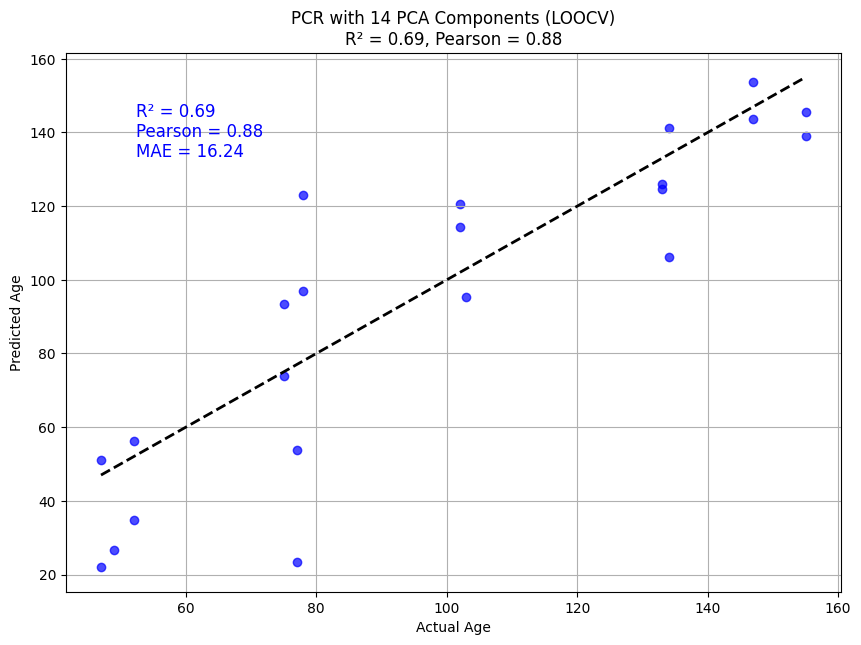


Explained Variance by Each of the First 20 Components:
Component  1: 0.1336 (Cumulative: 0.1336)
Component  2: 0.1142 (Cumulative: 0.2478)
Component  3: 0.0982 (Cumulative: 0.3461)
Component  4: 0.0650 (Cumulative: 0.4111)
Component  5: 0.0541 (Cumulative: 0.4652)
Component  6: 0.0490 (Cumulative: 0.5142)
Component  7: 0.0459 (Cumulative: 0.5601)
Component  8: 0.0439 (Cumulative: 0.6040)
Component  9: 0.0417 (Cumulative: 0.6456)
Component 10: 0.0391 (Cumulative: 0.6848)
Component 11: 0.0363 (Cumulative: 0.7210)
Component 12: 0.0345 (Cumulative: 0.7556)
Component 13: 0.0323 (Cumulative: 0.7879)
Component 14: 0.0297 (Cumulative: 0.8176)
Component 15: 0.0293 (Cumulative: 0.8469)
Component 16: 0.0281 (Cumulative: 0.8750)
Component 17: 0.0267 (Cumulative: 0.9017)
Component 18: 0.0254 (Cumulative: 0.9272)
Component 19: 0.0251 (Cumulative: 0.9523)
Component 20: 0.0240 (Cumulative: 0.9763)


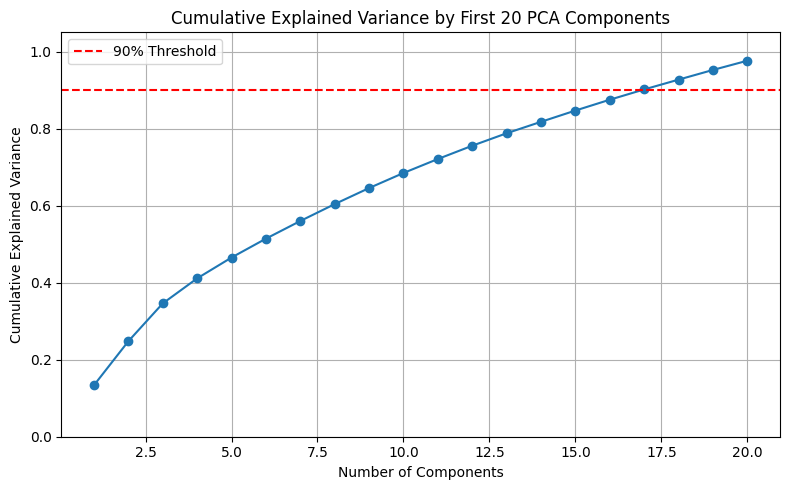

In [86]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Store results
results = []

# Loop through 1 to 20 components
for n_components in range(1, 21):
    pca = PCA(n_components=n_components, random_state=1)
    X_pca = pca.fit_transform(X_scaled)

    regressor = LinearRegression()
    y_pred = cross_val_predict(regressor, X_pca, y, cv=X.shape[0])  # LOOCV

    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    pearson_corr, _ = pearsonr(y, y_pred)

    results.append({
        'n_components': n_components,
        'mae': mae,
        'r2': r2,
        'pearson': pearson_corr,
        'y_pred': y_pred,
        'pca_model': pca
    })

    print(f"Components: {n_components:2d} | MAE: {mae:.2f} | R²: {r2:.3f} | Pearson: {pearson_corr:.3f}")

# Find the best result (lowest MAE)
best_result = min(results, key=lambda x: x['mae'])

# Unpack best model metrics
n_best = best_result['n_components']
y_pred_best = best_result['y_pred']
r2_best = best_result['r2']
pearson_best = best_result['pearson']
mae_best = best_result['mae']

# Plot predictions for the best model
plt.figure(figsize=(10, 7))
plt.scatter(y, y_pred_best, alpha=0.7, color='b')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title(f'PCR with {n_best} PCA Components (LOOCV)\nR² = {r2_best:.2f}, Pearson = {pearson_best:.2f}')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.2 * (y.max() - y.min()), f'MAE = {mae_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.1 * (y.max() - y.min()), f'R² = {r2_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.15 * (y.max() - y.min()), f'Pearson = {pearson_best:.2f}', fontsize=12, color='blue')
plt.grid(True)
plt.show()

# --- NEW: Explained variance using PCA with 20 components ---
pca_full = PCA(n_components=20, random_state=1)
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = explained_var.cumsum()

print("\nExplained Variance by Each of the First 20 Components:")
for i, (ev, cum_ev) in enumerate(zip(explained_var, cumulative_var), start=1):
    print(f"Component {i:2d}: {ev:.4f} (Cumulative: {cum_ev:.4f})")

# Optional: Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, 21), cumulative_var, marker='o', linestyle='-')
plt.title('Cumulative Explained Variance by First 20 PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.ylim(0, 1.05)
plt.grid(True)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Threshold')
plt.legend()
plt.tight_layout()
plt.show()

# Skin

In [87]:
skin_df = combined_df.loc[combined_df.iloc[:,-2] == "Skin"]

skin_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A17_1,0.943982,830.704200,302.074255,989.293184,623.972132,514.470215,865.631536,1193.193305,688.162911,543.733658,...,151.037127,1022.332555,89.678294,600.372581,6715.488271,527.685963,438.951651,F,Skin,134
A18_1,0.967501,645.323368,292.185393,921.061238,710.145955,565.988261,1256.784189,1532.522060,548.573237,582.435783,...,104.490140,650.160874,11.610016,700.470942,5032.941766,475.043139,543.735731,M,Skin,161
A19_1,7.352180,664.637032,227.917566,1073.418216,801.387572,460.246441,949.901599,1146.940012,571.999570,613.171775,...,77.933103,754.333623,35.290462,673.459648,5843.512316,388.195081,408.781184,M,Skin,162
A20_1,0.834110,719.837185,194.347699,1064.324736,759.874479,596.388861,1051.813082,1181.934288,535.498809,754.035707,...,76.738147,903.341449,41.705515,628.085052,6622.835742,518.816603,489.622743,M,Skin,161
B17_1,3.130785,817.134895,332.906809,948.627867,632.418578,578.151637,1076.990053,1243.965255,782.696260,675.205973,...,72.008056,1038.377038,42.787396,566.672092,6022.586819,658.508453,479.010111,F,Skin,155


In [88]:
skin_df_male = skin_df.loc[skin_df.iloc[:,-3] == "M"]

skin_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A18_1,0.967501,645.323368,292.185393,921.061238,710.145955,565.988261,1256.784189,1532.522060,548.573237,582.435783,...,104.490140,650.160874,11.610016,700.470942,5032.941766,475.043139,543.735731,M,Skin,161
A19_1,7.352180,664.637032,227.917566,1073.418216,801.387572,460.246441,949.901599,1146.940012,571.999570,613.171775,...,77.933103,754.333623,35.290462,673.459648,5843.512316,388.195081,408.781184,M,Skin,162
A20_1,0.834110,719.837185,194.347699,1064.324736,759.874479,596.388861,1051.813082,1181.934288,535.498809,754.035707,...,76.738147,903.341449,41.705515,628.085052,6622.835742,518.816603,489.622743,M,Skin,161
B19_1,1.054980,726.881356,318.604020,881.963446,790.180168,550.699663,964.251901,1141.488574,618.218396,705.781752,...,133.982485,983.241545,30.594426,699.451871,5694.783109,648.812822,489.510812,M,Skin,162
B20_1,1.093179,933.575229,224.101782,859.239028,678.864423,470.067153,947.786561,731.337035,701.821191,605.621401,...,150.858761,1432.065046,221.915423,537.844277,4675.528399,616.553195,382.612799,M,Skin,47


In [89]:
skin_sub_df_male = skin_df_male.iloc[:,:-3]
skin_sub_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A18_1,0.967501,645.323368,292.185393,921.061238,710.145955,565.988261,1256.784189,1532.522060,548.573237,582.435783,...,1026.518880,85.140114,1407.714392,104.490140,650.160874,11.610016,700.470942,5032.941766,475.043139,543.735731
A19_1,7.352180,664.637032,227.917566,1073.418216,801.387572,460.246441,949.901599,1146.940012,571.999570,613.171775,...,552.883903,110.282693,1277.808808,77.933103,754.333623,35.290462,673.459648,5843.512316,388.195081,408.781184
A20_1,0.834110,719.837185,194.347699,1064.324736,759.874479,596.388861,1051.813082,1181.934288,535.498809,754.035707,...,882.488692,85.079250,1377.116097,76.738147,903.341449,41.705515,628.085052,6622.835742,518.816603,489.622743
B19_1,1.054980,726.881356,318.604020,881.963446,790.180168,550.699663,964.251901,1141.488574,618.218396,705.781752,...,707.891713,98.113158,1342.989792,133.982485,983.241545,30.594426,699.451871,5694.783109,648.812822,489.510812
B20_1,1.093179,933.575229,224.101782,859.239028,678.864423,470.067153,947.786561,731.337035,701.821191,605.621401,...,815.511851,120.249737,1562.153398,150.858761,1432.065046,221.915423,537.844277,4675.528399,616.553195,382.612799


In [90]:
skin_sub_df_male["age"] = skin_df_male["age_days"].tolist()

skin_sub_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A18_1,0.967501,645.323368,292.185393,921.061238,710.145955,565.988261,1256.784189,1532.522060,548.573237,582.435783,...,85.140114,1407.714392,104.490140,650.160874,11.610016,700.470942,5032.941766,475.043139,543.735731,161
A19_1,7.352180,664.637032,227.917566,1073.418216,801.387572,460.246441,949.901599,1146.940012,571.999570,613.171775,...,110.282693,1277.808808,77.933103,754.333623,35.290462,673.459648,5843.512316,388.195081,408.781184,162
A20_1,0.834110,719.837185,194.347699,1064.324736,759.874479,596.388861,1051.813082,1181.934288,535.498809,754.035707,...,85.079250,1377.116097,76.738147,903.341449,41.705515,628.085052,6622.835742,518.816603,489.622743,161
B19_1,1.054980,726.881356,318.604020,881.963446,790.180168,550.699663,964.251901,1141.488574,618.218396,705.781752,...,98.113158,1342.989792,133.982485,983.241545,30.594426,699.451871,5694.783109,648.812822,489.510812,162
B20_1,1.093179,933.575229,224.101782,859.239028,678.864423,470.067153,947.786561,731.337035,701.821191,605.621401,...,120.249737,1562.153398,150.858761,1432.065046,221.915423,537.844277,4675.528399,616.553195,382.612799,47


In [91]:
skin_data_male = skin_sub_df_male.values

In [92]:
X, y = skin_data_male[:,:-1], skin_data_male[:,-1]

Components:  1 | MAE: 38.36 | R²: 0.026 | Pearson: 0.247
Components:  2 | MAE: 25.66 | R²: 0.373 | Pearson: 0.625
Components:  3 | MAE: 20.37 | R²: 0.568 | Pearson: 0.757
Components:  4 | MAE: 19.71 | R²: 0.653 | Pearson: 0.816
Components:  5 | MAE: 16.71 | R²: 0.754 | Pearson: 0.872
Components:  6 | MAE: 18.08 | R²: 0.693 | Pearson: 0.843
Components:  7 | MAE: 18.81 | R²: 0.668 | Pearson: 0.833
Components:  8 | MAE: 21.53 | R²: 0.544 | Pearson: 0.797
Components:  9 | MAE: 23.35 | R²: 0.178 | Pearson: 0.719
Components: 10 | MAE: 28.11 | R²: -0.216 | Pearson: 0.668
Components: 11 | MAE: 30.75 | R²: -0.698 | Pearson: 0.628
Components: 12 | MAE: 28.79 | R²: -0.549 | Pearson: 0.637
Components: 13 | MAE: 32.50 | R²: -1.114 | Pearson: 0.573
Components: 14 | MAE: 26.21 | R²: -0.262 | Pearson: 0.700
Components: 15 | MAE: 22.74 | R²: 0.290 | Pearson: 0.784
Components: 16 | MAE: 24.16 | R²: 0.103 | Pearson: 0.739
Components: 17 | MAE: 30.27 | R²: -0.450 | Pearson: 0.645
Components: 18 | MAE: 24.

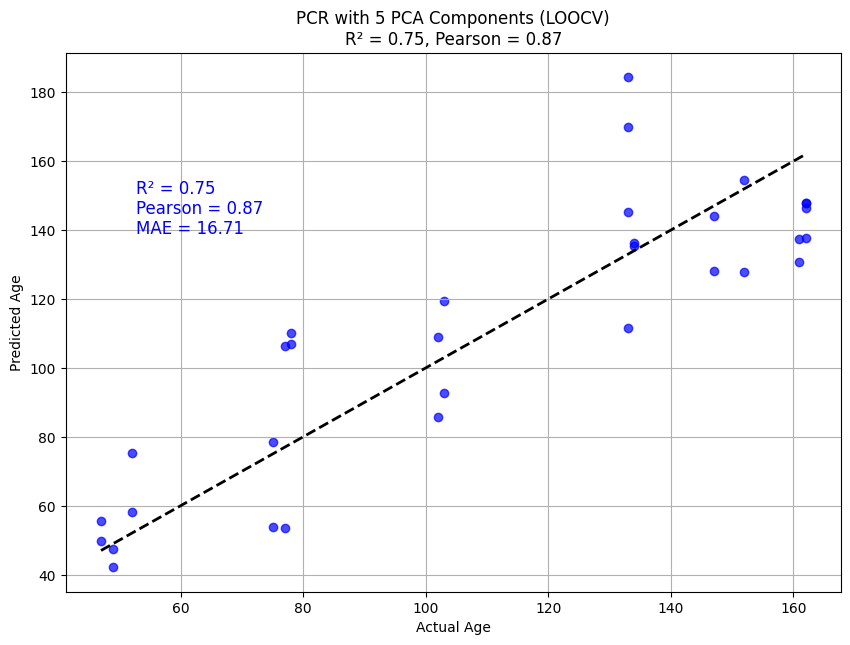


Explained Variance by Each of the First 20 Components:
Component  1: 0.1972 (Cumulative: 0.1972)
Component  2: 0.1017 (Cumulative: 0.2989)
Component  3: 0.0742 (Cumulative: 0.3731)
Component  4: 0.0607 (Cumulative: 0.4338)
Component  5: 0.0564 (Cumulative: 0.4902)
Component  6: 0.0511 (Cumulative: 0.5412)
Component  7: 0.0355 (Cumulative: 0.5767)
Component  8: 0.0307 (Cumulative: 0.6074)
Component  9: 0.0276 (Cumulative: 0.6350)
Component 10: 0.0252 (Cumulative: 0.6603)
Component 11: 0.0234 (Cumulative: 0.6837)
Component 12: 0.0210 (Cumulative: 0.7047)
Component 13: 0.0204 (Cumulative: 0.7251)
Component 14: 0.0193 (Cumulative: 0.7444)
Component 15: 0.0186 (Cumulative: 0.7630)
Component 16: 0.0176 (Cumulative: 0.7806)
Component 17: 0.0174 (Cumulative: 0.7980)
Component 18: 0.0168 (Cumulative: 0.8148)
Component 19: 0.0165 (Cumulative: 0.8313)
Component 20: 0.0157 (Cumulative: 0.8470)


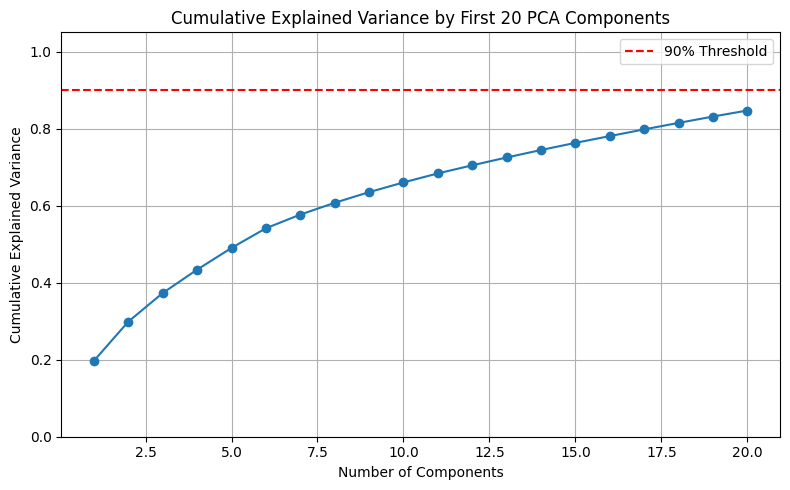

In [93]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Store results
results = []

# Loop through 1 to 20 components
for n_components in range(1, 21):
    pca = PCA(n_components=n_components, random_state=1)
    X_pca = pca.fit_transform(X_scaled)

    regressor = LinearRegression()
    y_pred = cross_val_predict(regressor, X_pca, y, cv=X.shape[0])  # LOOCV

    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    pearson_corr, _ = pearsonr(y, y_pred)

    results.append({
        'n_components': n_components,
        'mae': mae,
        'r2': r2,
        'pearson': pearson_corr,
        'y_pred': y_pred,
        'pca_model': pca
    })

    print(f"Components: {n_components:2d} | MAE: {mae:.2f} | R²: {r2:.3f} | Pearson: {pearson_corr:.3f}")

# Find the best result (lowest MAE)
best_result = min(results, key=lambda x: x['mae'])

# Unpack best model metrics
n_best = best_result['n_components']
y_pred_best = best_result['y_pred']
r2_best = best_result['r2']
pearson_best = best_result['pearson']
mae_best = best_result['mae']

# Plot predictions for the best model
plt.figure(figsize=(10, 7))
plt.scatter(y, y_pred_best, alpha=0.7, color='b')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title(f'PCR with {n_best} PCA Components (LOOCV)\nR² = {r2_best:.2f}, Pearson = {pearson_best:.2f}')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.2 * (y.max() - y.min()), f'MAE = {mae_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.1 * (y.max() - y.min()), f'R² = {r2_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.15 * (y.max() - y.min()), f'Pearson = {pearson_best:.2f}', fontsize=12, color='blue')
plt.grid(True)
plt.show()

# --- NEW: Explained variance using PCA with 20 components ---
pca_full = PCA(n_components=20, random_state=1)
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = explained_var.cumsum()

print("\nExplained Variance by Each of the First 20 Components:")
for i, (ev, cum_ev) in enumerate(zip(explained_var, cumulative_var), start=1):
    print(f"Component {i:2d}: {ev:.4f} (Cumulative: {cum_ev:.4f})")

# Optional: Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, 21), cumulative_var, marker='o', linestyle='-')
plt.title('Cumulative Explained Variance by First 20 PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.ylim(0, 1.05)
plt.grid(True)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Threshold')
plt.legend()
plt.tight_layout()
plt.show()

#### Female

In [94]:
skin_df_female = skin_df.loc[skin_df.iloc[:,-3] == "F"]

skin_df_female.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A17_1,0.943982,830.704200,302.074255,989.293184,623.972132,514.470215,865.631536,1193.193305,688.162911,543.733658,...,151.037127,1022.332555,89.678294,600.372581,6715.488271,527.685963,438.951651,F,Skin,134
B17_1,3.130785,817.134895,332.906809,948.627867,632.418578,578.151637,1076.990053,1243.965255,782.696260,675.205973,...,72.008056,1038.377038,42.787396,566.672092,6022.586819,658.508453,479.010111,F,Skin,155
B18_1,1.035014,822.835943,251.508345,1106.429715,647.918617,590.992860,961.527788,1397.268583,721.404594,600.307984,...,102.466363,1029.838696,34.155454,662.408810,6771.060052,574.432640,495.771594,F,Skin,147
C17_1,1.221560,648.648196,196.671110,961.367477,555.809659,527.713786,862.421142,886.852336,480.072958,641.318838,...,172.239916,955.259678,73.293581,564.360577,5100.011709,421.438093,434.875250,F,Skin,52
C19_1,7.151353,649.342851,238.855190,1230.032713,636.470415,444.814155,1184.264054,2238.373483,307.508178,473.419567,...,127.294083,699.402322,34.326494,729.438004,5937.053246,430.511450,487.722273,F,Skin,133


In [95]:
skin_sub_df_female = skin_df_female.iloc[:,:-3]

skin_sub_df_female.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A17_1,0.943982,830.704200,302.074255,989.293184,623.972132,514.470215,865.631536,1193.193305,688.162911,543.733658,...,804.272703,104.782007,1523.587021,151.037127,1022.332555,89.678294,600.372581,6715.488271,527.685963,438.951651
B17_1,3.130785,817.134895,332.906809,948.627867,632.418578,578.151637,1076.990053,1243.965255,782.696260,675.205973,...,1063.423318,80.356816,1230.398520,72.008056,1038.377038,42.787396,566.672092,6022.586819,658.508453,479.010111
B18_1,1.035014,822.835943,251.508345,1106.429715,647.918617,590.992860,961.527788,1397.268583,721.404594,600.307984,...,751.419994,101.431349,1400.373624,102.466363,1029.838696,34.155454,662.408810,6771.060052,574.432640,495.771594
C17_1,1.221560,648.648196,196.671110,961.367477,555.809659,527.713786,862.421142,886.852336,480.072958,641.318838,...,988.241790,97.724775,1349.823458,172.239916,955.259678,73.293581,564.360577,5100.011709,421.438093,434.875250
C19_1,7.151353,649.342851,238.855190,1230.032713,636.470415,444.814155,1184.264054,2238.373483,307.508178,473.419567,...,1018.352665,127.294083,1473.178714,127.294083,699.402322,34.326494,729.438004,5937.053246,430.511450,487.722273


In [96]:
skin_sub_df_female["age"] = skin_df_female["age_days"].tolist()

skin_sub_df_female.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A17_1,0.943982,830.704200,302.074255,989.293184,623.972132,514.470215,865.631536,1193.193305,688.162911,543.733658,...,104.782007,1523.587021,151.037127,1022.332555,89.678294,600.372581,6715.488271,527.685963,438.951651,134
B17_1,3.130785,817.134895,332.906809,948.627867,632.418578,578.151637,1076.990053,1243.965255,782.696260,675.205973,...,80.356816,1230.398520,72.008056,1038.377038,42.787396,566.672092,6022.586819,658.508453,479.010111,155
B18_1,1.035014,822.835943,251.508345,1106.429715,647.918617,590.992860,961.527788,1397.268583,721.404594,600.307984,...,101.431349,1400.373624,102.466363,1029.838696,34.155454,662.408810,6771.060052,574.432640,495.771594,147
C17_1,1.221560,648.648196,196.671110,961.367477,555.809659,527.713786,862.421142,886.852336,480.072958,641.318838,...,97.724775,1349.823458,172.239916,955.259678,73.293581,564.360577,5100.011709,421.438093,434.875250,52
C19_1,7.151353,649.342851,238.855190,1230.032713,636.470415,444.814155,1184.264054,2238.373483,307.508178,473.419567,...,127.294083,1473.178714,127.294083,699.402322,34.326494,729.438004,5937.053246,430.511450,487.722273,133


In [97]:
skin_data_female = skin_sub_df_female.values

In [98]:
X, y = skin_data_female[:,:-1], skin_data_female[:,-1]

Components:  1 | MAE: 34.65 | R²: -0.053 | Pearson: 0.038
Components:  2 | MAE: 24.59 | R²: 0.250 | Pearson: 0.662
Components:  3 | MAE: 25.70 | R²: 0.217 | Pearson: 0.647
Components:  4 | MAE: 25.80 | R²: 0.183 | Pearson: 0.644
Components:  5 | MAE: 27.09 | R²: 0.157 | Pearson: 0.638
Components:  6 | MAE: 25.60 | R²: 0.308 | Pearson: 0.708
Components:  7 | MAE: 20.43 | R²: 0.603 | Pearson: 0.818
Components:  8 | MAE: 23.24 | R²: 0.477 | Pearson: 0.779
Components:  9 | MAE: 29.51 | R²: -0.414 | Pearson: 0.697
Components: 10 | MAE: 27.78 | R²: -0.011 | Pearson: 0.743
Components: 11 | MAE: 38.35 | R²: -1.101 | Pearson: 0.630
Components: 12 | MAE: 41.96 | R²: -1.320 | Pearson: 0.615
Components: 13 | MAE: 53.49 | R²: -6.220 | Pearson: 0.509
Components: 14 | MAE: 66.49 | R²: -10.761 | Pearson: 0.458
Components: 15 | MAE: 75.76 | R²: -14.511 | Pearson: 0.398
Components: 16 | MAE: 113.05 | R²: -23.306 | Pearson: 0.527
Components: 17 | MAE: 101.57 | R²: -23.516 | Pearson: 0.275
Components: 18 

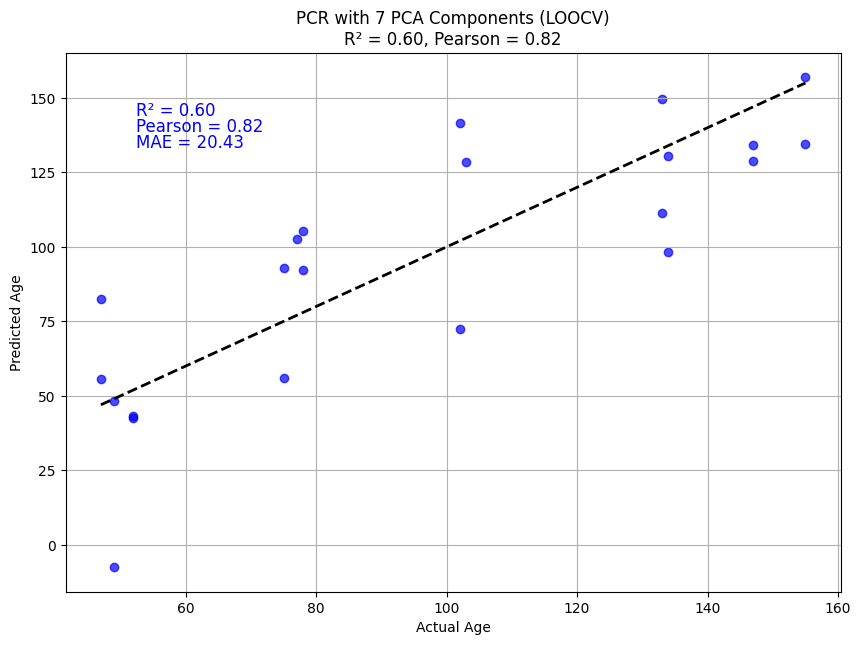


Explained Variance by Each of the First 20 Components:
Component  1: 0.2487 (Cumulative: 0.2487)
Component  2: 0.1212 (Cumulative: 0.3699)
Component  3: 0.0820 (Cumulative: 0.4520)
Component  4: 0.0549 (Cumulative: 0.5069)
Component  5: 0.0547 (Cumulative: 0.5615)
Component  6: 0.0487 (Cumulative: 0.6103)
Component  7: 0.0391 (Cumulative: 0.6494)
Component  8: 0.0349 (Cumulative: 0.6844)
Component  9: 0.0320 (Cumulative: 0.7164)
Component 10: 0.0309 (Cumulative: 0.7473)
Component 11: 0.0296 (Cumulative: 0.7769)
Component 12: 0.0269 (Cumulative: 0.8038)
Component 13: 0.0256 (Cumulative: 0.8293)
Component 14: 0.0253 (Cumulative: 0.8546)
Component 15: 0.0234 (Cumulative: 0.8780)
Component 16: 0.0226 (Cumulative: 0.9007)
Component 17: 0.0223 (Cumulative: 0.9230)
Component 18: 0.0205 (Cumulative: 0.9435)
Component 19: 0.0198 (Cumulative: 0.9633)
Component 20: 0.0185 (Cumulative: 0.9818)


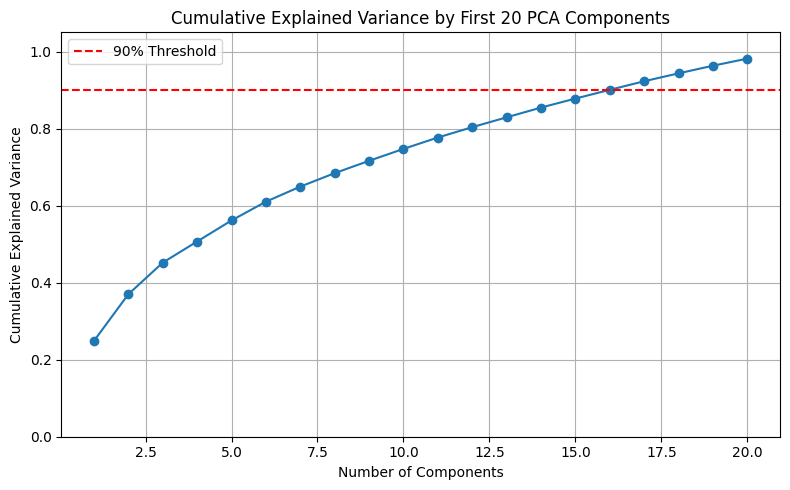

In [99]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Store results
results = []

# Loop through 1 to 20 components
for n_components in range(1, 21):
    pca = PCA(n_components=n_components, random_state=1)
    X_pca = pca.fit_transform(X_scaled)

    regressor = LinearRegression()
    y_pred = cross_val_predict(regressor, X_pca, y, cv=X.shape[0])  # LOOCV

    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    pearson_corr, _ = pearsonr(y, y_pred)

    results.append({
        'n_components': n_components,
        'mae': mae,
        'r2': r2,
        'pearson': pearson_corr,
        'y_pred': y_pred,
        'pca_model': pca
    })

    print(f"Components: {n_components:2d} | MAE: {mae:.2f} | R²: {r2:.3f} | Pearson: {pearson_corr:.3f}")

# Find the best result (lowest MAE)
best_result = min(results, key=lambda x: x['mae'])

# Unpack best model metrics
n_best = best_result['n_components']
y_pred_best = best_result['y_pred']
r2_best = best_result['r2']
pearson_best = best_result['pearson']
mae_best = best_result['mae']

# Plot predictions for the best model
plt.figure(figsize=(10, 7))
plt.scatter(y, y_pred_best, alpha=0.7, color='b')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title(f'PCR with {n_best} PCA Components (LOOCV)\nR² = {r2_best:.2f}, Pearson = {pearson_best:.2f}')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.2 * (y.max() - y.min()), f'MAE = {mae_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.1 * (y.max() - y.min()), f'R² = {r2_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.15 * (y.max() - y.min()), f'Pearson = {pearson_best:.2f}', fontsize=12, color='blue')
plt.grid(True)
plt.show()

# --- NEW: Explained variance using PCA with 20 components ---
pca_full = PCA(n_components=20, random_state=1)
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = explained_var.cumsum()

print("\nExplained Variance by Each of the First 20 Components:")
for i, (ev, cum_ev) in enumerate(zip(explained_var, cumulative_var), start=1):
    print(f"Component {i:2d}: {ev:.4f} (Cumulative: {cum_ev:.4f})")

# Optional: Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, 21), cumulative_var, marker='o', linestyle='-')
plt.title('Cumulative Explained Variance by First 20 PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.ylim(0, 1.05)
plt.grid(True)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Threshold')
plt.legend()
plt.tight_layout()
plt.show()

# Brain

In [100]:
brain_df = combined_df.loc[combined_df.iloc[:,-2] == "Brain"]

brain_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A21_2,53.082851,503.745418,485.328919,309.830515,144.623685,546.536696,2395.769875,326.080367,486.953904,418.162863,...,215.039711,609.369457,19.499823,1015.074101,613.702751,159.790213,334.205294,M,Brain,162
A22_2,52.450281,430.841595,533.066122,344.673276,94.731630,475.263772,2237.165051,269.209096,439.404906,449.573838,...,261.180992,611.741544,21.408278,1192.976291,894.866020,181.435156,439.404906,M,Brain,152
A23_2,17.414194,584.876719,587.879166,315.256959,104.485163,422.744569,3009.653097,232.389415,351.286325,369.301009,...,210.771795,505.011623,31.225451,1231.003362,736.800549,254.007035,441.960231,F,Brain,78
A24_2,43.256835,536.384749,414.112096,325.868154,98.048825,484.476547,1956.939196,307.411904,321.254091,415.265612,...,223.205266,566.376154,23.647070,981.065008,760.166773,155.147847,410.651550,M,Brain,103
B21_2,40.582672,504.195584,454.790592,391.711005,112.043463,464.054028,1794.018758,178.651979,393.475469,470.670768,...,235.114826,775.040806,24.261380,1051.179420,1012.802328,187.474299,307.016734,M,Brain,162


In [101]:
brain_df_male = brain_df.loc[brain_df.iloc[:,-3] == "M"]

brain_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A21_2,53.082851,503.745418,485.328919,309.830515,144.623685,546.536696,2395.769875,326.080367,486.953904,418.162863,...,215.039711,609.369457,19.499823,1015.074101,613.702751,159.790213,334.205294,M,Brain,162
A22_2,52.450281,430.841595,533.066122,344.673276,94.731630,475.263772,2237.165051,269.209096,439.404906,449.573838,...,261.180992,611.741544,21.408278,1192.976291,894.866020,181.435156,439.404906,M,Brain,152
A24_2,43.256835,536.384749,414.112096,325.868154,98.048825,484.476547,1956.939196,307.411904,321.254091,415.265612,...,223.205266,566.376154,23.647070,981.065008,760.166773,155.147847,410.651550,M,Brain,103
B21_2,40.582672,504.195584,454.790592,391.711005,112.043463,464.054028,1794.018758,178.651979,393.475469,470.670768,...,235.114826,775.040806,24.261380,1051.179420,1012.802328,187.474299,307.016734,M,Brain,162
B22_2,46.363146,593.237531,411.999777,362.475507,83.769776,404.623822,2161.681696,285.027979,385.130227,367.217193,...,190.194271,613.784834,23.708427,1295.006973,913.564724,285.027979,431.493373,M,Brain,49


In [102]:
brain_sub_df_male = brain_df_male.iloc[:,:-3]
brain_sub_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A21_2,53.082851,503.745418,485.328919,309.830515,144.623685,546.536696,2395.769875,326.080367,486.953904,418.162863,...,1468.986639,102.915731,523.786902,215.039711,609.369457,19.499823,1015.074101,613.702751,159.790213,334.205294
A22_2,52.450281,430.841595,533.066122,344.673276,94.731630,475.263772,2237.165051,269.209096,439.404906,449.573838,...,1841.111908,63.689627,754.641799,261.180992,611.741544,21.408278,1192.976291,894.866020,181.435156,439.404906
A24_2,43.256835,536.384749,414.112096,325.868154,98.048825,484.476547,1956.939196,307.411904,321.254091,415.265612,...,1837.550333,73.824998,694.416384,223.205266,566.376154,23.647070,981.065008,760.166773,155.147847,410.651550
B21_2,40.582672,504.195584,454.790592,391.711005,112.043463,464.054028,1794.018758,178.651979,393.475469,470.670768,...,1570.372948,43.229368,715.049030,235.114826,775.040806,24.261380,1051.179420,1012.802328,187.474299,307.016734
B22_2,46.363146,593.237531,411.999777,362.475507,83.769776,404.623822,2161.681696,285.027979,385.130227,367.217193,...,2326.060124,77.974382,936.746297,190.194271,613.784834,23.708427,1295.006973,913.564724,285.027979,431.493373


In [103]:
brain_sub_df_male["age"] = brain_df_male["age_days"].tolist()

brain_sub_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A21_2,53.082851,503.745418,485.328919,309.830515,144.623685,546.536696,2395.769875,326.080367,486.953904,418.162863,...,102.915731,523.786902,215.039711,609.369457,19.499823,1015.074101,613.702751,159.790213,334.205294,162
A22_2,52.450281,430.841595,533.066122,344.673276,94.731630,475.263772,2237.165051,269.209096,439.404906,449.573838,...,63.689627,754.641799,261.180992,611.741544,21.408278,1192.976291,894.866020,181.435156,439.404906,152
A24_2,43.256835,536.384749,414.112096,325.868154,98.048825,484.476547,1956.939196,307.411904,321.254091,415.265612,...,73.824998,694.416384,223.205266,566.376154,23.647070,981.065008,760.166773,155.147847,410.651550,103
B21_2,40.582672,504.195584,454.790592,391.711005,112.043463,464.054028,1794.018758,178.651979,393.475469,470.670768,...,43.229368,715.049030,235.114826,775.040806,24.261380,1051.179420,1012.802328,187.474299,307.016734,162
B22_2,46.363146,593.237531,411.999777,362.475507,83.769776,404.623822,2161.681696,285.027979,385.130227,367.217193,...,77.974382,936.746297,190.194271,613.784834,23.708427,1295.006973,913.564724,285.027979,431.493373,49


In [104]:
brain_data_male = brain_sub_df_male.values

In [105]:
X, y = brain_data_male[:,:-1], brain_data_male[:,-1]

Components:  1 | MAE: 37.71 | R²: -0.015 | Pearson: 0.148
Components:  2 | MAE: 33.51 | R²: 0.067 | Pearson: 0.302
Components:  3 | MAE: 34.61 | R²: 0.012 | Pearson: 0.280
Components:  4 | MAE: 29.65 | R²: 0.205 | Pearson: 0.512
Components:  5 | MAE: 25.16 | R²: 0.412 | Pearson: 0.671
Components:  6 | MAE: 25.29 | R²: 0.382 | Pearson: 0.665
Components:  7 | MAE: 27.59 | R²: 0.261 | Pearson: 0.609
Components:  8 | MAE: 25.76 | R²: 0.363 | Pearson: 0.672
Components:  9 | MAE: 23.21 | R²: 0.473 | Pearson: 0.732
Components: 10 | MAE: 19.57 | R²: 0.666 | Pearson: 0.830
Components: 11 | MAE: 21.24 | R²: 0.598 | Pearson: 0.805
Components: 12 | MAE: 22.31 | R²: 0.532 | Pearson: 0.778
Components: 13 | MAE: 26.50 | R²: 0.217 | Pearson: 0.667
Components: 14 | MAE: 27.78 | R²: -0.005 | Pearson: 0.614
Components: 15 | MAE: 28.77 | R²: -0.114 | Pearson: 0.588
Components: 16 | MAE: 32.34 | R²: -0.476 | Pearson: 0.503
Components: 17 | MAE: 38.72 | R²: -1.255 | Pearson: 0.503
Components: 18 | MAE: 38.8

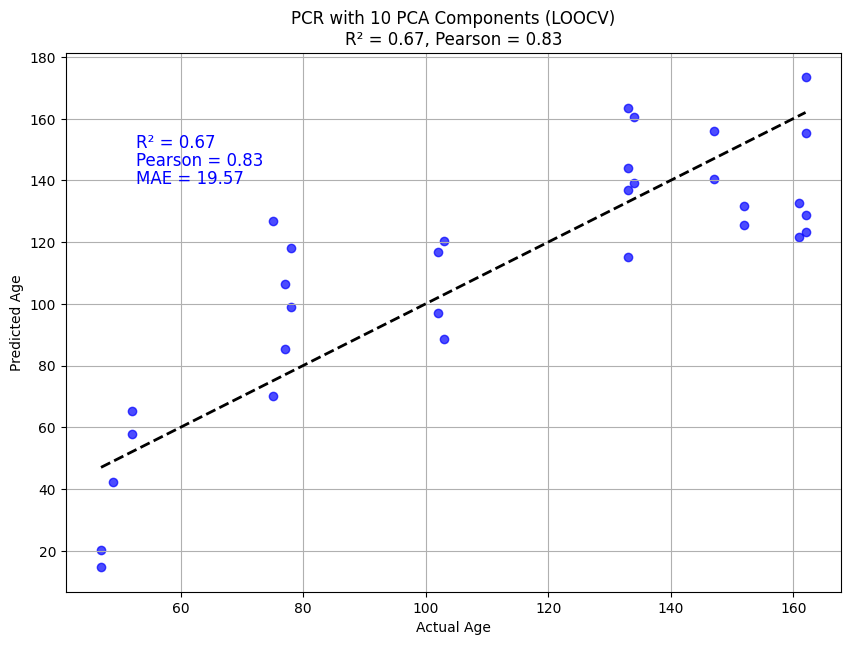


Explained Variance by Each of the First 20 Components:
Component  1: 0.1579 (Cumulative: 0.1579)
Component  2: 0.1056 (Cumulative: 0.2635)
Component  3: 0.0849 (Cumulative: 0.3484)
Component  4: 0.0714 (Cumulative: 0.4198)
Component  5: 0.0572 (Cumulative: 0.4770)
Component  6: 0.0452 (Cumulative: 0.5222)
Component  7: 0.0335 (Cumulative: 0.5557)
Component  8: 0.0305 (Cumulative: 0.5862)
Component  9: 0.0292 (Cumulative: 0.6154)
Component 10: 0.0277 (Cumulative: 0.6432)
Component 11: 0.0265 (Cumulative: 0.6697)
Component 12: 0.0240 (Cumulative: 0.6937)
Component 13: 0.0231 (Cumulative: 0.7168)
Component 14: 0.0215 (Cumulative: 0.7383)
Component 15: 0.0208 (Cumulative: 0.7591)
Component 16: 0.0197 (Cumulative: 0.7789)
Component 17: 0.0191 (Cumulative: 0.7980)
Component 18: 0.0189 (Cumulative: 0.8169)
Component 19: 0.0179 (Cumulative: 0.8348)
Component 20: 0.0173 (Cumulative: 0.8520)


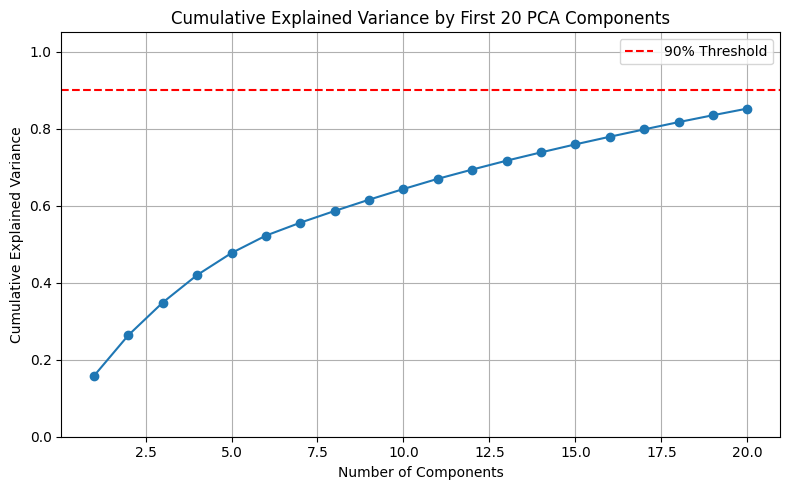

In [106]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Store results
results = []

# Loop through 1 to 20 components
for n_components in range(1, 21):
    pca = PCA(n_components=n_components, random_state=1)
    X_pca = pca.fit_transform(X_scaled)

    regressor = LinearRegression()
    y_pred = cross_val_predict(regressor, X_pca, y, cv=X.shape[0])  # LOOCV

    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    pearson_corr, _ = pearsonr(y, y_pred)

    results.append({
        'n_components': n_components,
        'mae': mae,
        'r2': r2,
        'pearson': pearson_corr,
        'y_pred': y_pred,
        'pca_model': pca
    })

    print(f"Components: {n_components:2d} | MAE: {mae:.2f} | R²: {r2:.3f} | Pearson: {pearson_corr:.3f}")

# Find the best result (lowest MAE)
best_result = min(results, key=lambda x: x['mae'])

# Unpack best model metrics
n_best = best_result['n_components']
y_pred_best = best_result['y_pred']
r2_best = best_result['r2']
pearson_best = best_result['pearson']
mae_best = best_result['mae']

# Plot predictions for the best model
plt.figure(figsize=(10, 7))
plt.scatter(y, y_pred_best, alpha=0.7, color='b')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title(f'PCR with {n_best} PCA Components (LOOCV)\nR² = {r2_best:.2f}, Pearson = {pearson_best:.2f}')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.2 * (y.max() - y.min()), f'MAE = {mae_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.1 * (y.max() - y.min()), f'R² = {r2_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.15 * (y.max() - y.min()), f'Pearson = {pearson_best:.2f}', fontsize=12, color='blue')
plt.grid(True)
plt.show()

# --- NEW: Explained variance using PCA with 20 components ---
pca_full = PCA(n_components=20, random_state=1)
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = explained_var.cumsum()

print("\nExplained Variance by Each of the First 20 Components:")
for i, (ev, cum_ev) in enumerate(zip(explained_var, cumulative_var), start=1):
    print(f"Component {i:2d}: {ev:.4f} (Cumulative: {cum_ev:.4f})")

# Optional: Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, 21), cumulative_var, marker='o', linestyle='-')
plt.title('Cumulative Explained Variance by First 20 PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.ylim(0, 1.05)
plt.grid(True)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Threshold')
plt.legend()
plt.tight_layout()
plt.show()

#### Female

In [107]:
brain_df_female = brain_df.loc[brain_df.iloc[:,-3] == "F"]

brain_df_female.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A23_2,17.414194,584.876719,587.879166,315.256959,104.485163,422.744569,3009.653097,232.389415,351.286325,369.301009,...,210.771795,505.011623,31.225451,1231.003362,736.800549,254.007035,441.960231,F,Brain,78
C22_2,26.304342,542.317178,356.507784,341.956446,93.464364,463.404152,2857.099272,389.528128,366.022120,348.672448,...,314.532770,457.807484,7.835336,1242.460408,826.627938,146.073048,434.301476,F,Brain,103
C23_2,37.729860,592.298911,484.499311,353.343132,107.200713,560.557917,2921.968033,204.819239,523.426944,464.137164,...,219.192519,630.627657,49.108706,1183.998934,798.914810,276.086752,457.549411,F,Brain,49
D23_2,45.887753,606.536140,567.463400,387.092727,105.859866,459.786197,1926.831288,239.888451,454.788521,333.026959,...,175.827330,689.679296,36.346735,1182.177555,884.134328,265.785499,567.009066,F,Brain,75
E21_2,116.364825,539.509645,537.586259,388.043033,110.113822,399.102500,2589.357786,264.946358,389.004726,373.617642,...,195.223633,557.300961,47.122946,1332.425334,890.046660,320.243693,427.953283,F,Brain,102


In [108]:
brain_sub_df_female = brain_df_female.iloc[:,:-3]

brain_sub_df_female.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A23_2,17.414194,584.876719,587.879166,315.256959,104.485163,422.744569,3009.653097,232.389415,351.286325,369.301009,...,2283.060869,65.453349,807.057814,210.771795,505.011623,31.225451,1231.003362,736.800549,254.007035,441.960231
C22_2,26.304342,542.317178,356.507784,341.956446,93.464364,463.404152,2857.099272,389.528128,366.022120,348.672448,...,2035.508335,65.481022,805.360598,314.532770,457.807484,7.835336,1242.460408,826.627938,146.073048,434.301476
C23_2,37.729860,592.298911,484.499311,353.343132,107.200713,560.557917,2921.968033,204.819239,523.426944,464.137164,...,1957.760504,75.459720,913.302162,219.192519,630.627657,49.108706,1183.998934,798.914810,276.086752,457.549411
D23_2,45.887753,606.536140,567.463400,387.092727,105.859866,459.786197,1926.831288,239.888451,454.788521,333.026959,...,2178.078093,61.789449,706.035327,175.827330,689.679296,36.346735,1182.177555,884.134328,265.785499,567.009066
E21_2,116.364825,539.509645,537.586259,388.043033,110.113822,399.102500,2589.357786,264.946358,389.004726,373.617642,...,1947.427862,61.548337,929.476063,195.223633,557.300961,47.122946,1332.425334,890.046660,320.243693,427.953283


In [109]:
brain_sub_df_female["age"] = brain_df_female["age_days"].tolist()

brain_sub_df_female.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A23_2,17.414194,584.876719,587.879166,315.256959,104.485163,422.744569,3009.653097,232.389415,351.286325,369.301009,...,65.453349,807.057814,210.771795,505.011623,31.225451,1231.003362,736.800549,254.007035,441.960231,78
C22_2,26.304342,542.317178,356.507784,341.956446,93.464364,463.404152,2857.099272,389.528128,366.022120,348.672448,...,65.481022,805.360598,314.532770,457.807484,7.835336,1242.460408,826.627938,146.073048,434.301476,103
C23_2,37.729860,592.298911,484.499311,353.343132,107.200713,560.557917,2921.968033,204.819239,523.426944,464.137164,...,75.459720,913.302162,219.192519,630.627657,49.108706,1183.998934,798.914810,276.086752,457.549411,49
D23_2,45.887753,606.536140,567.463400,387.092727,105.859866,459.786197,1926.831288,239.888451,454.788521,333.026959,...,61.789449,706.035327,175.827330,689.679296,36.346735,1182.177555,884.134328,265.785499,567.009066,75
E21_2,116.364825,539.509645,537.586259,388.043033,110.113822,399.102500,2589.357786,264.946358,389.004726,373.617642,...,61.548337,929.476063,195.223633,557.300961,47.122946,1332.425334,890.046660,320.243693,427.953283,102


In [110]:
brain_data_female = brain_sub_df_female.values

In [111]:
X, y = brain_data_female[:,:-1], brain_data_female[:,-1]

Components:  1 | MAE: 33.89 | R²: -0.063 | Pearson: 0.042
Components:  2 | MAE: 19.04 | R²: 0.620 | Pearson: 0.788
Components:  3 | MAE: 20.05 | R²: 0.590 | Pearson: 0.771
Components:  4 | MAE: 15.79 | R²: 0.736 | Pearson: 0.860
Components:  5 | MAE: 16.51 | R²: 0.716 | Pearson: 0.850
Components:  6 | MAE: 18.15 | R²: 0.601 | Pearson: 0.801
Components:  7 | MAE: 18.25 | R²: 0.600 | Pearson: 0.800
Components:  8 | MAE: 15.43 | R²: 0.753 | Pearson: 0.876
Components:  9 | MAE: 17.40 | R²: 0.631 | Pearson: 0.822
Components: 10 | MAE: 17.18 | R²: 0.704 | Pearson: 0.856
Components: 11 | MAE: 19.08 | R²: 0.617 | Pearson: 0.823
Components: 12 | MAE: 16.49 | R²: 0.703 | Pearson: 0.869
Components: 13 | MAE: 19.10 | R²: 0.626 | Pearson: 0.848
Components: 14 | MAE: 23.32 | R²: 0.364 | Pearson: 0.786
Components: 15 | MAE: 27.32 | R²: 0.150 | Pearson: 0.714
Components: 16 | MAE: 24.42 | R²: 0.341 | Pearson: 0.776
Components: 17 | MAE: 13.60 | R²: 0.784 | Pearson: 0.905
Components: 18 | MAE: 17.11 | 

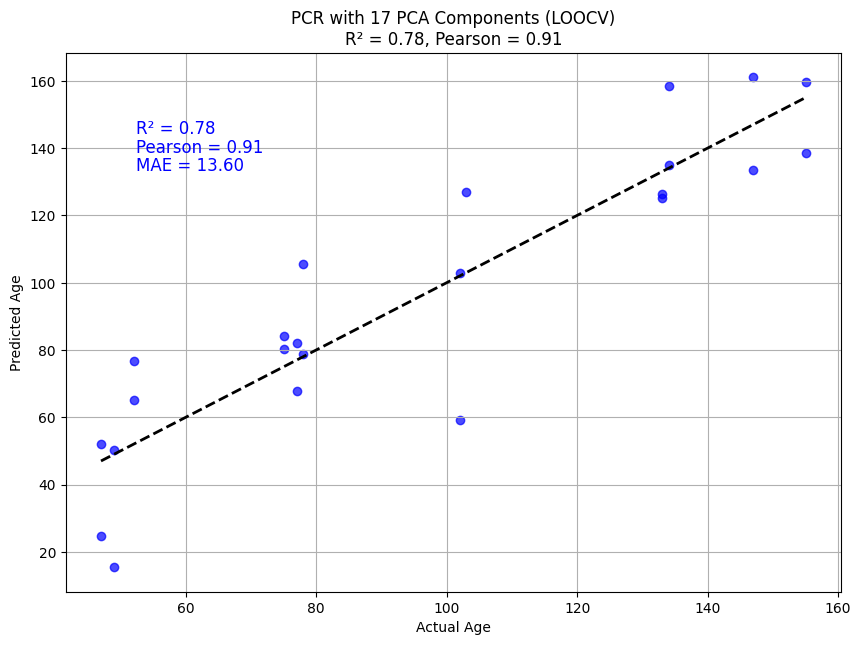


Explained Variance by Each of the First 20 Components:
Component  1: 0.1433 (Cumulative: 0.1433)
Component  2: 0.1067 (Cumulative: 0.2500)
Component  3: 0.0968 (Cumulative: 0.3468)
Component  4: 0.0800 (Cumulative: 0.4267)
Component  5: 0.0545 (Cumulative: 0.4813)
Component  6: 0.0493 (Cumulative: 0.5306)
Component  7: 0.0434 (Cumulative: 0.5740)
Component  8: 0.0415 (Cumulative: 0.6154)
Component  9: 0.0368 (Cumulative: 0.6522)
Component 10: 0.0353 (Cumulative: 0.6875)
Component 11: 0.0320 (Cumulative: 0.7194)
Component 12: 0.0307 (Cumulative: 0.7501)
Component 13: 0.0296 (Cumulative: 0.7797)
Component 14: 0.0281 (Cumulative: 0.8078)
Component 15: 0.0270 (Cumulative: 0.8348)
Component 16: 0.0258 (Cumulative: 0.8606)
Component 17: 0.0253 (Cumulative: 0.8859)
Component 18: 0.0243 (Cumulative: 0.9103)
Component 19: 0.0240 (Cumulative: 0.9342)
Component 20: 0.0227 (Cumulative: 0.9569)


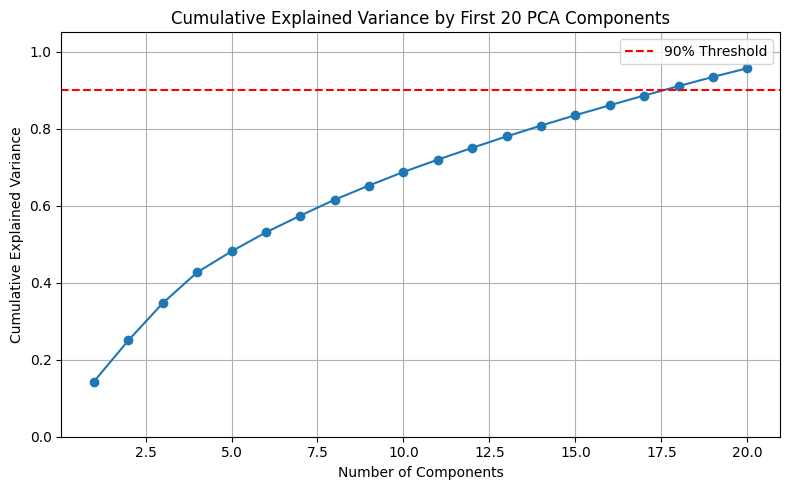

In [112]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Store results
results = []

# Loop through 1 to 20 components
for n_components in range(1, 21):
    pca = PCA(n_components=n_components, random_state=1)
    X_pca = pca.fit_transform(X_scaled)

    regressor = LinearRegression()
    y_pred = cross_val_predict(regressor, X_pca, y, cv=X.shape[0])  # LOOCV

    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    pearson_corr, _ = pearsonr(y, y_pred)

    results.append({
        'n_components': n_components,
        'mae': mae,
        'r2': r2,
        'pearson': pearson_corr,
        'y_pred': y_pred,
        'pca_model': pca
    })

    print(f"Components: {n_components:2d} | MAE: {mae:.2f} | R²: {r2:.3f} | Pearson: {pearson_corr:.3f}")

# Find the best result (lowest MAE)
best_result = min(results, key=lambda x: x['mae'])

# Unpack best model metrics
n_best = best_result['n_components']
y_pred_best = best_result['y_pred']
r2_best = best_result['r2']
pearson_best = best_result['pearson']
mae_best = best_result['mae']

# Plot predictions for the best model
plt.figure(figsize=(10, 7))
plt.scatter(y, y_pred_best, alpha=0.7, color='b')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title(f'PCR with {n_best} PCA Components (LOOCV)\nR² = {r2_best:.2f}, Pearson = {pearson_best:.2f}')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.2 * (y.max() - y.min()), f'MAE = {mae_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.1 * (y.max() - y.min()), f'R² = {r2_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.15 * (y.max() - y.min()), f'Pearson = {pearson_best:.2f}', fontsize=12, color='blue')
plt.grid(True)
plt.show()

# --- NEW: Explained variance using PCA with 20 components ---
pca_full = PCA(n_components=20, random_state=1)
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = explained_var.cumsum()

print("\nExplained Variance by Each of the First 20 Components:")
for i, (ev, cum_ev) in enumerate(zip(explained_var, cumulative_var), start=1):
    print(f"Component {i:2d}: {ev:.4f} (Cumulative: {cum_ev:.4f})")

# Optional: Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, 21), cumulative_var, marker='o', linestyle='-')
plt.title('Cumulative Explained Variance by First 20 PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.ylim(0, 1.05)
plt.grid(True)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Threshold')
plt.legend()
plt.tight_layout()
plt.show()

# Fat

In [113]:
fat_df = combined_df.loc[combined_df.iloc[:,-2] == "Fat"]

fat_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A5_2,8535.344945,282.528840,675.520083,437.601060,227.297638,624.537435,1512.485217,686.141468,633.034543,422.731121,...,93.468188,1270.317640,57.355479,390.866966,1659.060329,274.031732,397.239797,M,Fat,52
A6_2,2969.048330,518.818239,99.478423,353.531012,205.078596,481.322526,746.088176,278.539586,511.931271,371.131041,...,143.861105,522.644332,147.687198,311.443987,3021.848416,188.243786,208.904689,M,Fat,77
A7_2,3743.681369,269.376862,279.889130,266.748795,174.766452,482.250285,1165.547692,319.310134,448.085415,210.245356,...,84.098142,876.460328,60.445540,373.185507,1625.459408,223.385691,320.624168,F,Fat,78
A8_2,3371.080449,322.962776,247.855154,373.034524,105.150671,274.142821,786.126447,280.401790,207.797755,186.517262,...,61.337892,579.580486,71.352241,394.315017,1107.837429,173.999325,265.380266,M,Fat,103
B5_2,5975.375798,410.423324,424.965883,507.373716,305.393733,665.726022,1176.331417,664.110182,533.227153,365.179808,...,67.865274,1315.293645,43.627676,484.751958,1515.657787,302.162054,337.710530,F,Fat,134


In [114]:
fat_df_male = fat_df.loc[fat_df.iloc[:,-3] == "M"]

fat_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A5_2,8535.344945,282.528840,675.520083,437.601060,227.297638,624.537435,1512.485217,686.141468,633.034543,422.731121,...,93.468188,1270.317640,57.355479,390.866966,1659.060329,274.031732,397.239797,M,Fat,52
A6_2,2969.048330,518.818239,99.478423,353.531012,205.078596,481.322526,746.088176,278.539586,511.931271,371.131041,...,143.861105,522.644332,147.687198,311.443987,3021.848416,188.243786,208.904689,M,Fat,77
A8_2,3371.080449,322.962776,247.855154,373.034524,105.150671,274.142821,786.126447,280.401790,207.797755,186.517262,...,61.337892,579.580486,71.352241,394.315017,1107.837429,173.999325,265.380266,M,Fat,103
B7_2,2024.601159,607.466027,159.363443,397.551814,323.867642,497.796561,714.565115,582.619038,418.971632,533.781854,...,156.793065,702.570017,133.659662,365.850484,3573.682367,217.625347,282.741592,M,Fat,102
B8_2,2079.848143,300.129985,168.494027,235.628366,211.933893,469.940372,655.547073,594.994532,494.951204,242.210163,...,72.399777,685.823343,130.319599,321.191739,1396.657519,147.432273,201.403016,M,Fat,152


In [115]:
fat_sub_df_male = fat_df_male.iloc[:,:-3]
fat_sub_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A5_2,8535.344945,282.528840,675.520083,437.601060,227.297638,624.537435,1512.485217,686.141468,633.034543,422.731121,...,301.647333,59.479756,996.285908,93.468188,1270.317640,57.355479,390.866966,1659.060329,274.031732,397.239797
A6_2,2969.048330,518.818239,99.478423,353.531012,205.078596,481.322526,746.088176,278.539586,511.931271,371.131041,...,407.861536,63.513147,863.931847,143.861105,522.644332,147.687198,311.443987,3021.848416,188.243786,208.904689
A8_2,3371.080449,322.962776,247.855154,373.034524,105.150671,274.142821,786.126447,280.401790,207.797755,186.517262,...,250.358741,75.107622,444.386765,61.337892,579.580486,71.352241,394.315017,1107.837429,173.999325,265.380266
B7_2,2024.601159,607.466027,159.363443,397.551814,323.867642,497.796561,714.565115,582.619038,418.971632,533.781854,...,394.981436,135.373247,1021.296903,156.793065,702.570017,133.659662,365.850484,3573.682367,217.625347,282.741592
B8_2,2079.848143,300.129985,168.494027,235.628366,211.933893,469.940372,655.547073,594.994532,494.951204,242.210163,...,188.239421,98.726969,513.380238,72.399777,685.823343,130.319599,321.191739,1396.657519,147.432273,201.403016


In [116]:
fat_sub_df_male["age"] = fat_df_male["age_days"].tolist()

fat_sub_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A5_2,8535.344945,282.528840,675.520083,437.601060,227.297638,624.537435,1512.485217,686.141468,633.034543,422.731121,...,59.479756,996.285908,93.468188,1270.317640,57.355479,390.866966,1659.060329,274.031732,397.239797,52
A6_2,2969.048330,518.818239,99.478423,353.531012,205.078596,481.322526,746.088176,278.539586,511.931271,371.131041,...,63.513147,863.931847,143.861105,522.644332,147.687198,311.443987,3021.848416,188.243786,208.904689,77
A8_2,3371.080449,322.962776,247.855154,373.034524,105.150671,274.142821,786.126447,280.401790,207.797755,186.517262,...,75.107622,444.386765,61.337892,579.580486,71.352241,394.315017,1107.837429,173.999325,265.380266,103
B7_2,2024.601159,607.466027,159.363443,397.551814,323.867642,497.796561,714.565115,582.619038,418.971632,533.781854,...,135.373247,1021.296903,156.793065,702.570017,133.659662,365.850484,3573.682367,217.625347,282.741592,102
B8_2,2079.848143,300.129985,168.494027,235.628366,211.933893,469.940372,655.547073,594.994532,494.951204,242.210163,...,98.726969,513.380238,72.399777,685.823343,130.319599,321.191739,1396.657519,147.432273,201.403016,152


In [117]:
fat_data_male = fat_sub_df_male.values

In [118]:
X, y = fat_data_male[:,:-1], fat_data_male[:,-1]

Components:  1 | MAE: 39.67 | R²: -0.077 | Pearson: -0.021
Components:  2 | MAE: 33.60 | R²: 0.177 | Pearson: 0.445
Components:  3 | MAE: 28.87 | R²: 0.384 | Pearson: 0.631
Components:  4 | MAE: 30.03 | R²: 0.345 | Pearson: 0.608
Components:  5 | MAE: 25.34 | R²: 0.519 | Pearson: 0.740
Components:  6 | MAE: 23.03 | R²: 0.573 | Pearson: 0.780
Components:  7 | MAE: 24.07 | R²: 0.540 | Pearson: 0.769
Components:  8 | MAE: 25.54 | R²: 0.472 | Pearson: 0.739
Components:  9 | MAE: 27.24 | R²: 0.354 | Pearson: 0.697
Components: 10 | MAE: 24.54 | R²: 0.502 | Pearson: 0.751
Components: 11 | MAE: 26.77 | R²: 0.364 | Pearson: 0.686
Components: 12 | MAE: 28.98 | R²: 0.267 | Pearson: 0.653
Components: 13 | MAE: 29.51 | R²: 0.046 | Pearson: 0.590
Components: 14 | MAE: 32.05 | R²: -0.029 | Pearson: 0.575
Components: 15 | MAE: 25.29 | R²: 0.401 | Pearson: 0.719
Components: 16 | MAE: 30.18 | R²: 0.193 | Pearson: 0.629
Components: 17 | MAE: 38.28 | R²: -0.704 | Pearson: 0.418
Components: 18 | MAE: 32.57

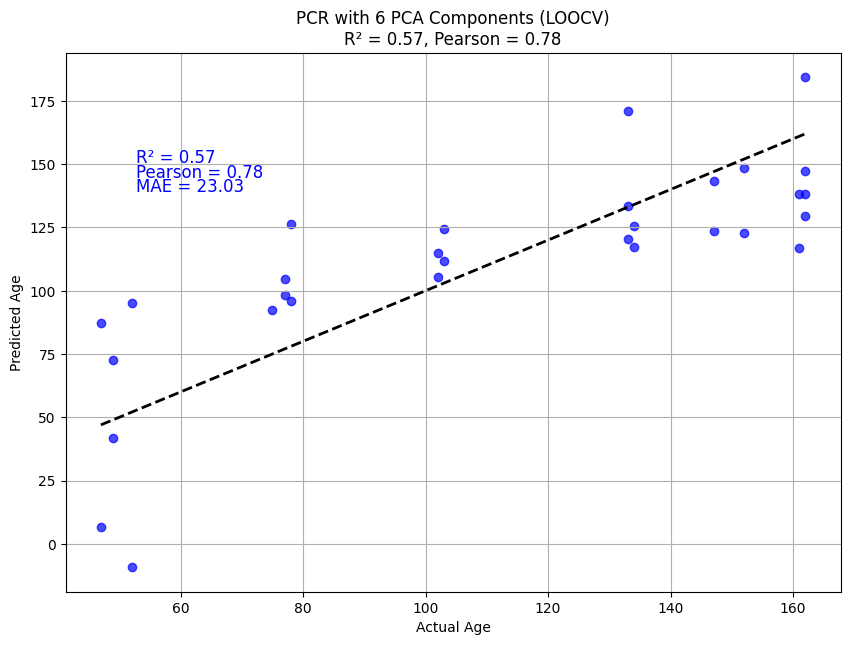


Explained Variance by Each of the First 20 Components:
Component  1: 0.2376 (Cumulative: 0.2376)
Component  2: 0.1055 (Cumulative: 0.3432)
Component  3: 0.0824 (Cumulative: 0.4255)
Component  4: 0.0693 (Cumulative: 0.4949)
Component  5: 0.0459 (Cumulative: 0.5408)
Component  6: 0.0391 (Cumulative: 0.5799)
Component  7: 0.0348 (Cumulative: 0.6146)
Component  8: 0.0285 (Cumulative: 0.6431)
Component  9: 0.0278 (Cumulative: 0.6709)
Component 10: 0.0253 (Cumulative: 0.6962)
Component 11: 0.0241 (Cumulative: 0.7203)
Component 12: 0.0209 (Cumulative: 0.7412)
Component 13: 0.0198 (Cumulative: 0.7609)
Component 14: 0.0191 (Cumulative: 0.7800)
Component 15: 0.0190 (Cumulative: 0.7990)
Component 16: 0.0179 (Cumulative: 0.8169)
Component 17: 0.0176 (Cumulative: 0.8345)
Component 18: 0.0173 (Cumulative: 0.8518)
Component 19: 0.0169 (Cumulative: 0.8687)
Component 20: 0.0166 (Cumulative: 0.8853)


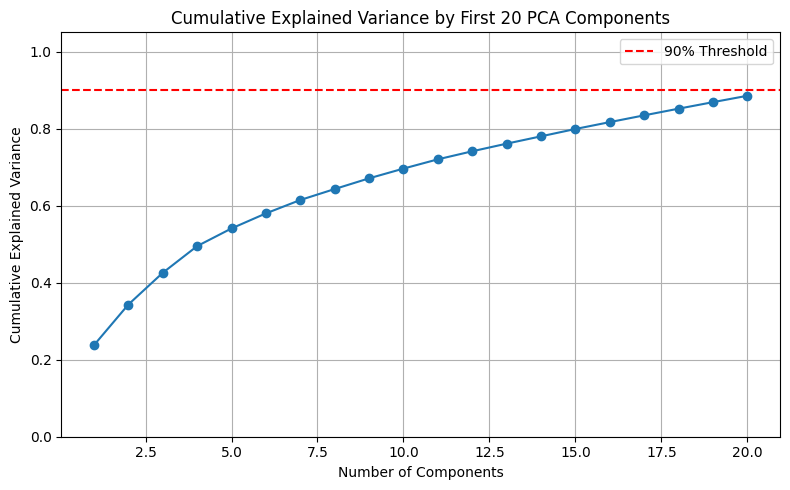

In [119]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Store results
results = []

# Loop through 1 to 20 components
for n_components in range(1, 21):
    pca = PCA(n_components=n_components, random_state=1)
    X_pca = pca.fit_transform(X_scaled)

    regressor = LinearRegression()
    y_pred = cross_val_predict(regressor, X_pca, y, cv=X.shape[0])  # LOOCV

    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    pearson_corr, _ = pearsonr(y, y_pred)

    results.append({
        'n_components': n_components,
        'mae': mae,
        'r2': r2,
        'pearson': pearson_corr,
        'y_pred': y_pred,
        'pca_model': pca
    })

    print(f"Components: {n_components:2d} | MAE: {mae:.2f} | R²: {r2:.3f} | Pearson: {pearson_corr:.3f}")

# Find the best result (lowest MAE)
best_result = min(results, key=lambda x: x['mae'])

# Unpack best model metrics
n_best = best_result['n_components']
y_pred_best = best_result['y_pred']
r2_best = best_result['r2']
pearson_best = best_result['pearson']
mae_best = best_result['mae']

# Plot predictions for the best model
plt.figure(figsize=(10, 7))
plt.scatter(y, y_pred_best, alpha=0.7, color='b')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title(f'PCR with {n_best} PCA Components (LOOCV)\nR² = {r2_best:.2f}, Pearson = {pearson_best:.2f}')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.2 * (y.max() - y.min()), f'MAE = {mae_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.1 * (y.max() - y.min()), f'R² = {r2_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.15 * (y.max() - y.min()), f'Pearson = {pearson_best:.2f}', fontsize=12, color='blue')
plt.grid(True)
plt.show()

# --- NEW: Explained variance using PCA with 20 components ---
pca_full = PCA(n_components=20, random_state=1)
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = explained_var.cumsum()

print("\nExplained Variance by Each of the First 20 Components:")
for i, (ev, cum_ev) in enumerate(zip(explained_var, cumulative_var), start=1):
    print(f"Component {i:2d}: {ev:.4f} (Cumulative: {cum_ev:.4f})")

# Optional: Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, 21), cumulative_var, marker='o', linestyle='-')
plt.title('Cumulative Explained Variance by First 20 PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.ylim(0, 1.05)
plt.grid(True)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Threshold')
plt.legend()
plt.tight_layout()
plt.show()

#### Female

In [120]:
fat_df_female = fat_df.loc[fat_df.iloc[:,-3] == "F"]

fat_df_female.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A7_2,3743.681369,269.376862,279.889130,266.748795,174.766452,482.250285,1165.547692,319.310134,448.085415,210.245356,...,84.098142,876.460328,60.445540,373.185507,1625.459408,223.385691,320.624168,F,Fat,78
B5_2,5975.375798,410.423324,424.965883,507.373716,305.393733,665.726022,1176.331417,664.110182,533.227153,365.179808,...,67.865274,1315.293645,43.627676,484.751958,1515.657787,302.162054,337.710530,F,Fat,134
B6_2,4114.594864,390.359000,168.803892,346.047978,331.277638,531.732259,915.761113,818.698875,453.660459,253.205838,...,46.421070,808.148632,71.741654,362.928367,2160.689816,238.435497,373.478611,F,Fat,133
C8_2,2433.754524,906.092062,170.712997,472.743685,490.252710,1212.500006,485.875454,1426.985566,792.283397,437.725634,...,48.149820,976.128163,91.922383,240.749099,1343.817696,56.904332,100.676896,F,Fat,47
D5_2,2991.517298,426.536185,123.926054,329.989143,232.001101,531.729231,858.836373,632.599274,479.853208,286.759124,...,70.609031,835.780363,95.106041,305.492133,2180.233946,198.858086,272.349118,F,Fat,102


In [121]:
fat_sub_df_female = fat_df_female.iloc[:,:-3]

fat_sub_df_female.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A7_2,3743.681369,269.376862,279.889130,266.748795,174.766452,482.250285,1165.547692,319.310134,448.085415,210.245356,...,240.468126,63.073607,982.897039,84.098142,876.460328,60.445540,373.185507,1625.459408,223.385691,320.624168
B5_2,5975.375798,410.423324,424.965883,507.373716,305.393733,665.726022,1176.331417,664.110182,533.227153,365.179808,...,321.552132,105.029591,1095.539424,67.865274,1315.293645,43.627676,484.751958,1515.657787,302.162054,337.710530
B6_2,4114.594864,390.359000,168.803892,346.047978,331.277638,531.732259,915.761113,818.698875,453.660459,253.205838,...,291.186713,103.392384,763.837611,46.421070,808.148632,71.741654,362.928367,2160.689816,238.435497,373.478611
C8_2,2433.754524,906.092062,170.712997,472.743685,490.252710,1212.500006,485.875454,1426.985566,792.283397,437.725634,...,48.149820,218.862817,284.521662,48.149820,976.128163,91.922383,240.749099,1343.817696,56.904332,100.676896
D5_2,2991.517298,426.536185,123.926054,329.989143,232.001101,531.729231,858.836373,632.599274,479.853208,286.759124,...,327.107142,102.311044,642.686279,70.609031,835.780363,95.106041,305.492133,2180.233946,198.858086,272.349118


In [122]:
fat_sub_df_female["age"] = fat_df_female["age_days"].tolist()

fat_sub_df_female.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A7_2,3743.681369,269.376862,279.889130,266.748795,174.766452,482.250285,1165.547692,319.310134,448.085415,210.245356,...,63.073607,982.897039,84.098142,876.460328,60.445540,373.185507,1625.459408,223.385691,320.624168,78
B5_2,5975.375798,410.423324,424.965883,507.373716,305.393733,665.726022,1176.331417,664.110182,533.227153,365.179808,...,105.029591,1095.539424,67.865274,1315.293645,43.627676,484.751958,1515.657787,302.162054,337.710530,134
B6_2,4114.594864,390.359000,168.803892,346.047978,331.277638,531.732259,915.761113,818.698875,453.660459,253.205838,...,103.392384,763.837611,46.421070,808.148632,71.741654,362.928367,2160.689816,238.435497,373.478611,133
C8_2,2433.754524,906.092062,170.712997,472.743685,490.252710,1212.500006,485.875454,1426.985566,792.283397,437.725634,...,218.862817,284.521662,48.149820,976.128163,91.922383,240.749099,1343.817696,56.904332,100.676896,47
D5_2,2991.517298,426.536185,123.926054,329.989143,232.001101,531.729231,858.836373,632.599274,479.853208,286.759124,...,102.311044,642.686279,70.609031,835.780363,95.106041,305.492133,2180.233946,198.858086,272.349118,102


In [123]:
fat_data_female = fat_sub_df_female.values

In [124]:
X, y = fat_data_female[:,:-1], fat_data_female[:,-1]

Components:  1 | MAE: 35.12 | R²: -0.131 | Pearson: -0.205
Components:  2 | MAE: 27.07 | R²: 0.052 | Pearson: 0.529
Components:  3 | MAE: 19.37 | R²: 0.606 | Pearson: 0.789
Components:  4 | MAE: 19.90 | R²: 0.567 | Pearson: 0.784
Components:  5 | MAE: 21.12 | R²: 0.534 | Pearson: 0.769
Components:  6 | MAE: 23.02 | R²: 0.484 | Pearson: 0.747
Components:  7 | MAE: 26.30 | R²: 0.277 | Pearson: 0.679
Components:  8 | MAE: 33.11 | R²: -0.321 | Pearson: 0.623
Components:  9 | MAE: 37.27 | R²: -0.565 | Pearson: 0.550
Components: 10 | MAE: 28.87 | R²: -0.207 | Pearson: 0.609
Components: 11 | MAE: 28.11 | R²: -0.245 | Pearson: 0.625
Components: 12 | MAE: 53.65 | R²: -4.482 | Pearson: 0.368
Components: 13 | MAE: 44.61 | R²: -2.057 | Pearson: 0.551
Components: 14 | MAE: 44.77 | R²: -1.833 | Pearson: 0.421
Components: 15 | MAE: 54.55 | R²: -4.046 | Pearson: 0.393
Components: 16 | MAE: 67.34 | R²: -5.547 | Pearson: 0.432
Components: 17 | MAE: 85.75 | R²: -8.429 | Pearson: 0.365
Components: 18 | MA

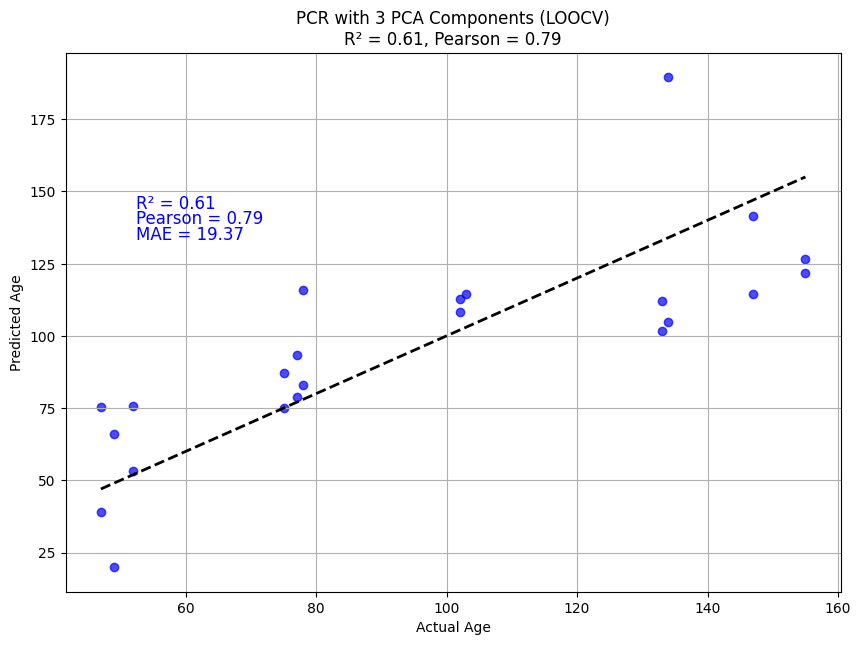


Explained Variance by Each of the First 20 Components:
Component  1: 0.2403 (Cumulative: 0.2403)
Component  2: 0.1390 (Cumulative: 0.3793)
Component  3: 0.0833 (Cumulative: 0.4626)
Component  4: 0.0543 (Cumulative: 0.5169)
Component  5: 0.0526 (Cumulative: 0.5694)
Component  6: 0.0491 (Cumulative: 0.6185)
Component  7: 0.0417 (Cumulative: 0.6602)
Component  8: 0.0395 (Cumulative: 0.6997)
Component  9: 0.0344 (Cumulative: 0.7341)
Component 10: 0.0278 (Cumulative: 0.7619)
Component 11: 0.0258 (Cumulative: 0.7877)
Component 12: 0.0251 (Cumulative: 0.8128)
Component 13: 0.0229 (Cumulative: 0.8357)
Component 14: 0.0221 (Cumulative: 0.8578)
Component 15: 0.0206 (Cumulative: 0.8785)
Component 16: 0.0200 (Cumulative: 0.8984)
Component 17: 0.0186 (Cumulative: 0.9171)
Component 18: 0.0182 (Cumulative: 0.9353)
Component 19: 0.0171 (Cumulative: 0.9524)
Component 20: 0.0167 (Cumulative: 0.9691)


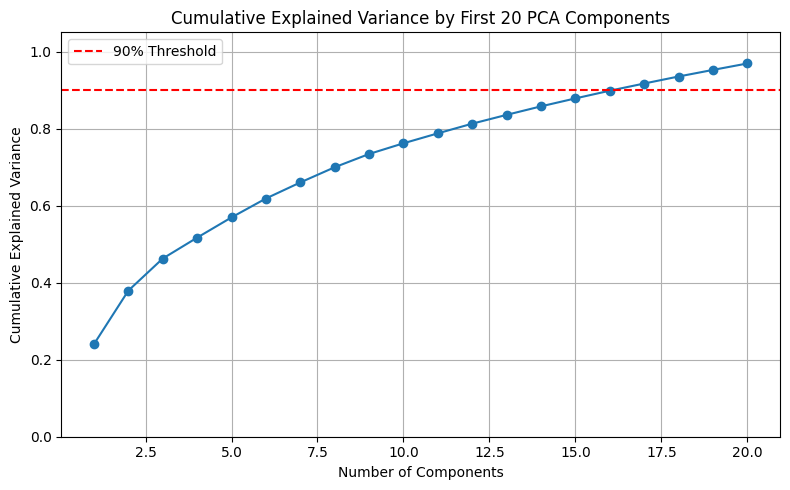

In [125]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Store results
results = []

# Loop through 1 to 20 components
for n_components in range(1, 21):
    pca = PCA(n_components=n_components, random_state=1)
    X_pca = pca.fit_transform(X_scaled)

    regressor = LinearRegression()
    y_pred = cross_val_predict(regressor, X_pca, y, cv=X.shape[0])  # LOOCV

    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    pearson_corr, _ = pearsonr(y, y_pred)

    results.append({
        'n_components': n_components,
        'mae': mae,
        'r2': r2,
        'pearson': pearson_corr,
        'y_pred': y_pred,
        'pca_model': pca
    })

    print(f"Components: {n_components:2d} | MAE: {mae:.2f} | R²: {r2:.3f} | Pearson: {pearson_corr:.3f}")

# Find the best result (lowest MAE)
best_result = min(results, key=lambda x: x['mae'])

# Unpack best model metrics
n_best = best_result['n_components']
y_pred_best = best_result['y_pred']
r2_best = best_result['r2']
pearson_best = best_result['pearson']
mae_best = best_result['mae']

# Plot predictions for the best model
plt.figure(figsize=(10, 7))
plt.scatter(y, y_pred_best, alpha=0.7, color='b')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title(f'PCR with {n_best} PCA Components (LOOCV)\nR² = {r2_best:.2f}, Pearson = {pearson_best:.2f}')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.2 * (y.max() - y.min()), f'MAE = {mae_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.1 * (y.max() - y.min()), f'R² = {r2_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.15 * (y.max() - y.min()), f'Pearson = {pearson_best:.2f}', fontsize=12, color='blue')
plt.grid(True)
plt.show()

# --- NEW: Explained variance using PCA with 20 components ---
pca_full = PCA(n_components=20, random_state=1)
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = explained_var.cumsum()

print("\nExplained Variance by Each of the First 20 Components:")
for i, (ev, cum_ev) in enumerate(zip(explained_var, cumulative_var), start=1):
    print(f"Component {i:2d}: {ev:.4f} (Cumulative: {cum_ev:.4f})")

# Optional: Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, 21), cumulative_var, marker='o', linestyle='-')
plt.title('Cumulative Explained Variance by First 20 PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.ylim(0, 1.05)
plt.grid(True)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Threshold')
plt.legend()
plt.tight_layout()
plt.show()

# Bone

In [126]:
bone_df = combined_df.loc[combined_df.iloc[:,-2] == "Bone"]

bone_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A1_2,36.845369,407.384647,349.683408,374.015256,493.588906,469.257059,963.541161,1619.805848,453.962755,449.791581,...,107.060129,777.923924,19.465478,672.254187,2691.797529,191.873997,253.746410,M,Bone,78
A2_2,20.777004,442.878244,147.626081,246.043469,347.741436,461.468195,1131.799958,2439.657687,538.015052,407.885395,...,86.388596,600.346065,18.589951,461.468195,2926.276993,346.647910,331.338538,M,Bone,133
A3_2,2689.339698,509.924698,228.124207,424.674129,254.172992,471.246199,1022.217467,1155.618819,357.578774,475.192984,...,87.618640,858.031186,67.884712,356.000060,1692.381659,211.547707,330.740632,F,Bone,102
A4_2,22.871884,461.415405,139.220165,452.465537,327.167388,432.576942,622.513025,1147.571934,618.535306,353.022562,...,175.019636,540.969785,50.715917,401.749620,2937.545488,133.253587,179.991785,M,Bone,77
B1_2,2192.314285,358.300673,188.259675,432.389964,368.017301,556.276976,804.051001,1699.195393,572.066498,364.373565,...,25.506150,517.410463,104.453755,593.928912,2108.508365,102.024598,224.697032,M,Bone,134


In [127]:
bone_df_male = bone_df.loc[bone_df.iloc[:,-3] == "M"]

bone_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A1_2,36.845369,407.384647,349.683408,374.015256,493.588906,469.257059,963.541161,1619.805848,453.962755,449.791581,...,107.060129,777.923924,19.465478,672.254187,2691.797529,191.873997,253.746410,M,Bone,78
A2_2,20.777004,442.878244,147.626081,246.043469,347.741436,461.468195,1131.799958,2439.657687,538.015052,407.885395,...,86.388596,600.346065,18.589951,461.468195,2926.276993,346.647910,331.338538,M,Bone,133
A4_2,22.871884,461.415405,139.220165,452.465537,327.167388,432.576942,622.513025,1147.571934,618.535306,353.022562,...,175.019636,540.969785,50.715917,401.749620,2937.545488,133.253587,179.991785,M,Bone,77
B1_2,2192.314285,358.300673,188.259675,432.389964,368.017301,556.276976,804.051001,1699.195393,572.066498,364.373565,...,25.506150,517.410463,104.453755,593.928912,2108.508365,102.024598,224.697032,M,Bone,134
B2_2,763.395427,433.326190,161.504466,608.068727,387.434211,537.465682,879.890451,1461.483036,422.735733,447.446799,...,73.250659,702.500300,74.133197,679.554310,3687.244037,300.062942,347.719998,M,Bone,152


In [128]:
bone_sub_df_male = bone_df_male.iloc[:,:-3]
bone_sub_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A1_2,36.845369,407.384647,349.683408,374.015256,493.588906,469.257059,963.541161,1619.805848,453.962755,449.791581,...,774.447946,64.653195,670.168600,107.060129,777.923924,19.465478,672.254187,2691.797529,191.873997,253.746410
A2_2,20.777004,442.878244,147.626081,246.043469,347.741436,461.468195,1131.799958,2439.657687,538.015052,407.885395,...,898.878807,73.266277,598.159012,86.388596,600.346065,18.589951,461.468195,2926.276993,346.647910,331.338538
A4_2,22.871884,461.415405,139.220165,452.465537,327.167388,432.576942,622.513025,1147.571934,618.535306,353.022562,...,435.560231,50.715917,875.098182,175.019636,540.969785,50.715917,401.749620,2937.545488,133.253587,179.991785
B1_2,2192.314285,358.300673,188.259675,432.389964,368.017301,556.276976,804.051001,1699.195393,572.066498,364.373565,...,702.026403,111.741227,947.371270,25.506150,517.410463,104.453755,593.928912,2108.508365,102.024598,224.697032
B2_2,763.395427,433.326190,161.504466,608.068727,387.434211,537.465682,879.890451,1461.483036,422.735733,447.446799,...,725.446290,70.603045,861.357152,73.250659,702.500300,74.133197,679.554310,3687.244037,300.062942,347.719998


In [129]:
bone_sub_df_male["age"] = bone_df_male["age_days"].tolist()

bone_sub_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A1_2,36.845369,407.384647,349.683408,374.015256,493.588906,469.257059,963.541161,1619.805848,453.962755,449.791581,...,64.653195,670.168600,107.060129,777.923924,19.465478,672.254187,2691.797529,191.873997,253.746410,78
A2_2,20.777004,442.878244,147.626081,246.043469,347.741436,461.468195,1131.799958,2439.657687,538.015052,407.885395,...,73.266277,598.159012,86.388596,600.346065,18.589951,461.468195,2926.276993,346.647910,331.338538,133
A4_2,22.871884,461.415405,139.220165,452.465537,327.167388,432.576942,622.513025,1147.571934,618.535306,353.022562,...,50.715917,875.098182,175.019636,540.969785,50.715917,401.749620,2937.545488,133.253587,179.991785,77
B1_2,2192.314285,358.300673,188.259675,432.389964,368.017301,556.276976,804.051001,1699.195393,572.066498,364.373565,...,111.741227,947.371270,25.506150,517.410463,104.453755,593.928912,2108.508365,102.024598,224.697032,134
B2_2,763.395427,433.326190,161.504466,608.068727,387.434211,537.465682,879.890451,1461.483036,422.735733,447.446799,...,70.603045,861.357152,73.250659,702.500300,74.133197,679.554310,3687.244037,300.062942,347.719998,152


In [130]:
bone_data_male = bone_sub_df_male.values

In [131]:
X, y = bone_data_male[:,:-1], bone_data_male[:,-1]

Components:  1 | MAE: 37.78 | R²: 0.002 | Pearson: 0.190
Components:  2 | MAE: 39.16 | R²: -0.044 | Pearson: 0.148
Components:  3 | MAE: 39.10 | R²: -0.061 | Pearson: 0.189
Components:  4 | MAE: 37.19 | R²: -0.006 | Pearson: 0.301
Components:  5 | MAE: 38.28 | R²: -0.071 | Pearson: 0.251
Components:  6 | MAE: 40.39 | R²: -0.224 | Pearson: 0.163
Components:  7 | MAE: 39.52 | R²: -0.174 | Pearson: 0.238
Components:  8 | MAE: 42.39 | R²: -0.635 | Pearson: 0.382
Components:  9 | MAE: 38.70 | R²: -0.321 | Pearson: 0.536
Components: 10 | MAE: 45.10 | R²: -0.962 | Pearson: 0.486
Components: 11 | MAE: 30.97 | R²: 0.109 | Pearson: 0.683
Components: 12 | MAE: 29.80 | R²: 0.178 | Pearson: 0.673
Components: 13 | MAE: 31.35 | R²: -0.048 | Pearson: 0.662
Components: 14 | MAE: 38.53 | R²: -0.651 | Pearson: 0.607
Components: 15 | MAE: 43.96 | R²: -1.049 | Pearson: 0.558
Components: 16 | MAE: 46.52 | R²: -1.334 | Pearson: 0.510
Components: 17 | MAE: 60.03 | R²: -4.913 | Pearson: 0.419
Components: 18 | 

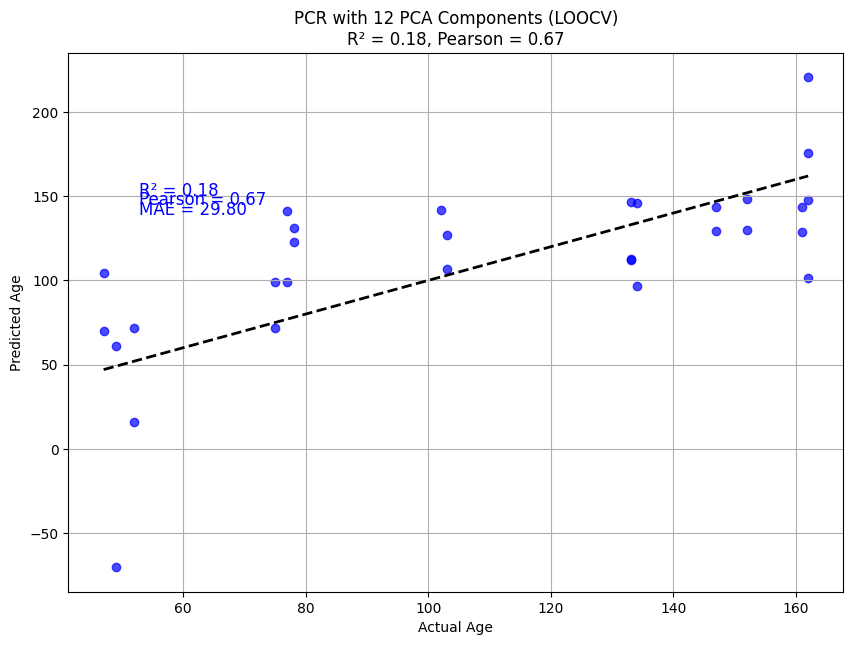


Explained Variance by Each of the First 20 Components:
Component  1: 0.1793 (Cumulative: 0.1793)
Component  2: 0.1028 (Cumulative: 0.2821)
Component  3: 0.0883 (Cumulative: 0.3704)
Component  4: 0.0726 (Cumulative: 0.4430)
Component  5: 0.0614 (Cumulative: 0.5044)
Component  6: 0.0556 (Cumulative: 0.5600)
Component  7: 0.0459 (Cumulative: 0.6060)
Component  8: 0.0391 (Cumulative: 0.6450)
Component  9: 0.0341 (Cumulative: 0.6791)
Component 10: 0.0320 (Cumulative: 0.7111)
Component 11: 0.0277 (Cumulative: 0.7388)
Component 12: 0.0253 (Cumulative: 0.7641)
Component 13: 0.0219 (Cumulative: 0.7860)
Component 14: 0.0212 (Cumulative: 0.8072)
Component 15: 0.0198 (Cumulative: 0.8270)
Component 16: 0.0193 (Cumulative: 0.8463)
Component 17: 0.0185 (Cumulative: 0.8649)
Component 18: 0.0169 (Cumulative: 0.8818)
Component 19: 0.0148 (Cumulative: 0.8966)
Component 20: 0.0139 (Cumulative: 0.9105)


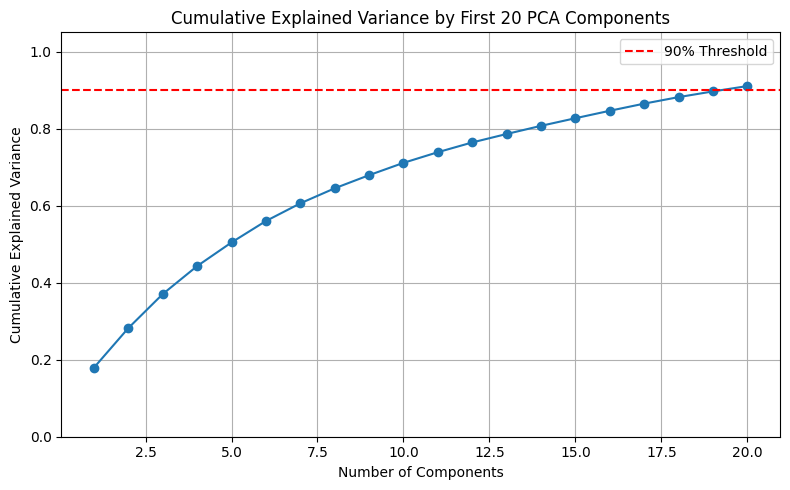

In [132]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Store results
results = []

# Loop through 1 to 20 components
for n_components in range(1, 21):
    pca = PCA(n_components=n_components, random_state=1)
    X_pca = pca.fit_transform(X_scaled)

    regressor = LinearRegression()
    y_pred = cross_val_predict(regressor, X_pca, y, cv=X.shape[0])  # LOOCV

    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    pearson_corr, _ = pearsonr(y, y_pred)

    results.append({
        'n_components': n_components,
        'mae': mae,
        'r2': r2,
        'pearson': pearson_corr,
        'y_pred': y_pred,
        'pca_model': pca
    })

    print(f"Components: {n_components:2d} | MAE: {mae:.2f} | R²: {r2:.3f} | Pearson: {pearson_corr:.3f}")

# Find the best result (lowest MAE)
best_result = min(results, key=lambda x: x['mae'])

# Unpack best model metrics
n_best = best_result['n_components']
y_pred_best = best_result['y_pred']
r2_best = best_result['r2']
pearson_best = best_result['pearson']
mae_best = best_result['mae']

# Plot predictions for the best model
plt.figure(figsize=(10, 7))
plt.scatter(y, y_pred_best, alpha=0.7, color='b')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title(f'PCR with {n_best} PCA Components (LOOCV)\nR² = {r2_best:.2f}, Pearson = {pearson_best:.2f}')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.2 * (y.max() - y.min()), f'MAE = {mae_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.1 * (y.max() - y.min()), f'R² = {r2_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.15 * (y.max() - y.min()), f'Pearson = {pearson_best:.2f}', fontsize=12, color='blue')
plt.grid(True)
plt.show()

# --- NEW: Explained variance using PCA with 20 components ---
pca_full = PCA(n_components=20, random_state=1)
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = explained_var.cumsum()

print("\nExplained Variance by Each of the First 20 Components:")
for i, (ev, cum_ev) in enumerate(zip(explained_var, cumulative_var), start=1):
    print(f"Component {i:2d}: {ev:.4f} (Cumulative: {cum_ev:.4f})")

# Optional: Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, 21), cumulative_var, marker='o', linestyle='-')
plt.title('Cumulative Explained Variance by First 20 PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.ylim(0, 1.05)
plt.grid(True)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Threshold')
plt.legend()
plt.tight_layout()
plt.show()

#### Female

In [133]:
bone_df_female = bone_df.loc[bone_df.iloc[:,-3] == "F"]

bone_df_female.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A3_2,2689.339698,509.924698,228.124207,424.674129,254.172992,471.246199,1022.217467,1155.618819,357.578774,475.192984,...,87.618640,858.031186,67.884712,356.000060,1692.381659,211.547707,330.740632,F,Bone,102
C3_2,114.608374,593.671377,289.386144,424.624025,536.367190,503.130761,946.092126,1316.277174,558.142781,547.254985,...,73.349359,684.785034,78.506736,497.973385,2954.030837,259.587967,268.183595,F,Bone,155
C4_2,298.910593,455.393567,362.628211,336.391545,312.965950,351.383926,1048.529634,582.828804,364.502259,380.431663,...,92.765356,596.884162,53.410357,720.571303,1555.459510,277.359045,288.603331,F,Bone,49
D2_2,26.262471,418.388329,321.488868,354.090556,538.833454,668.334604,888.395998,1410.023006,614.904060,465.479656,...,83.315425,727.198763,65.203376,482.686103,1790.376033,259.907902,335.978507,F,Bone,75
E2_2,739.966763,739.357737,236.911169,275.888843,460.423764,504.882672,723.523057,547.514502,637.041345,568.830417,...,54.203327,964.088383,152.256536,285.024235,2182.140668,274.061764,244.219483,F,Bone,47


In [134]:
bone_sub_df_female = bone_df_female.iloc[:,:-3]

bone_sub_df_female.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A3_2,2689.339698,509.924698,228.124207,424.674129,254.172992,471.246199,1022.217467,1155.618819,357.578774,475.192984,...,419.148629,131.822639,958.279540,87.618640,858.031186,67.884712,356.000060,1692.381659,211.547707,330.740632
C3_2,114.608374,593.671377,289.386144,424.624025,536.367190,503.130761,946.092126,1316.277174,558.142781,547.254985,...,741.516179,134.091797,700.257164,73.349359,684.785034,78.506736,497.973385,2954.030837,259.587967,268.183595
C4_2,298.910593,455.393567,362.628211,336.391545,312.965950,351.383926,1048.529634,582.828804,364.502259,380.431663,...,1271.541299,67.465714,963.260468,92.765356,596.884162,53.410357,720.571303,1555.459510,277.359045,288.603331
D2_2,26.262471,418.388329,321.488868,354.090556,538.833454,668.334604,888.395998,1410.023006,614.904060,465.479656,...,870.283949,102.333076,683.729846,83.315425,727.198763,65.203376,482.686103,1790.376033,259.907902,335.978507
E2_2,739.966763,739.357737,236.911169,275.888843,460.423764,504.882672,723.523057,547.514502,637.041345,568.830417,...,827.666528,123.632307,617.552508,54.203327,964.088383,152.256536,285.024235,2182.140668,274.061764,244.219483


In [135]:
bone_sub_df_female["age"] = bone_df_female["age_days"].tolist()

bone_sub_df_female.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A3_2,2689.339698,509.924698,228.124207,424.674129,254.172992,471.246199,1022.217467,1155.618819,357.578774,475.192984,...,131.822639,958.279540,87.618640,858.031186,67.884712,356.000060,1692.381659,211.547707,330.740632,102
C3_2,114.608374,593.671377,289.386144,424.624025,536.367190,503.130761,946.092126,1316.277174,558.142781,547.254985,...,134.091797,700.257164,73.349359,684.785034,78.506736,497.973385,2954.030837,259.587967,268.183595,155
C4_2,298.910593,455.393567,362.628211,336.391545,312.965950,351.383926,1048.529634,582.828804,364.502259,380.431663,...,67.465714,963.260468,92.765356,596.884162,53.410357,720.571303,1555.459510,277.359045,288.603331,49
D2_2,26.262471,418.388329,321.488868,354.090556,538.833454,668.334604,888.395998,1410.023006,614.904060,465.479656,...,102.333076,683.729846,83.315425,727.198763,65.203376,482.686103,1790.376033,259.907902,335.978507,75
E2_2,739.966763,739.357737,236.911169,275.888843,460.423764,504.882672,723.523057,547.514502,637.041345,568.830417,...,123.632307,617.552508,54.203327,964.088383,152.256536,285.024235,2182.140668,274.061764,244.219483,47


In [136]:
bone_data_female = bone_sub_df_female.values

In [137]:
X, y = bone_data_female[:,:-1], bone_data_female[:,-1]

Components:  1 | MAE: 37.26 | R²: -0.224 | Pearson: -0.539
Components:  2 | MAE: 40.57 | R²: -0.495 | Pearson: -0.629


Components:  3 | MAE: 42.77 | R²: -0.657 | Pearson: -0.704
Components:  4 | MAE: 43.05 | R²: -0.667 | Pearson: -0.536
Components:  5 | MAE: 34.05 | R²: -0.204 | Pearson: 0.185
Components:  6 | MAE: 38.47 | R²: -0.532 | Pearson: 0.131
Components:  7 | MAE: 26.37 | R²: 0.054 | Pearson: 0.565
Components:  8 | MAE: 29.30 | R²: -0.169 | Pearson: 0.491
Components:  9 | MAE: 33.10 | R²: -0.428 | Pearson: 0.425
Components: 10 | MAE: 45.84 | R²: -1.922 | Pearson: 0.424
Components: 11 | MAE: 47.35 | R²: -1.843 | Pearson: 0.417
Components: 12 | MAE: 50.76 | R²: -2.600 | Pearson: 0.358
Components: 13 | MAE: 63.18 | R²: -5.132 | Pearson: 0.253
Components: 14 | MAE: 57.46 | R²: -3.146 | Pearson: 0.397
Components: 15 | MAE: 73.65 | R²: -5.277 | Pearson: 0.332
Components: 16 | MAE: 83.71 | R²: -5.925 | Pearson: 0.386
Components: 17 | MAE: 127.86 | R²: -19.878 | Pearson: 0.222
Components: 18 | MAE: 146.39 | R²: -21.048 | Pearson: 0.524
Components: 19 | MAE: 431.57 | R²: -391.361 | Pearson: 0.047
Compon

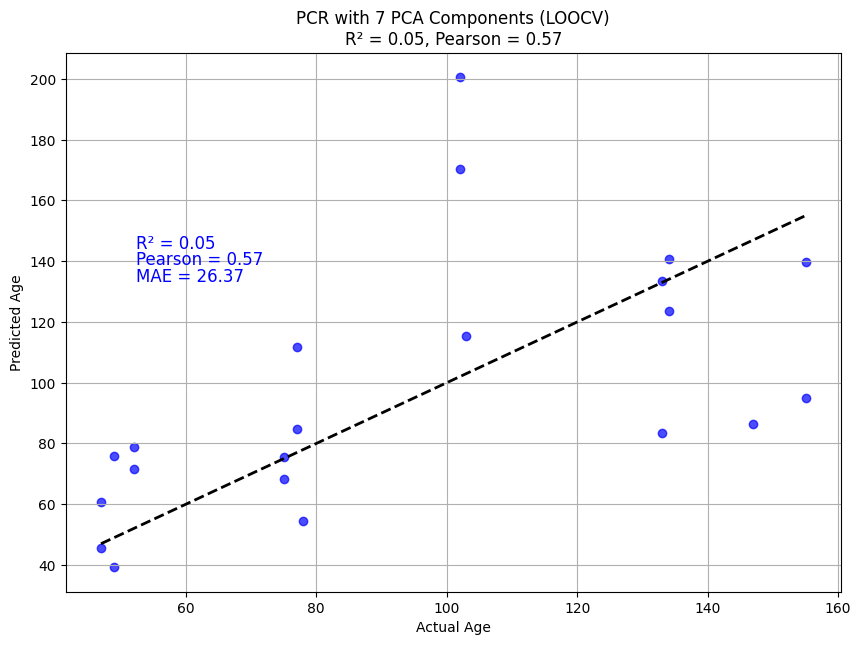


Explained Variance by Each of the First 20 Components:
Component  1: 0.1500 (Cumulative: 0.1500)
Component  2: 0.1241 (Cumulative: 0.2741)
Component  3: 0.1123 (Cumulative: 0.3864)
Component  4: 0.0794 (Cumulative: 0.4658)
Component  5: 0.0632 (Cumulative: 0.5290)
Component  6: 0.0549 (Cumulative: 0.5839)
Component  7: 0.0509 (Cumulative: 0.6348)
Component  8: 0.0471 (Cumulative: 0.6820)
Component  9: 0.0459 (Cumulative: 0.7278)
Component 10: 0.0396 (Cumulative: 0.7674)
Component 11: 0.0342 (Cumulative: 0.8016)
Component 12: 0.0316 (Cumulative: 0.8332)
Component 13: 0.0269 (Cumulative: 0.8601)
Component 14: 0.0245 (Cumulative: 0.8846)
Component 15: 0.0242 (Cumulative: 0.9088)
Component 16: 0.0227 (Cumulative: 0.9315)
Component 17: 0.0204 (Cumulative: 0.9520)
Component 18: 0.0181 (Cumulative: 0.9701)
Component 19: 0.0164 (Cumulative: 0.9865)
Component 20: 0.0135 (Cumulative: 1.0000)


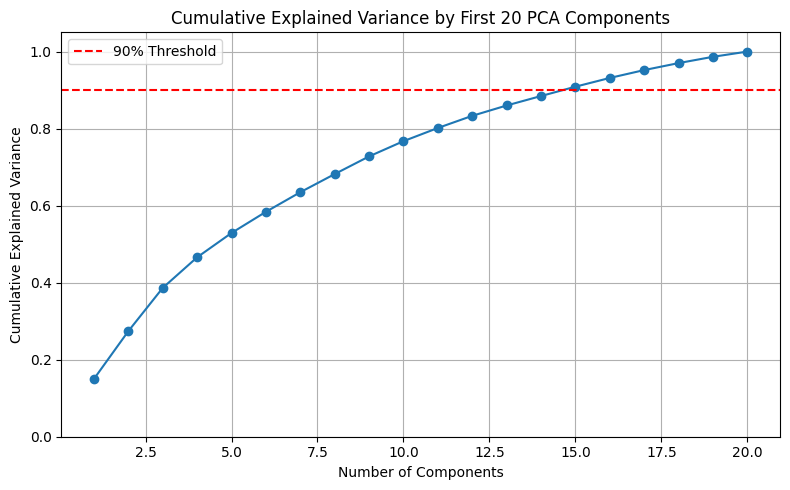

In [138]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Store results
results = []

# Loop through 1 to 20 components
for n_components in range(1, 21):
    pca = PCA(n_components=n_components, random_state=1)
    X_pca = pca.fit_transform(X_scaled)

    regressor = LinearRegression()
    y_pred = cross_val_predict(regressor, X_pca, y, cv=X.shape[0])  # LOOCV

    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    pearson_corr, _ = pearsonr(y, y_pred)

    results.append({
        'n_components': n_components,
        'mae': mae,
        'r2': r2,
        'pearson': pearson_corr,
        'y_pred': y_pred,
        'pca_model': pca
    })

    print(f"Components: {n_components:2d} | MAE: {mae:.2f} | R²: {r2:.3f} | Pearson: {pearson_corr:.3f}")

# Find the best result (lowest MAE)
best_result = min(results, key=lambda x: x['mae'])

# Unpack best model metrics
n_best = best_result['n_components']
y_pred_best = best_result['y_pred']
r2_best = best_result['r2']
pearson_best = best_result['pearson']
mae_best = best_result['mae']

# Plot predictions for the best model
plt.figure(figsize=(10, 7))
plt.scatter(y, y_pred_best, alpha=0.7, color='b')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title(f'PCR with {n_best} PCA Components (LOOCV)\nR² = {r2_best:.2f}, Pearson = {pearson_best:.2f}')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.2 * (y.max() - y.min()), f'MAE = {mae_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.1 * (y.max() - y.min()), f'R² = {r2_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.15 * (y.max() - y.min()), f'Pearson = {pearson_best:.2f}', fontsize=12, color='blue')
plt.grid(True)
plt.show()

# --- NEW: Explained variance using PCA with 20 components ---
pca_full = PCA(n_components=20, random_state=1)
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = explained_var.cumsum()

print("\nExplained Variance by Each of the First 20 Components:")
for i, (ev, cum_ev) in enumerate(zip(explained_var, cumulative_var), start=1):
    print(f"Component {i:2d}: {ev:.4f} (Cumulative: {cum_ev:.4f})")

# Optional: Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, 21), cumulative_var, marker='o', linestyle='-')
plt.title('Cumulative Explained Variance by First 20 PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.ylim(0, 1.05)
plt.grid(True)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Threshold')
plt.legend()
plt.tight_layout()
plt.show()

# Eye

In [139]:
eye_df = combined_df.loc[combined_df.iloc[:,-2] == "Eye"]

eye_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
I12_2,13.005389,463.464767,712.931771,812.245650,95.766954,668.004064,3055.084074,1345.466593,1112.551901,611.253276,...,242.373156,509.574782,31.922318,1062.894962,786.234872,200.992373,516.668630,M,Eye,47
I16_2,5.068039,355.776306,680.130774,867.648200,92.238302,642.627288,2904.999697,1141.322282,948.736817,580.797218,...,337.531367,531.130440,49.666778,1061.247273,1059.220057,188.531034,490.586132,M,Eye,147
I20_2,20.535311,531.502170,858.859189,1075.083935,160.658611,1063.004341,2765.019245,1606.586106,1120.986396,950.664109,...,378.091317,682.497105,22.951230,822.620405,718.735889,80.933285,397.418668,M,Eye,78
I4_2,15.386990,386.484981,886.109592,859.861198,109.519163,629.961467,3569.781647,1411.982599,1011.920862,604.618190,...,244.381604,510.486016,26.248394,943.131967,1116.914440,115.854982,492.383675,F,Eye,103
I8_2,12.334831,532.640416,1043.975216,1095.557235,133.440441,821.948264,3856.316615,1303.006661,1168.444871,788.307816,...,316.220205,512.456148,43.732582,990.150500,729.997708,124.469655,420.505592,F,Eye,78


In [140]:
eye_df_male = eye_df.loc[eye_df.iloc[:,-3] == "M"]

eye_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
I12_2,13.005389,463.464767,712.931771,812.245650,95.766954,668.004064,3055.084074,1345.466593,1112.551901,611.253276,...,242.373156,509.574782,31.922318,1062.894962,786.234872,200.992373,516.668630,M,Eye,47
I16_2,5.068039,355.776306,680.130774,867.648200,92.238302,642.627288,2904.999697,1141.322282,948.736817,580.797218,...,337.531367,531.130440,49.666778,1061.247273,1059.220057,188.531034,490.586132,M,Eye,147
I20_2,20.535311,531.502170,858.859189,1075.083935,160.658611,1063.004341,2765.019245,1606.586106,1120.986396,950.664109,...,378.091317,682.497105,22.951230,822.620405,718.735889,80.933285,397.418668,M,Eye,78
J12_2,19.377526,439.563875,617.021217,950.518635,96.887629,742.465200,1914.295577,606.822519,705.749888,485.458015,...,311.060283,666.994836,27.536484,1098.399753,925.021891,137.682420,661.895487,M,Eye,103
J20_2,13.585083,473.666574,770.727063,820.539036,90.567222,678.348496,3365.477987,1110.354147,862.199958,532.535268,...,252.682551,605.894718,8.151050,812.387986,843.180841,192.908184,518.950185,M,Eye,147


In [141]:
eye_sub_df_male = eye_df_male.iloc[:,:-3]
eye_sub_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
I12_2,13.005389,463.464767,712.931771,812.245650,95.766954,668.004064,3055.084074,1345.466593,1112.551901,611.253276,...,1033.337260,295.577020,1254.428871,242.373156,509.574782,31.922318,1062.894962,786.234872,200.992373,516.668630
I16_2,5.068039,355.776306,680.130774,867.648200,92.238302,642.627288,2904.999697,1141.322282,948.736817,580.797218,...,1093.682719,266.578828,969.008971,337.531367,531.130440,49.666778,1061.247273,1059.220057,188.531034,490.586132
I20_2,20.535311,531.502170,858.859189,1075.083935,160.658611,1063.004341,2765.019245,1606.586106,1120.986396,950.664109,...,623.307091,353.932127,756.182633,378.091317,682.497105,22.951230,822.620405,718.735889,80.933285,397.418668
J12_2,19.377526,439.563875,617.021217,950.518635,96.887629,742.465200,1914.295577,606.822519,705.749888,485.458015,...,1073.922879,139.722160,1436.996520,311.060283,666.994836,27.536484,1098.399753,925.021891,137.682420,661.895487
J20_2,13.585083,473.666574,770.727063,820.539036,90.567222,678.348496,3365.477987,1110.354147,862.199958,532.535268,...,1120.316542,222.795367,1256.167376,252.682551,605.894718,8.151050,812.387986,843.180841,192.908184,518.950185


In [142]:
eye_sub_df_male["age"] = eye_df_male["age_days"].tolist()

eye_sub_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
I12_2,13.005389,463.464767,712.931771,812.245650,95.766954,668.004064,3055.084074,1345.466593,1112.551901,611.253276,...,295.577020,1254.428871,242.373156,509.574782,31.922318,1062.894962,786.234872,200.992373,516.668630,47
I16_2,5.068039,355.776306,680.130774,867.648200,92.238302,642.627288,2904.999697,1141.322282,948.736817,580.797218,...,266.578828,969.008971,337.531367,531.130440,49.666778,1061.247273,1059.220057,188.531034,490.586132,147
I20_2,20.535311,531.502170,858.859189,1075.083935,160.658611,1063.004341,2765.019245,1606.586106,1120.986396,950.664109,...,353.932127,756.182633,378.091317,682.497105,22.951230,822.620405,718.735889,80.933285,397.418668,78
J12_2,19.377526,439.563875,617.021217,950.518635,96.887629,742.465200,1914.295577,606.822519,705.749888,485.458015,...,139.722160,1436.996520,311.060283,666.994836,27.536484,1098.399753,925.021891,137.682420,661.895487,103
J20_2,13.585083,473.666574,770.727063,820.539036,90.567222,678.348496,3365.477987,1110.354147,862.199958,532.535268,...,222.795367,1256.167376,252.682551,605.894718,8.151050,812.387986,843.180841,192.908184,518.950185,147


In [143]:
eye_data_male = eye_sub_df_male.values

In [144]:
X, y = eye_data_male[:,:-1], eye_data_male[:,-1]

Components:  1 | MAE: 33.18 | R²: 0.003 | Pearson: 0.206
Components:  2 | MAE: 35.84 | R²: -0.173 | Pearson: 0.150
Components:  3 | MAE: 30.29 | R²: -0.213 | Pearson: 0.577
Components:  4 | MAE: 31.02 | R²: -0.288 | Pearson: 0.550
Components:  5 | MAE: 34.12 | R²: -0.609 | Pearson: 0.520
Components:  6 | MAE: 30.06 | R²: -0.350 | Pearson: 0.554
Components:  7 | MAE: 31.41 | R²: -0.531 | Pearson: 0.538
Components:  8 | MAE: 31.91 | R²: -0.407 | Pearson: 0.592
Components:  9 | MAE: 38.03 | R²: -0.831 | Pearson: 0.523
Components: 10 | MAE: 42.79 | R²: -1.830 | Pearson: 0.490
Components: 11 | MAE: 37.95 | R²: -1.768 | Pearson: 0.554
Components: 12 | MAE: 47.78 | R²: -2.426 | Pearson: 0.560
Components: 13 | MAE: 48.63 | R²: -2.546 | Pearson: 0.611
Components: 14 | MAE: 52.79 | R²: -2.825 | Pearson: 0.586
Components: 15 | MAE: 58.89 | R²: -3.675 | Pearson: 0.605
Components: 16 | MAE: 70.47 | R²: -5.778 | Pearson: 0.565
Components: 17 | MAE: 83.12 | R²: -10.578 | Pearson: 0.368
Components: 18

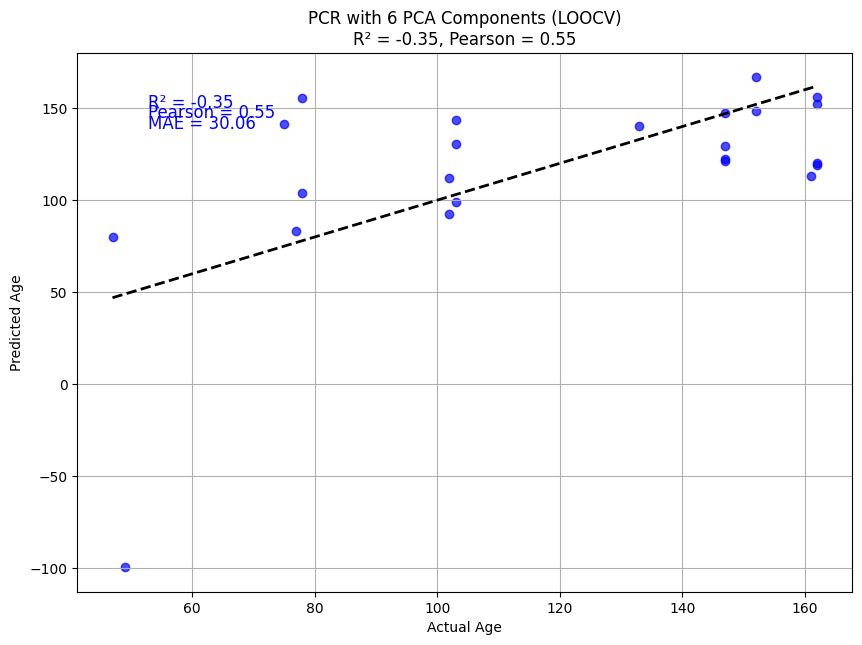


Explained Variance by Each of the First 20 Components:
Component  1: 0.1851 (Cumulative: 0.1851)
Component  2: 0.1217 (Cumulative: 0.3068)
Component  3: 0.1006 (Cumulative: 0.4074)
Component  4: 0.0618 (Cumulative: 0.4691)
Component  5: 0.0604 (Cumulative: 0.5296)
Component  6: 0.0476 (Cumulative: 0.5772)
Component  7: 0.0398 (Cumulative: 0.6170)
Component  8: 0.0378 (Cumulative: 0.6548)
Component  9: 0.0337 (Cumulative: 0.6885)
Component 10: 0.0320 (Cumulative: 0.7205)
Component 11: 0.0305 (Cumulative: 0.7510)
Component 12: 0.0280 (Cumulative: 0.7791)
Component 13: 0.0258 (Cumulative: 0.8049)
Component 14: 0.0244 (Cumulative: 0.8293)
Component 15: 0.0238 (Cumulative: 0.8531)
Component 16: 0.0230 (Cumulative: 0.8761)
Component 17: 0.0225 (Cumulative: 0.8986)
Component 18: 0.0220 (Cumulative: 0.9206)
Component 19: 0.0210 (Cumulative: 0.9416)
Component 20: 0.0200 (Cumulative: 0.9615)


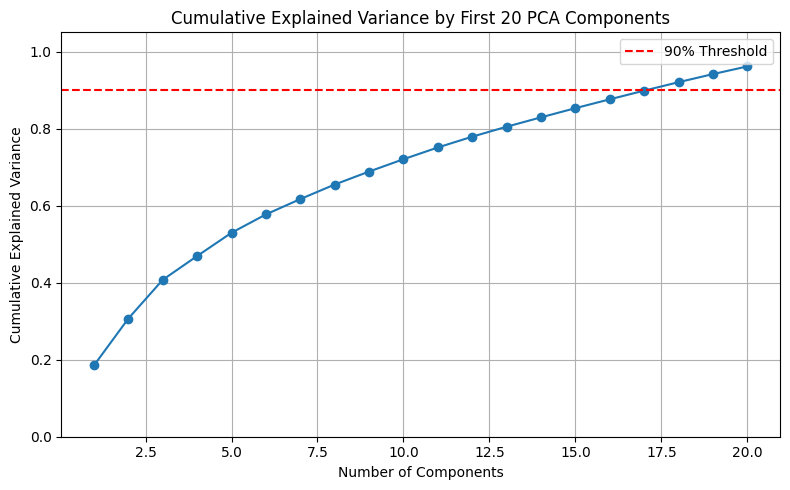

In [145]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Store results
results = []

# Loop through 1 to 20 components
for n_components in range(1, 21):
    pca = PCA(n_components=n_components, random_state=1)
    X_pca = pca.fit_transform(X_scaled)

    regressor = LinearRegression()
    y_pred = cross_val_predict(regressor, X_pca, y, cv=X.shape[0])  # LOOCV

    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    pearson_corr, _ = pearsonr(y, y_pred)

    results.append({
        'n_components': n_components,
        'mae': mae,
        'r2': r2,
        'pearson': pearson_corr,
        'y_pred': y_pred,
        'pca_model': pca
    })

    print(f"Components: {n_components:2d} | MAE: {mae:.2f} | R²: {r2:.3f} | Pearson: {pearson_corr:.3f}")

# Find the best result (lowest MAE)
best_result = min(results, key=lambda x: x['mae'])

# Unpack best model metrics
n_best = best_result['n_components']
y_pred_best = best_result['y_pred']
r2_best = best_result['r2']
pearson_best = best_result['pearson']
mae_best = best_result['mae']

# Plot predictions for the best model
plt.figure(figsize=(10, 7))
plt.scatter(y, y_pred_best, alpha=0.7, color='b')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title(f'PCR with {n_best} PCA Components (LOOCV)\nR² = {r2_best:.2f}, Pearson = {pearson_best:.2f}')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.2 * (y.max() - y.min()), f'MAE = {mae_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.1 * (y.max() - y.min()), f'R² = {r2_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.15 * (y.max() - y.min()), f'Pearson = {pearson_best:.2f}', fontsize=12, color='blue')
plt.grid(True)
plt.show()

# --- NEW: Explained variance using PCA with 20 components ---
pca_full = PCA(n_components=20, random_state=1)
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = explained_var.cumsum()

print("\nExplained Variance by Each of the First 20 Components:")
for i, (ev, cum_ev) in enumerate(zip(explained_var, cumulative_var), start=1):
    print(f"Component {i:2d}: {ev:.4f} (Cumulative: {cum_ev:.4f})")

# Optional: Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, 21), cumulative_var, marker='o', linestyle='-')
plt.title('Cumulative Explained Variance by First 20 PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.ylim(0, 1.05)
plt.grid(True)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Threshold')
plt.legend()
plt.tight_layout()
plt.show()

#### Female

In [146]:
eye_df_female = eye_df.loc[eye_df.iloc[:,-3] == "F"]

eye_df_female.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
I4_2,15.386990,386.484981,886.109592,859.861198,109.519163,629.961467,3569.781647,1411.982599,1011.920862,604.618190,...,244.381604,510.486016,26.248394,943.131967,1116.914440,115.854982,492.383675,F,Eye,103
I8_2,12.334831,532.640416,1043.975216,1095.557235,133.440441,821.948264,3856.316615,1303.006661,1168.444871,788.307816,...,316.220205,512.456148,43.732582,990.150500,729.997708,124.469655,420.505592,F,Eye,78
J16_2,22.685047,429.201097,754.050975,980.901449,107.980826,695.069852,3067.925808,1020.827132,767.662004,589.811232,...,382.923600,676.014412,6.351813,1063.475021,842.068959,164.239743,499.978444,F,Eye,147
J4_2,12.046830,512.659560,938.314234,1137.756203,132.515134,821.861540,2374.564123,2248.741672,1127.047910,700.054699,...,319.910274,661.237135,16.062441,919.574720,527.383464,95.036106,285.108319,F,Eye,75
K4_2,15.665415,519.432180,642.282013,1146.873274,50.294227,738.747989,1886.445759,812.128091,779.972766,577.971362,...,357.831057,676.086330,4.122478,937.451411,878.087733,157.478645,583.742831,F,Eye,103


In [147]:
eye_sub_df_female = eye_df_female.iloc[:,:-3]

eye_sub_df_female.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
I4_2,15.386990,386.484981,886.109592,859.861198,109.519163,629.961467,3569.781647,1411.982599,1011.920862,604.618190,...,1175.747049,297.783510,912.357987,244.381604,510.486016,26.248394,943.131967,1116.914440,115.854982,492.383675
I8_2,12.334831,532.640416,1043.975216,1095.557235,133.440441,821.948264,3856.316615,1303.006661,1168.444871,788.307816,...,1066.402181,305.006723,1040.611171,316.220205,512.456148,43.732582,990.150500,729.997708,124.469655,420.505592
J16_2,22.685047,429.201097,754.050975,980.901449,107.980826,695.069852,3067.925808,1020.827132,767.662004,589.811232,...,1107.937714,241.368904,1186.881679,382.923600,676.014412,6.351813,1063.475021,842.068959,164.239743,499.978444
J4_2,12.046830,512.659560,938.314234,1137.756203,132.515134,821.861540,2374.564123,2248.741672,1127.047910,700.054699,...,915.559109,489.904436,1168.542548,319.910274,661.237135,16.062441,919.574720,527.383464,95.036106,285.108319
K4_2,15.665415,519.432180,642.282013,1146.873274,50.294227,738.747989,1886.445759,812.128091,779.972766,577.971362,...,1025.672432,157.478645,1292.808981,357.831057,676.086330,4.122478,937.451411,878.087733,157.478645,583.742831


In [148]:
eye_sub_df_female["age"] = eye_df_female["age_days"].tolist()

eye_sub_df_female.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
I4_2,15.386990,386.484981,886.109592,859.861198,109.519163,629.961467,3569.781647,1411.982599,1011.920862,604.618190,...,297.783510,912.357987,244.381604,510.486016,26.248394,943.131967,1116.914440,115.854982,492.383675,103
I8_2,12.334831,532.640416,1043.975216,1095.557235,133.440441,821.948264,3856.316615,1303.006661,1168.444871,788.307816,...,305.006723,1040.611171,316.220205,512.456148,43.732582,990.150500,729.997708,124.469655,420.505592,78
J16_2,22.685047,429.201097,754.050975,980.901449,107.980826,695.069852,3067.925808,1020.827132,767.662004,589.811232,...,241.368904,1186.881679,382.923600,676.014412,6.351813,1063.475021,842.068959,164.239743,499.978444,147
J4_2,12.046830,512.659560,938.314234,1137.756203,132.515134,821.861540,2374.564123,2248.741672,1127.047910,700.054699,...,489.904436,1168.542548,319.910274,661.237135,16.062441,919.574720,527.383464,95.036106,285.108319,75
K4_2,15.665415,519.432180,642.282013,1146.873274,50.294227,738.747989,1886.445759,812.128091,779.972766,577.971362,...,157.478645,1292.808981,357.831057,676.086330,4.122478,937.451411,878.087733,157.478645,583.742831,103


In [149]:
eye_data_female = eye_sub_df_female.values

In [150]:
X, y = eye_data_female[:,:-1], eye_data_female[:,-1]

Components:  1 | MAE: 16.12 | R²: 0.497 | Pearson: 0.715
Components:  2 | MAE: 17.64 | R²: 0.437 | Pearson: 0.684
Components:  3 | MAE: 18.03 | R²: 0.412 | Pearson: 0.678
Components:  4 | MAE: 22.55 | R²: 0.102 | Pearson: 0.519
Components:  5 | MAE: 42.81 | R²: -5.061 | Pearson: 0.040
Components:  6 | MAE: 42.81 | R²: -5.450 | Pearson: -0.118
Components:  7 | MAE: 27.53 | R²: -0.741 | Pearson: 0.766
Components:  8 | MAE: 30.81 | R²: -1.325 | Pearson: 0.753
Components:  9 | MAE: 75.73 | R²: -14.386 | Pearson: 0.444
Components: 10 | MAE: 33.56 | R²: -2.677 | Pearson: 0.490
Components: 11 | MAE: 78.79 | R²: -13.714 | Pearson: 0.017
Components: 12 | MAE: 31.39 | R²: -0.914 | Pearson: 0.633
Components: 13 | MAE: 14.76 | R²: 0.566 | Pearson: 0.763
Components: 14 | MAE: 14.76 | R²: 0.566 | Pearson: 0.763


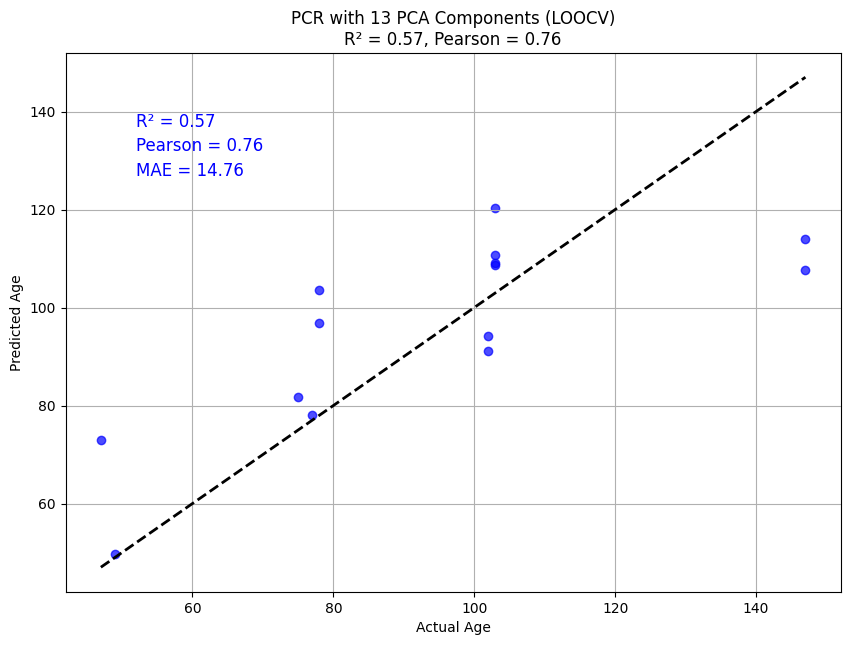


Explained Variance by Each of the First 20 Components:
Component  1: 0.2923 (Cumulative: 0.2923)
Component  2: 0.1704 (Cumulative: 0.4627)
Component  3: 0.1359 (Cumulative: 0.5986)
Component  4: 0.0696 (Cumulative: 0.6682)
Component  5: 0.0604 (Cumulative: 0.7285)
Component  6: 0.0531 (Cumulative: 0.7817)
Component  7: 0.0392 (Cumulative: 0.8209)
Component  8: 0.0356 (Cumulative: 0.8565)
Component  9: 0.0328 (Cumulative: 0.8893)
Component 10: 0.0311 (Cumulative: 0.9204)
Component 11: 0.0292 (Cumulative: 0.9495)
Component 12: 0.0270 (Cumulative: 0.9765)
Component 13: 0.0235 (Cumulative: 1.0000)
Component 14: 0.0000 (Cumulative: 1.0000)


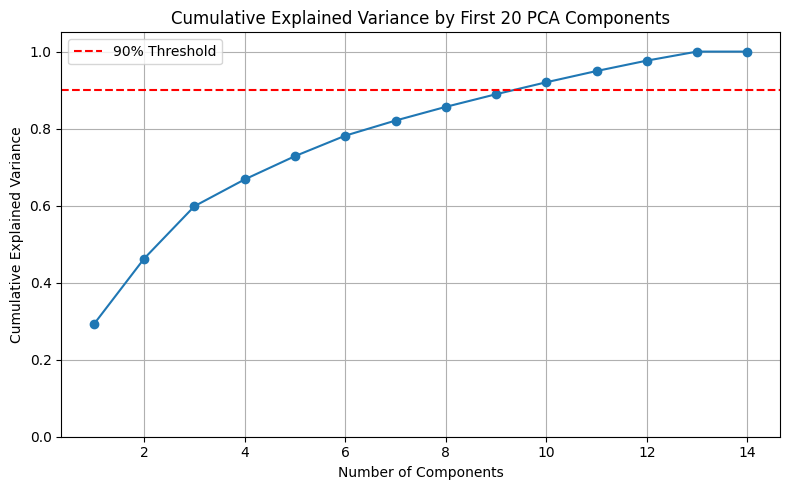

In [151]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Store results
results = []

# Loop through 1 to 20 components
for n_components in range(1, 15):
    pca = PCA(n_components=n_components, random_state=1)
    X_pca = pca.fit_transform(X_scaled)

    regressor = LinearRegression()
    y_pred = cross_val_predict(regressor, X_pca, y, cv=X.shape[0])  # LOOCV

    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    pearson_corr, _ = pearsonr(y, y_pred)

    results.append({
        'n_components': n_components,
        'mae': mae,
        'r2': r2,
        'pearson': pearson_corr,
        'y_pred': y_pred,
        'pca_model': pca
    })

    print(f"Components: {n_components:2d} | MAE: {mae:.2f} | R²: {r2:.3f} | Pearson: {pearson_corr:.3f}")

# Find the best result (lowest MAE)
best_result = min(results, key=lambda x: x['mae'])

# Unpack best model metrics
n_best = best_result['n_components']
y_pred_best = best_result['y_pred']
r2_best = best_result['r2']
pearson_best = best_result['pearson']
mae_best = best_result['mae']

# Plot predictions for the best model
plt.figure(figsize=(10, 7))
plt.scatter(y, y_pred_best, alpha=0.7, color='b')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title(f'PCR with {n_best} PCA Components (LOOCV)\nR² = {r2_best:.2f}, Pearson = {pearson_best:.2f}')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.2 * (y.max() - y.min()), f'MAE = {mae_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.1 * (y.max() - y.min()), f'R² = {r2_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.15 * (y.max() - y.min()), f'Pearson = {pearson_best:.2f}', fontsize=12, color='blue')
plt.grid(True)
plt.show()

# --- NEW: Explained variance using PCA with 20 components ---
pca_full = PCA(n_components=14, random_state=1)
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = explained_var.cumsum()

print("\nExplained Variance by Each of the First 20 Components:")
for i, (ev, cum_ev) in enumerate(zip(explained_var, cumulative_var), start=1):
    print(f"Component {i:2d}: {ev:.4f} (Cumulative: {cum_ev:.4f})")

# Optional: Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, 15), cumulative_var, marker='o', linestyle='-')
plt.title('Cumulative Explained Variance by First 20 PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.ylim(0, 1.05)
plt.grid(True)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Threshold')
plt.legend()
plt.tight_layout()
plt.show()

# Testis

In [152]:
testis_df = combined_df.loc[combined_df.iloc[:,-2] == "Testis"]

testis_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A21_1,22.364947,1328.342293,113.180185,474.407962,100.981123,1706.513211,481.862944,913.574189,1114.858710,1381.882620,...,3120.248938,2304.944969,412.057201,759.052739,1497.773708,495.417457,741.431872,M,Testis,78
A24_1,19.633246,1284.886904,170.154802,393.392086,67.625627,1447.042976,548.276585,820.233406,1060.922464,1291.431320,...,2309.451504,2417.070781,380.303255,841.320967,1469.584852,382.484726,591.906021,M,Testis,75
B22_1,13.034212,1248.217471,158.710698,428.595557,89.706047,1576.372925,536.702844,748.317108,1272.752459,1311.088376,...,3242.451896,2425.896855,380.292301,759.051165,1414.595353,545.903464,708.447754,M,Testis,133
B23_1,25.862520,1336.230182,126.726346,576.734188,143.105942,1785.375940,450.869926,936.223211,1348.299358,1558.647851,...,3352.644631,2305.212585,460.352850,765.530582,1347.437274,448.283674,656.045915,M,Testis,162
C21_1,4.611588,1344.738941,131.891405,432.566916,96.843339,1724.733759,571.836861,865.133832,1239.594744,1393.621770,...,2798.311350,2372.200657,471.304252,869.745420,1384.398595,500.818412,736.009379,M,Testis,134


In [153]:
testis_df_male = testis_df.loc[testis_df.iloc[:,-3] == "M"]

testis_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A21_1,22.364947,1328.342293,113.180185,474.407962,100.981123,1706.513211,481.862944,913.574189,1114.858710,1381.882620,...,3120.248938,2304.944969,412.057201,759.052739,1497.773708,495.417457,741.431872,M,Testis,78
A24_1,19.633246,1284.886904,170.154802,393.392086,67.625627,1447.042976,548.276585,820.233406,1060.922464,1291.431320,...,2309.451504,2417.070781,380.303255,841.320967,1469.584852,382.484726,591.906021,M,Testis,75
B22_1,13.034212,1248.217471,158.710698,428.595557,89.706047,1576.372925,536.702844,748.317108,1272.752459,1311.088376,...,3242.451896,2425.896855,380.292301,759.051165,1414.595353,545.903464,708.447754,M,Testis,133
B23_1,25.862520,1336.230182,126.726346,576.734188,143.105942,1785.375940,450.869926,936.223211,1348.299358,1558.647851,...,3352.644631,2305.212585,460.352850,765.530582,1347.437274,448.283674,656.045915,M,Testis,162
C21_1,4.611588,1344.738941,131.891405,432.566916,96.843339,1724.733759,571.836861,865.133832,1239.594744,1393.621770,...,2798.311350,2372.200657,471.304252,869.745420,1384.398595,500.818412,736.009379,M,Testis,134


In [154]:
testis_sub_df_male = testis_df_male.iloc[:,:-3]
testis_sub_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A21_1,22.364947,1328.342293,113.180185,474.407962,100.981123,1706.513211,481.862944,913.574189,1114.858710,1381.882620,...,193.829539,797.005376,2551.637109,3120.248938,2304.944969,412.057201,759.052739,1497.773708,495.417457,741.431872
A24_1,19.633246,1284.886904,170.154802,393.392086,67.625627,1447.042976,548.276585,820.233406,1060.922464,1291.431320,...,230.508856,541.005012,2004.045449,2309.451504,2417.070781,380.303255,841.320967,1469.584852,382.484726,591.906021
B22_1,13.034212,1248.217471,158.710698,428.595557,89.706047,1576.372925,536.702844,748.317108,1272.752459,1311.088376,...,255.317210,670.878555,2646.711739,3242.451896,2425.896855,380.292301,759.051165,1414.595353,545.903464,708.447754
B23_1,25.862520,1336.230182,126.726346,576.734188,143.105942,1785.375940,450.869926,936.223211,1348.299358,1558.647851,...,235.348929,856.049400,2102.622848,3352.644631,2305.212585,460.352850,765.530582,1347.437274,448.283674,656.045915
C21_1,4.611588,1344.738941,131.891405,432.566916,96.843339,1724.733759,571.836861,865.133832,1239.594744,1393.621770,...,240.724872,749.844142,2418.316532,2798.311350,2372.200657,471.304252,869.745420,1384.398595,500.818412,736.009379


In [155]:
testis_sub_df_male["age"] = testis_df_male["age_days"].tolist()

testis_sub_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A21_1,22.364947,1328.342293,113.180185,474.407962,100.981123,1706.513211,481.862944,913.574189,1114.858710,1381.882620,...,797.005376,2551.637109,3120.248938,2304.944969,412.057201,759.052739,1497.773708,495.417457,741.431872,78
A24_1,19.633246,1284.886904,170.154802,393.392086,67.625627,1447.042976,548.276585,820.233406,1060.922464,1291.431320,...,541.005012,2004.045449,2309.451504,2417.070781,380.303255,841.320967,1469.584852,382.484726,591.906021,75
B22_1,13.034212,1248.217471,158.710698,428.595557,89.706047,1576.372925,536.702844,748.317108,1272.752459,1311.088376,...,670.878555,2646.711739,3242.451896,2425.896855,380.292301,759.051165,1414.595353,545.903464,708.447754,133
B23_1,25.862520,1336.230182,126.726346,576.734188,143.105942,1785.375940,450.869926,936.223211,1348.299358,1558.647851,...,856.049400,2102.622848,3352.644631,2305.212585,460.352850,765.530582,1347.437274,448.283674,656.045915,162
C21_1,4.611588,1344.738941,131.891405,432.566916,96.843339,1724.733759,571.836861,865.133832,1239.594744,1393.621770,...,749.844142,2418.316532,2798.311350,2372.200657,471.304252,869.745420,1384.398595,500.818412,736.009379,134


In [156]:
testis_data_male = testis_sub_df_male.values

In [157]:
X, y = testis_data_male[:,:-1], testis_data_male[:,-1]

Components:  1 | MAE: 39.50 | R²: -0.087 | Pearson: -0.074
Components:  2 | MAE: 38.43 | R²: -0.026 | Pearson: 0.196


Components:  3 | MAE: 34.51 | R²: 0.094 | Pearson: 0.388
Components:  4 | MAE: 21.38 | R²: 0.616 | Pearson: 0.788
Components:  5 | MAE: 21.21 | R²: 0.566 | Pearson: 0.761
Components:  6 | MAE: 22.47 | R²: 0.513 | Pearson: 0.739
Components:  7 | MAE: 18.59 | R²: 0.554 | Pearson: 0.827
Components:  8 | MAE: 16.09 | R²: 0.621 | Pearson: 0.853
Components:  9 | MAE: 17.63 | R²: 0.560 | Pearson: 0.826
Components: 10 | MAE: 24.01 | R²: -0.123 | Pearson: 0.739
Components: 11 | MAE: 20.52 | R²: 0.365 | Pearson: 0.824
Components: 12 | MAE: 16.35 | R²: 0.671 | Pearson: 0.882
Components: 13 | MAE: 17.02 | R²: 0.592 | Pearson: 0.866
Components: 14 | MAE: 18.76 | R²: 0.496 | Pearson: 0.856
Components: 15 | MAE: 18.92 | R²: 0.452 | Pearson: 0.840
Components: 16 | MAE: 17.26 | R²: 0.594 | Pearson: 0.868
Components: 17 | MAE: 21.69 | R²: 0.280 | Pearson: 0.815
Components: 18 | MAE: 19.53 | R²: 0.518 | Pearson: 0.863
Components: 19 | MAE: 26.55 | R²: 0.032 | Pearson: 0.785
Components: 20 | MAE: 34.21 | 

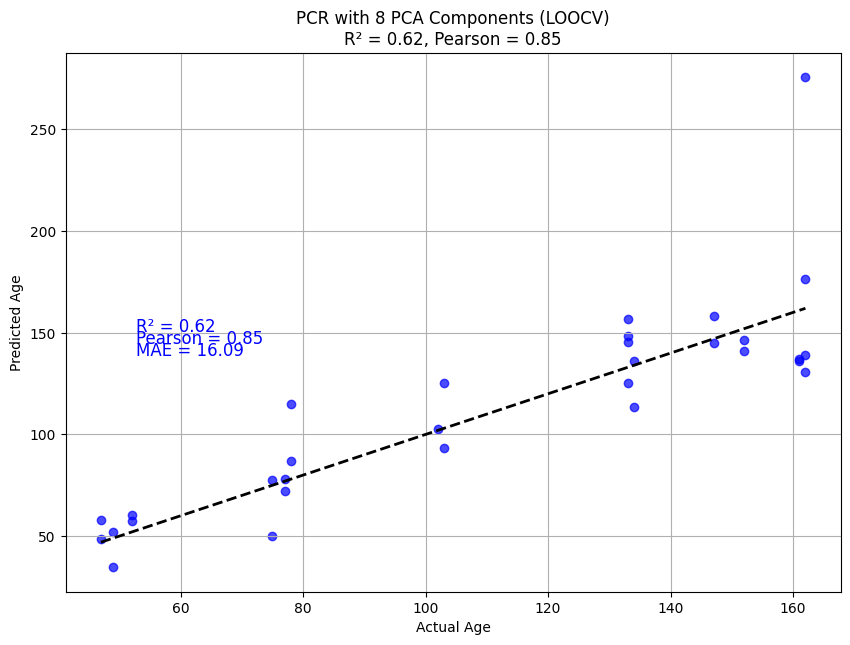


Explained Variance by Each of the First 20 Components:
Component  1: 0.1366 (Cumulative: 0.1366)
Component  2: 0.0898 (Cumulative: 0.2263)
Component  3: 0.0836 (Cumulative: 0.3100)
Component  4: 0.0500 (Cumulative: 0.3600)
Component  5: 0.0492 (Cumulative: 0.4092)
Component  6: 0.0393 (Cumulative: 0.4485)
Component  7: 0.0367 (Cumulative: 0.4852)
Component  8: 0.0341 (Cumulative: 0.5193)
Component  9: 0.0308 (Cumulative: 0.5501)
Component 10: 0.0282 (Cumulative: 0.5783)
Component 11: 0.0271 (Cumulative: 0.6054)
Component 12: 0.0266 (Cumulative: 0.6320)
Component 13: 0.0261 (Cumulative: 0.6581)
Component 14: 0.0245 (Cumulative: 0.6826)
Component 15: 0.0241 (Cumulative: 0.7067)
Component 16: 0.0234 (Cumulative: 0.7301)
Component 17: 0.0219 (Cumulative: 0.7520)
Component 18: 0.0216 (Cumulative: 0.7736)
Component 19: 0.0210 (Cumulative: 0.7945)
Component 20: 0.0206 (Cumulative: 0.8152)


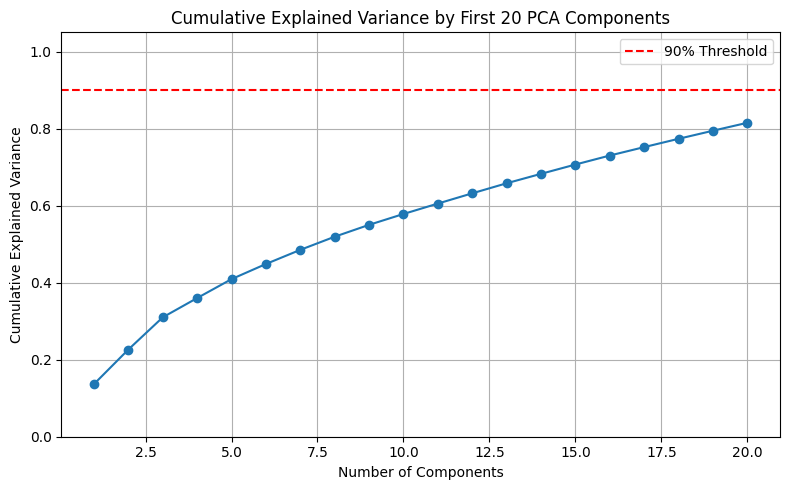

In [158]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Store results
results = []

# Loop through 1 to 20 components
for n_components in range(1, 21):
    pca = PCA(n_components=n_components, random_state=1)
    X_pca = pca.fit_transform(X_scaled)

    regressor = LinearRegression()
    y_pred = cross_val_predict(regressor, X_pca, y, cv=X.shape[0])  # LOOCV

    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    pearson_corr, _ = pearsonr(y, y_pred)

    results.append({
        'n_components': n_components,
        'mae': mae,
        'r2': r2,
        'pearson': pearson_corr,
        'y_pred': y_pred,
        'pca_model': pca
    })

    print(f"Components: {n_components:2d} | MAE: {mae:.2f} | R²: {r2:.3f} | Pearson: {pearson_corr:.3f}")

# Find the best result (lowest MAE)
best_result = min(results, key=lambda x: x['mae'])

# Unpack best model metrics
n_best = best_result['n_components']
y_pred_best = best_result['y_pred']
r2_best = best_result['r2']
pearson_best = best_result['pearson']
mae_best = best_result['mae']

# Plot predictions for the best model
plt.figure(figsize=(10, 7))
plt.scatter(y, y_pred_best, alpha=0.7, color='b')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title(f'PCR with {n_best} PCA Components (LOOCV)\nR² = {r2_best:.2f}, Pearson = {pearson_best:.2f}')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.2 * (y.max() - y.min()), f'MAE = {mae_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.1 * (y.max() - y.min()), f'R² = {r2_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.15 * (y.max() - y.min()), f'Pearson = {pearson_best:.2f}', fontsize=12, color='blue')
plt.grid(True)
plt.show()

# --- NEW: Explained variance using PCA with 20 components ---
pca_full = PCA(n_components=20, random_state=1)
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = explained_var.cumsum()

print("\nExplained Variance by Each of the First 20 Components:")
for i, (ev, cum_ev) in enumerate(zip(explained_var, cumulative_var), start=1):
    print(f"Component {i:2d}: {ev:.4f} (Cumulative: {cum_ev:.4f})")

# Optional: Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, 21), cumulative_var, marker='o', linestyle='-')
plt.title('Cumulative Explained Variance by First 20 PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.ylim(0, 1.05)
plt.grid(True)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Threshold')
plt.legend()
plt.tight_layout()
plt.show()

# Ovary

In [159]:
ovary_df = combined_df.loc[combined_df.iloc[:,-2] == "Ovary"]

ovary_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A23_1,27.012859,1133.939803,453.215750,226.307732,517.446326,841.600637,1213.177523,267.127164,1103.925515,486.831752,...,203.496873,1713.815848,447.212892,564.868901,4106.554892,321.753168,1279.208957,F,Ovary,78
B21_1,20.475689,1021.327380,437.360722,222.775499,488.959459,787.085495,1417.736724,405.418647,1060.640703,378.390737,...,171.176762,1375.147290,443.093915,438.179750,4603.753971,484.864321,1013.137104,F,Ovary,155
B24_1,39.057682,902.808709,557.692472,232.425221,511.591602,533.361457,1333.723788,291.331888,915.614506,449.483485,...,170.317104,1703.171040,416.188412,565.375950,4901.418913,508.390152,1235.119149,F,Ovary,75
C23_1,26.677866,1058.222034,417.953240,215.848192,462.416351,880.369592,1059.838875,370.256449,1092.175682,515.772084,...,229.591335,1485.876317,486.668957,425.229022,3709.031851,392.892214,1054.988353,F,Ovary,147
D21_1,48.765093,940.469648,580.536820,212.089452,515.516696,990.008790,1332.912538,223.700188,1429.668675,535.641972,...,252.340004,1655.691010,517.838843,601.436145,4955.462295,421.082707,1150.236952,F,Ovary,78


In [160]:
ovary_sub_df = ovary_df.iloc[:,:-3]

ovary_sub_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A23_1,27.012859,1133.939803,453.215750,226.307732,517.446326,841.600637,1213.177523,267.127164,1103.925515,486.831752,...,453.816035,106.850865,1315.826388,203.496873,1713.815848,447.212892,564.868901,4106.554892,321.753168,1279.208957
B21_1,20.475689,1021.327380,437.360722,222.775499,488.959459,787.085495,1417.736724,405.418647,1060.640703,378.390737,...,588.880823,102.378446,1275.225927,171.176762,1375.147290,443.093915,438.179750,4603.753971,484.864321,1013.137104
B24_1,39.057682,902.808709,557.692472,232.425221,511.591602,533.361457,1333.723788,291.331888,915.614506,449.483485,...,740.815373,68.511016,1657.070169,170.317104,1703.171040,416.188412,565.375950,4901.418913,508.390152,1235.119149
C23_1,26.677866,1058.222034,417.953240,215.848192,462.416351,880.369592,1059.838875,370.256449,1092.175682,515.772084,...,539.216270,159.258778,1205.354510,229.591335,1485.876317,486.668957,425.229022,3709.031851,392.892214,1054.988353
D21_1,48.765093,940.469648,580.536820,212.089452,515.516696,990.008790,1332.912538,223.700188,1429.668675,535.641972,...,660.263876,127.718100,1145.592658,252.340004,1655.691010,517.838843,601.436145,4955.462295,421.082707,1150.236952


In [161]:
ovary_sub_df["age"] = ovary_df["age_days"].tolist()

ovary_sub_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A23_1,27.012859,1133.939803,453.215750,226.307732,517.446326,841.600637,1213.177523,267.127164,1103.925515,486.831752,...,106.850865,1315.826388,203.496873,1713.815848,447.212892,564.868901,4106.554892,321.753168,1279.208957,78
B21_1,20.475689,1021.327380,437.360722,222.775499,488.959459,787.085495,1417.736724,405.418647,1060.640703,378.390737,...,102.378446,1275.225927,171.176762,1375.147290,443.093915,438.179750,4603.753971,484.864321,1013.137104,155
B24_1,39.057682,902.808709,557.692472,232.425221,511.591602,533.361457,1333.723788,291.331888,915.614506,449.483485,...,68.511016,1657.070169,170.317104,1703.171040,416.188412,565.375950,4901.418913,508.390152,1235.119149,75
C23_1,26.677866,1058.222034,417.953240,215.848192,462.416351,880.369592,1059.838875,370.256449,1092.175682,515.772084,...,159.258778,1205.354510,229.591335,1485.876317,486.668957,425.229022,3709.031851,392.892214,1054.988353,147
D21_1,48.765093,940.469648,580.536820,212.089452,515.516696,990.008790,1332.912538,223.700188,1429.668675,535.641972,...,127.718100,1145.592658,252.340004,1655.691010,517.838843,601.436145,4955.462295,421.082707,1150.236952,78


In [162]:
ovary_data = ovary_sub_df.values

In [163]:
X, y = ovary_data[:,:-1], ovary_data[:,-1]

y

array([ 78., 155.,  75., 147.,  78.,  49.,  77.,  52., 155.,  75.,  49.,
       102., 134.,  52., 102.])

Components:  1 | MAE: 22.89 | R²: 0.394 | Pearson: 0.635
Components:  2 | MAE: 25.60 | R²: 0.335 | Pearson: 0.627
Components:  3 | MAE: 21.60 | R²: 0.510 | Pearson: 0.735
Components:  4 | MAE: 22.42 | R²: 0.386 | Pearson: 0.696
Components:  5 | MAE: 22.63 | R²: 0.359 | Pearson: 0.731
Components:  6 | MAE: 25.06 | R²: 0.187 | Pearson: 0.703
Components:  7 | MAE: 28.66 | R²: -0.140 | Pearson: 0.661
Components:  8 | MAE: 33.00 | R²: -0.387 | Pearson: 0.613
Components:  9 | MAE: 39.53 | R²: -1.107 | Pearson: 0.577
Components: 10 | MAE: 68.27 | R²: -6.157 | Pearson: 0.552
Components: 11 | MAE: 97.75 | R²: -10.598 | Pearson: 0.541
Components: 12 | MAE: 114.70 | R²: -12.954 | Pearson: 0.492
Components: 13 | MAE: 145.14 | R²: -35.794 | Pearson: 0.408
Components: 14 | MAE: 20.17 | R²: 0.497 | Pearson: 0.707
Components: 15 | MAE: 20.17 | R²: 0.497 | Pearson: 0.707


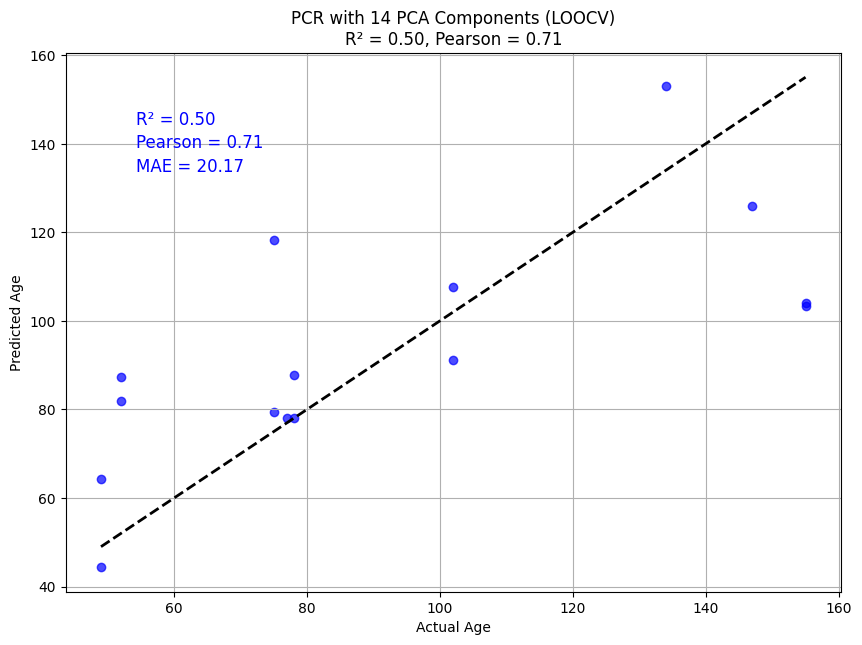


Explained Variance by Each of the First 20 Components:
Component  1: 0.2744 (Cumulative: 0.2744)
Component  2: 0.1249 (Cumulative: 0.3993)
Component  3: 0.0932 (Cumulative: 0.4925)
Component  4: 0.0750 (Cumulative: 0.5674)
Component  5: 0.0677 (Cumulative: 0.6352)
Component  6: 0.0546 (Cumulative: 0.6898)
Component  7: 0.0496 (Cumulative: 0.7394)
Component  8: 0.0449 (Cumulative: 0.7843)
Component  9: 0.0390 (Cumulative: 0.8233)
Component 10: 0.0385 (Cumulative: 0.8619)
Component 11: 0.0359 (Cumulative: 0.8978)
Component 12: 0.0352 (Cumulative: 0.9330)
Component 13: 0.0343 (Cumulative: 0.9673)
Component 14: 0.0327 (Cumulative: 1.0000)
Component 15: 0.0000 (Cumulative: 1.0000)


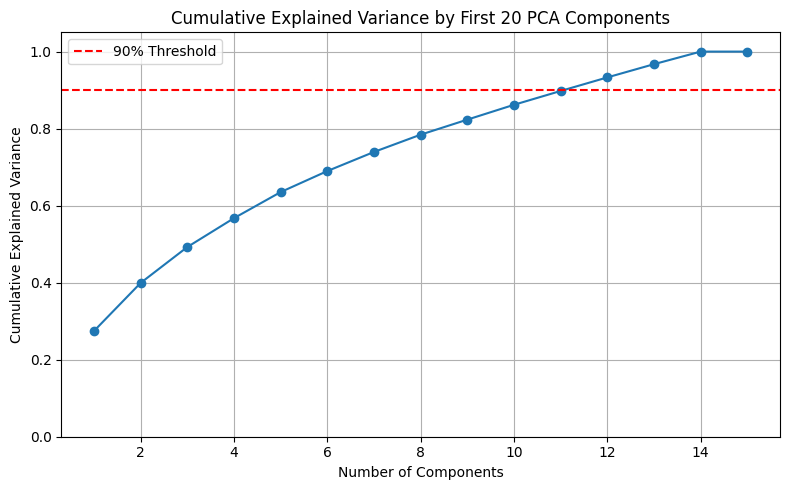

In [164]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Store results
results = []

# Loop through 1 to 20 components
for n_components in range(1, 16):
    pca = PCA(n_components=n_components, random_state=1)
    X_pca = pca.fit_transform(X_scaled)

    regressor = LinearRegression()
    y_pred = cross_val_predict(regressor, X_pca, y, cv=X.shape[0])  # LOOCV

    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    pearson_corr, _ = pearsonr(y, y_pred)

    results.append({
        'n_components': n_components,
        'mae': mae,
        'r2': r2,
        'pearson': pearson_corr,
        'y_pred': y_pred,
        'pca_model': pca
    })

    print(f"Components: {n_components:2d} | MAE: {mae:.2f} | R²: {r2:.3f} | Pearson: {pearson_corr:.3f}")

# Find the best result (lowest MAE)
best_result = min(results, key=lambda x: x['mae'])

# Unpack best model metrics
n_best = best_result['n_components']
y_pred_best = best_result['y_pred']
r2_best = best_result['r2']
pearson_best = best_result['pearson']
mae_best = best_result['mae']

# Plot predictions for the best model
plt.figure(figsize=(10, 7))
plt.scatter(y, y_pred_best, alpha=0.7, color='b')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title(f'PCR with {n_best} PCA Components (LOOCV)\nR² = {r2_best:.2f}, Pearson = {pearson_best:.2f}')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.2 * (y.max() - y.min()), f'MAE = {mae_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.1 * (y.max() - y.min()), f'R² = {r2_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.15 * (y.max() - y.min()), f'Pearson = {pearson_best:.2f}', fontsize=12, color='blue')
plt.grid(True)
plt.show()

# --- NEW: Explained variance using PCA with 20 components ---
pca_full = PCA(n_components=15, random_state=1)
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = explained_var.cumsum()

print("\nExplained Variance by Each of the First 20 Components:")
for i, (ev, cum_ev) in enumerate(zip(explained_var, cumulative_var), start=1):
    print(f"Component {i:2d}: {ev:.4f} (Cumulative: {cum_ev:.4f})")

# Optional: Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, 16), cumulative_var, marker='o', linestyle='-')
plt.title('Cumulative Explained Variance by First 20 PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.ylim(0, 1.05)
plt.grid(True)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Threshold')
plt.legend()
plt.tight_layout()
plt.show()

# Liver

In [165]:
liver_df = combined_df.loc[combined_df.iloc[:,-2] == "Liver"]

liver_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A5_1,100443.541866,569.498293,9197.259866,817.106246,41.267992,1034.451005,982.178215,4385.411973,935.407824,558.493495,...,101.794381,1141.747785,2.751199,511.723104,2555.864318,299.880743,448.445515,M,Liver,134
A6_1,43882.858900,853.088237,19132.800486,1147.075568,81.371493,1433.188238,1212.697740,1622.180093,1532.933939,713.969232,...,118.119910,2543.515389,307.111765,425.231675,2302.025796,782.216291,577.475114,F,Liver,52
A7_1,46308.620187,503.876178,3746.507910,867.215463,126.825977,1144.861521,1357.380725,1669.304073,970.047336,647.840801,...,41.132749,3033.540256,3.427729,414.755222,3191.215795,586.141677,661.551717,F,Liver,133
A8_1,139272.752006,589.285647,3047.097867,1149.107012,76.116063,1023.883812,1092.633804,2536.383640,989.508816,643.303498,...,130.133914,1156.473083,22.098212,564.732079,2492.187216,378.124957,414.955310,M,Liver,133
B5_1,50060.335020,509.903707,3616.007271,556.585032,32.317841,1037.761769,1052.125254,1658.982482,1138.306162,621.220713,...,25.136098,2007.296986,3.590871,373.450602,2330.475391,570.948516,416.541056,F,Liver,102


In [166]:
liver_df_male = liver_df.loc[liver_df.iloc[:,-3] == "M"]

liver_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A5_1,100443.541866,569.498293,9197.259866,817.106246,41.267992,1034.451005,982.178215,4385.411973,935.407824,558.493495,...,101.794381,1141.747785,2.751199,511.723104,2555.864318,299.880743,448.445515,M,Liver,134
A8_1,139272.752006,589.285647,3047.097867,1149.107012,76.116063,1023.883812,1092.633804,2536.383640,989.508816,643.303498,...,130.133914,1156.473083,22.098212,564.732079,2492.187216,378.124957,414.955310,M,Liver,133
B7_1,106880.160432,442.985714,13625.869465,670.276813,71.898205,1080.792369,1289.529093,2620.805531,772.325878,712.024158,...,34.789454,1338.234329,6.957891,547.354076,2435.261777,582.143529,565.908451,M,Liver,133
C5_1,113772.810228,696.735509,24082.457958,633.892699,62.842811,1158.493553,920.783791,3191.321862,857.940980,740.452247,...,166.670063,1155.761257,24.590665,478.151820,2330.648586,237.709762,437.167378,M,Liver,162
C7_1,109847.738206,626.472460,8772.952023,818.154332,91.165768,1302.034180,1491.378468,2718.609966,885.944262,883.606679,...,179.993953,766.727488,16.363087,523.618773,2966.393850,367.000658,446.478507,M,Liver,152


In [167]:
liver_sub_df_male = liver_df_male.iloc[:,:-3]
liver_sub_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A5_1,100443.541866,569.498293,9197.259866,817.106246,41.267992,1034.451005,982.178215,4385.411973,935.407824,558.493495,...,228.349557,71.531187,723.565464,101.794381,1141.747785,2.751199,511.723104,2555.864318,299.880743,448.445515
A8_1,139272.752006,589.285647,3047.097867,1149.107012,76.116063,1023.883812,1092.633804,2536.383640,989.508816,643.303498,...,184.151765,56.473208,785.714196,130.133914,1156.473083,22.098212,564.732079,2492.187216,378.124957,414.955310
B7_1,106880.160432,442.985714,13625.869465,670.276813,71.898205,1080.792369,1289.529093,2620.805531,772.325878,712.024158,...,306.147195,104.368362,1386.939564,34.789454,1338.234329,6.957891,547.354076,2435.261777,582.143529,565.908451
C5_1,113772.810228,696.735509,24082.457958,633.892699,62.842811,1158.493553,920.783791,3191.321862,857.940980,740.452247,...,204.922209,131.150214,833.350315,166.670063,1155.761257,24.590665,478.151820,2330.648586,237.709762,437.167378
C7_1,109847.738206,626.472460,8772.952023,818.154332,91.165768,1302.034180,1491.378468,2718.609966,885.944262,883.606679,...,184.669121,39.738925,1259.957671,179.993953,766.727488,16.363087,523.618773,2966.393850,367.000658,446.478507


In [168]:
liver_sub_df_male["age"] = liver_df_male["age_days"].tolist()

liver_sub_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A5_1,100443.541866,569.498293,9197.259866,817.106246,41.267992,1034.451005,982.178215,4385.411973,935.407824,558.493495,...,71.531187,723.565464,101.794381,1141.747785,2.751199,511.723104,2555.864318,299.880743,448.445515,134
A8_1,139272.752006,589.285647,3047.097867,1149.107012,76.116063,1023.883812,1092.633804,2536.383640,989.508816,643.303498,...,56.473208,785.714196,130.133914,1156.473083,22.098212,564.732079,2492.187216,378.124957,414.955310,133
B7_1,106880.160432,442.985714,13625.869465,670.276813,71.898205,1080.792369,1289.529093,2620.805531,772.325878,712.024158,...,104.368362,1386.939564,34.789454,1338.234329,6.957891,547.354076,2435.261777,582.143529,565.908451,133
C5_1,113772.810228,696.735509,24082.457958,633.892699,62.842811,1158.493553,920.783791,3191.321862,857.940980,740.452247,...,131.150214,833.350315,166.670063,1155.761257,24.590665,478.151820,2330.648586,237.709762,437.167378,162
C7_1,109847.738206,626.472460,8772.952023,818.154332,91.165768,1302.034180,1491.378468,2718.609966,885.944262,883.606679,...,39.738925,1259.957671,179.993953,766.727488,16.363087,523.618773,2966.393850,367.000658,446.478507,152


In [169]:
liver_data_male = liver_sub_df_male.values

In [170]:
X, y = liver_data_male[:,:-1], liver_data_male[:,-1]

Components:  1 | MAE: 37.73 | R²: -0.102 | Pearson: -0.117


Components:  2 | MAE: 36.76 | R²: -0.111 | Pearson: 0.007
Components:  3 | MAE: 39.11 | R²: -0.305 | Pearson: 0.016
Components:  4 | MAE: 37.74 | R²: -0.184 | Pearson: 0.227
Components:  5 | MAE: 27.73 | R²: 0.351 | Pearson: 0.629
Components:  6 | MAE: 24.51 | R²: 0.413 | Pearson: 0.678
Components:  7 | MAE: 26.27 | R²: 0.339 | Pearson: 0.648
Components:  8 | MAE: 26.78 | R²: 0.353 | Pearson: 0.677
Components:  9 | MAE: 24.59 | R²: 0.372 | Pearson: 0.727
Components: 10 | MAE: 27.43 | R²: 0.178 | Pearson: 0.688
Components: 11 | MAE: 29.08 | R²: 0.047 | Pearson: 0.686
Components: 12 | MAE: 29.83 | R²: -0.067 | Pearson: 0.673
Components: 13 | MAE: 26.51 | R²: 0.123 | Pearson: 0.699
Components: 14 | MAE: 26.84 | R²: 0.271 | Pearson: 0.670
Components: 15 | MAE: 25.95 | R²: 0.189 | Pearson: 0.630
Components: 16 | MAE: 20.88 | R²: 0.553 | Pearson: 0.814
Components: 17 | MAE: 29.13 | R²: 0.145 | Pearson: 0.759
Components: 18 | MAE: 34.44 | R²: -0.772 | Pearson: 0.545
Components: 19 | MAE: 47.6

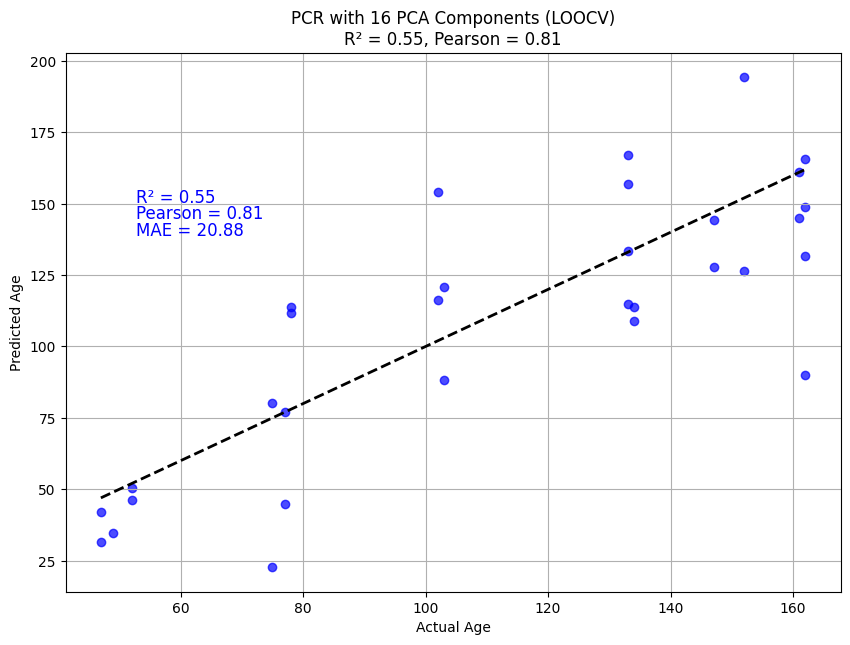


Explained Variance by Each of the First 20 Components:
Component  1: 0.1601 (Cumulative: 0.1601)
Component  2: 0.0993 (Cumulative: 0.2593)
Component  3: 0.0943 (Cumulative: 0.3537)
Component  4: 0.0582 (Cumulative: 0.4119)
Component  5: 0.0493 (Cumulative: 0.4612)
Component  6: 0.0383 (Cumulative: 0.4995)
Component  7: 0.0345 (Cumulative: 0.5340)
Component  8: 0.0316 (Cumulative: 0.5656)
Component  9: 0.0284 (Cumulative: 0.5940)
Component 10: 0.0275 (Cumulative: 0.6215)
Component 11: 0.0261 (Cumulative: 0.6476)
Component 12: 0.0238 (Cumulative: 0.6714)
Component 13: 0.0227 (Cumulative: 0.6941)
Component 14: 0.0221 (Cumulative: 0.7162)
Component 15: 0.0214 (Cumulative: 0.7376)
Component 16: 0.0212 (Cumulative: 0.7588)
Component 17: 0.0200 (Cumulative: 0.7789)
Component 18: 0.0194 (Cumulative: 0.7983)
Component 19: 0.0189 (Cumulative: 0.8172)
Component 20: 0.0185 (Cumulative: 0.8358)


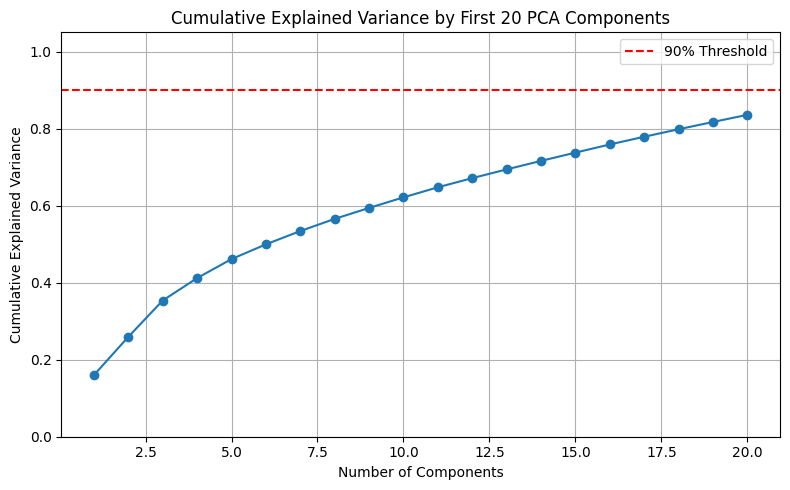

In [171]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Store results
results = []

# Loop through 1 to 20 components
for n_components in range(1, 21):
    pca = PCA(n_components=n_components, random_state=1)
    X_pca = pca.fit_transform(X_scaled)

    regressor = LinearRegression()
    y_pred = cross_val_predict(regressor, X_pca, y, cv=X.shape[0])  # LOOCV

    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    pearson_corr, _ = pearsonr(y, y_pred)

    results.append({
        'n_components': n_components,
        'mae': mae,
        'r2': r2,
        'pearson': pearson_corr,
        'y_pred': y_pred,
        'pca_model': pca
    })

    print(f"Components: {n_components:2d} | MAE: {mae:.2f} | R²: {r2:.3f} | Pearson: {pearson_corr:.3f}")

# Find the best result (lowest MAE)
best_result = min(results, key=lambda x: x['mae'])

# Unpack best model metrics
n_best = best_result['n_components']
y_pred_best = best_result['y_pred']
r2_best = best_result['r2']
pearson_best = best_result['pearson']
mae_best = best_result['mae']

# Plot predictions for the best model
plt.figure(figsize=(10, 7))
plt.scatter(y, y_pred_best, alpha=0.7, color='b')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title(f'PCR with {n_best} PCA Components (LOOCV)\nR² = {r2_best:.2f}, Pearson = {pearson_best:.2f}')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.2 * (y.max() - y.min()), f'MAE = {mae_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.1 * (y.max() - y.min()), f'R² = {r2_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.15 * (y.max() - y.min()), f'Pearson = {pearson_best:.2f}', fontsize=12, color='blue')
plt.grid(True)
plt.show()

# --- NEW: Explained variance using PCA with 20 components ---
pca_full = PCA(n_components=20, random_state=1)
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = explained_var.cumsum()

print("\nExplained Variance by Each of the First 20 Components:")
for i, (ev, cum_ev) in enumerate(zip(explained_var, cumulative_var), start=1):
    print(f"Component {i:2d}: {ev:.4f} (Cumulative: {cum_ev:.4f})")

# Optional: Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, 21), cumulative_var, marker='o', linestyle='-')
plt.title('Cumulative Explained Variance by First 20 PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.ylim(0, 1.05)
plt.grid(True)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Threshold')
plt.legend()
plt.tight_layout()
plt.show()

#### Female

In [172]:
liver_df_female = liver_df.loc[liver_df.iloc[:,-3] == "F"]

liver_df_female.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A6_1,43882.858900,853.088237,19132.800486,1147.075568,81.371493,1433.188238,1212.697740,1622.180093,1532.933939,713.969232,...,118.119910,2543.515389,307.111765,425.231675,2302.025796,782.216291,577.475114,F,Liver,52
A7_1,46308.620187,503.876178,3746.507910,867.215463,126.825977,1144.861521,1357.380725,1669.304073,970.047336,647.840801,...,41.132749,3033.540256,3.427729,414.755222,3191.215795,586.141677,661.551717,F,Liver,133
B5_1,50060.335020,509.903707,3616.007271,556.585032,32.317841,1037.761769,1052.125254,1658.982482,1138.306162,621.220713,...,25.136098,2007.296986,3.590871,373.450602,2330.475391,570.948516,416.541056,F,Liver,102
B6_1,52010.405793,439.314180,3444.223173,593.074143,74.683411,1107.071734,926.952920,1555.172198,760.013532,733.654681,...,39.538276,3088.378687,4.393142,487.638740,1871.478408,505.211307,544.749583,F,Liver,134
B8_1,57870.342592,385.596632,4719.702781,704.356515,66.836750,776.334553,1033.398975,1269.898243,1043.681552,622.095900,...,87.401903,2035.950219,35.989019,493.563689,1300.745973,426.726940,483.281113,F,Liver,133


In [173]:
liver_sub_df_female = liver_df_female.iloc[:,:-3]

liver_sub_df_female.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A6_1,43882.858900,853.088237,19132.800486,1147.075568,81.371493,1433.188238,1212.697740,1622.180093,1532.933939,713.969232,...,181.117195,191.616742,1007.956563,118.119910,2543.515389,307.111765,425.231675,2302.025796,782.216291,577.475114
A7_1,46308.620187,503.876178,3746.507910,867.215463,126.825977,1144.861521,1357.380725,1669.304073,970.047336,647.840801,...,140.536893,202.236017,1336.814350,41.132749,3033.540256,3.427729,414.755222,3191.215795,586.141677,661.551717
B5_1,50060.335020,509.903707,3616.007271,556.585032,32.317841,1037.761769,1052.125254,1658.982482,1138.306162,621.220713,...,118.498749,157.998332,1116.760935,25.136098,2007.296986,3.590871,373.450602,2330.475391,570.948516,416.541056
B6_1,52010.405793,439.314180,3444.223173,593.074143,74.683411,1107.071734,926.952920,1555.172198,760.013532,733.654681,...,144.973679,101.042261,856.662651,39.538276,3088.378687,4.393142,487.638740,1871.478408,505.211307,544.749583
B8_1,57870.342592,385.596632,4719.702781,704.356515,66.836750,776.334553,1033.398975,1269.898243,1043.681552,622.095900,...,107.967057,303.336017,925.431918,87.401903,2035.950219,35.989019,493.563689,1300.745973,426.726940,483.281113


In [174]:
liver_sub_df_female["age"] = liver_df_female["age_days"].tolist()

liver_sub_df_female.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A6_1,43882.858900,853.088237,19132.800486,1147.075568,81.371493,1433.188238,1212.697740,1622.180093,1532.933939,713.969232,...,191.616742,1007.956563,118.119910,2543.515389,307.111765,425.231675,2302.025796,782.216291,577.475114,52
A7_1,46308.620187,503.876178,3746.507910,867.215463,126.825977,1144.861521,1357.380725,1669.304073,970.047336,647.840801,...,202.236017,1336.814350,41.132749,3033.540256,3.427729,414.755222,3191.215795,586.141677,661.551717,133
B5_1,50060.335020,509.903707,3616.007271,556.585032,32.317841,1037.761769,1052.125254,1658.982482,1138.306162,621.220713,...,157.998332,1116.760935,25.136098,2007.296986,3.590871,373.450602,2330.475391,570.948516,416.541056,102
B6_1,52010.405793,439.314180,3444.223173,593.074143,74.683411,1107.071734,926.952920,1555.172198,760.013532,733.654681,...,101.042261,856.662651,39.538276,3088.378687,4.393142,487.638740,1871.478408,505.211307,544.749583,134
B8_1,57870.342592,385.596632,4719.702781,704.356515,66.836750,776.334553,1033.398975,1269.898243,1043.681552,622.095900,...,303.336017,925.431918,87.401903,2035.950219,35.989019,493.563689,1300.745973,426.726940,483.281113,133


In [175]:
liver_data_female = liver_sub_df_female.values

In [176]:
X, y = liver_data_female[:,:-1], liver_data_female[:,-1]

Components:  1 | MAE: 29.44 | R²: 0.134 | Pearson: 0.380
Components:  2 | MAE: 24.68 | R²: 0.366 | Pearson: 0.612
Components:  3 | MAE: 26.40 | R²: 0.326 | Pearson: 0.589
Components:  4 | MAE: 29.03 | R²: 0.239 | Pearson: 0.534
Components:  5 | MAE: 23.48 | R²: 0.438 | Pearson: 0.684
Components:  6 | MAE: 24.23 | R²: 0.413 | Pearson: 0.672
Components:  7 | MAE: 29.91 | R²: 0.048 | Pearson: 0.560
Components:  8 | MAE: 35.59 | R²: -0.685 | Pearson: 0.414
Components:  9 | MAE: 29.96 | R²: -0.292 | Pearson: 0.525
Components: 10 | MAE: 29.09 | R²: -0.059 | Pearson: 0.598
Components: 11 | MAE: 31.52 | R²: -0.252 | Pearson: 0.567
Components: 12 | MAE: 28.06 | R²: -0.084 | Pearson: 0.660
Components: 13 | MAE: 26.57 | R²: 0.086 | Pearson: 0.710
Components: 14 | MAE: 24.63 | R²: 0.400 | Pearson: 0.793
Components: 15 | MAE: 25.86 | R²: 0.264 | Pearson: 0.722
Components: 16 | MAE: 45.03 | R²: -3.811 | Pearson: 0.471
Components: 17 | MAE: 58.98 | R²: -4.889 | Pearson: 0.446
Components: 18 | MAE: 93

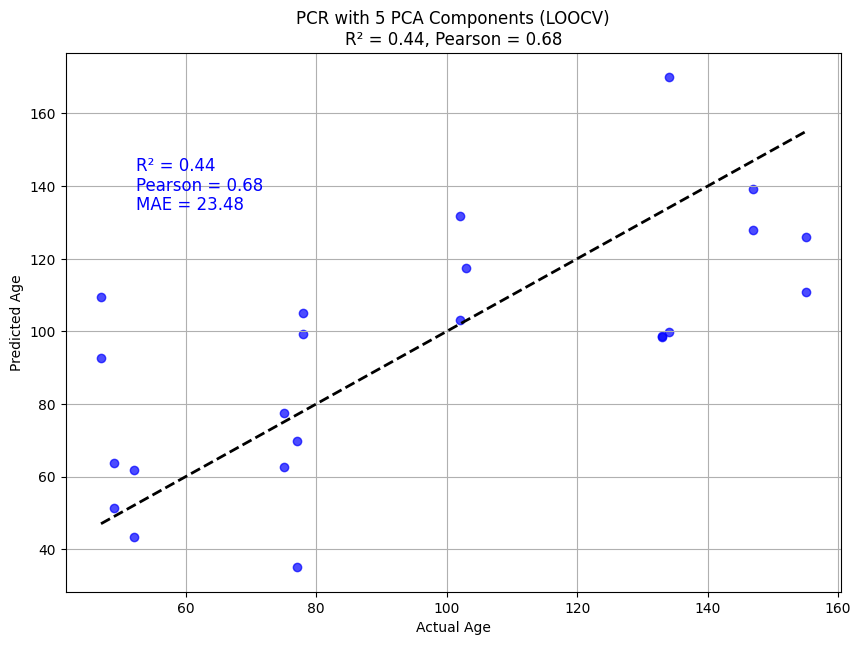


Explained Variance by Each of the First 20 Components:
Component  1: 0.1683 (Cumulative: 0.1683)
Component  2: 0.1172 (Cumulative: 0.2855)
Component  3: 0.0634 (Cumulative: 0.3489)
Component  4: 0.0600 (Cumulative: 0.4089)
Component  5: 0.0518 (Cumulative: 0.4606)
Component  6: 0.0502 (Cumulative: 0.5108)
Component  7: 0.0441 (Cumulative: 0.5549)
Component  8: 0.0430 (Cumulative: 0.5979)
Component  9: 0.0367 (Cumulative: 0.6346)
Component 10: 0.0343 (Cumulative: 0.6689)
Component 11: 0.0327 (Cumulative: 0.7016)
Component 12: 0.0314 (Cumulative: 0.7330)
Component 13: 0.0299 (Cumulative: 0.7629)
Component 14: 0.0295 (Cumulative: 0.7924)
Component 15: 0.0284 (Cumulative: 0.8208)
Component 16: 0.0282 (Cumulative: 0.8490)
Component 17: 0.0268 (Cumulative: 0.8757)
Component 18: 0.0267 (Cumulative: 0.9024)
Component 19: 0.0252 (Cumulative: 0.9276)
Component 20: 0.0246 (Cumulative: 0.9523)


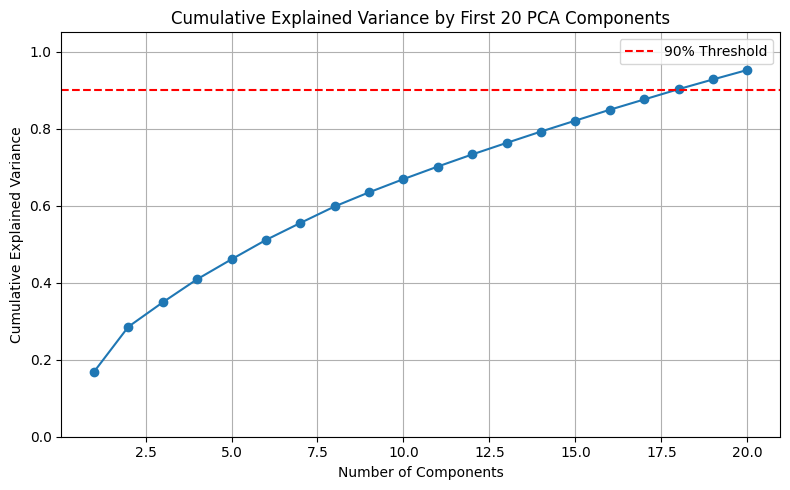

In [177]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Store results
results = []

# Loop through 1 to 20 components
for n_components in range(1, 21):
    pca = PCA(n_components=n_components, random_state=1)
    X_pca = pca.fit_transform(X_scaled)

    regressor = LinearRegression()
    y_pred = cross_val_predict(regressor, X_pca, y, cv=X.shape[0])  # LOOCV

    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    pearson_corr, _ = pearsonr(y, y_pred)

    results.append({
        'n_components': n_components,
        'mae': mae,
        'r2': r2,
        'pearson': pearson_corr,
        'y_pred': y_pred,
        'pca_model': pca
    })

    print(f"Components: {n_components:2d} | MAE: {mae:.2f} | R²: {r2:.3f} | Pearson: {pearson_corr:.3f}")

# Find the best result (lowest MAE)
best_result = min(results, key=lambda x: x['mae'])

# Unpack best model metrics
n_best = best_result['n_components']
y_pred_best = best_result['y_pred']
r2_best = best_result['r2']
pearson_best = best_result['pearson']
mae_best = best_result['mae']

# Plot predictions for the best model
plt.figure(figsize=(10, 7))
plt.scatter(y, y_pred_best, alpha=0.7, color='b')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title(f'PCR with {n_best} PCA Components (LOOCV)\nR² = {r2_best:.2f}, Pearson = {pearson_best:.2f}')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.2 * (y.max() - y.min()), f'MAE = {mae_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.1 * (y.max() - y.min()), f'R² = {r2_best:.2f}', fontsize=12, color='blue')
plt.text(y.min() + 0.05 * (y.max() - y.min()), y.max() - 0.15 * (y.max() - y.min()), f'Pearson = {pearson_best:.2f}', fontsize=12, color='blue')
plt.grid(True)
plt.show()

# --- NEW: Explained variance using PCA with 20 components ---
pca_full = PCA(n_components=20, random_state=1)
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = explained_var.cumsum()

print("\nExplained Variance by Each of the First 20 Components:")
for i, (ev, cum_ev) in enumerate(zip(explained_var, cumulative_var), start=1):
    print(f"Component {i:2d}: {ev:.4f} (Cumulative: {cum_ev:.4f})")

# Optional: Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, 21), cumulative_var, marker='o', linestyle='-')
plt.title('Cumulative Explained Variance by First 20 PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.ylim(0, 1.05)
plt.grid(True)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Threshold')
plt.legend()
plt.tight_layout()
plt.show()